# FR4 — Employment indicators of the population: structural econometric analysis and forecast to 2030

**MIIS module 15.5.2 — Microeconomic analysis and forecasting.** Ministry of Economy of the Republic of Azerbaijan.

## The task

> *"Əhalinin məşğulluq göstəriciləri (onların iqtisadiyyatın sahələri, dövlət və qeyri-dövlət sektoru,
> büdcə və qeyri-büdcə təşkilatları, neft və qeyri-neft sektoru üzrə **sayı** və **artım sürətləri**)
> təhlili və proqnozlaşdırılması mümkün olmalıdır."*

Analysis and forecasting of the population's employment indicators — their **numbers** and **growth rates** — by

1. **sectors of the economy** (iqtisadiyyatın sahələri),
2. **state and non-state sector** (dövlət və qeyri-dövlət sektoru),
3. **budget and non-budget organisations** (büdcə və qeyri-büdcə təşkilatları),
4. **oil and non-oil sector** (neft və qeyri-neft sektoru).

## Constraints set by the requester

- **No autoregressive models.** No AR, ARIMA, ARCH or GARCH. Employment must be explained by the
  *structure* of the economy — which sectors produce what, who employs whom, how activity in one
  sector draws labour from another — not by its own past values. Part 10 states precisely which lag
  constructs are used and why each is an accounting identity or a cointegrating device rather than
  an autoregression.
- **Structural econometric models only**, so that the effect of related sectors on each sector's
  employment is visible and can be interrogated.
- **Where the workbook lacks data, collect it from the State Statistical Committee (DSK).**
  Part 3 shows why this instruction was essential and Part 4 carries it out.
- **Five-year forecast horizon**: 2026–2030.

## Why this notebook needs outside data

The workbook `Statistik data dinamika 05.06.2026 +.xlsx` carries employment by sector and by
institutional sector **only for 2021–2025 — five annual observations**. Five observations cannot
identify a structural model of nineteen activities. The published DSK labour-market tables carry the
*same* concepts back to **1999** (activity detail) and **1990** (property form). Part 3 documents the
gap, Part 4 collects and validates the DSK data, and Part 8 reconciles the two sources against each
other. Part 5 shows that the workbook's own aggregate employment series is **identical** to the DSK
total in every overlapping year, which is what makes the two sources safe to combine.

## How FR4 relates to FR1 and FR3

FR4 is the third layer of one consistent system:

| Deliverable | Object | Supplies FR4 with |
|---|---|---|
| **FR1** | Sector output, prices, the macro economy | Real value added by sector, real non-oil GDP, real oil GDP, total employment, labour force — history and 2026–2030 forecast, three scenarios |
| **FR3** | Average monthly wages by sector and institutional sector | Wage paths and the hired-employee series, three scenarios |
| **FR4** *(this notebook)* | **Employment numbers and growth rates** | — |

Employment is the quantity that closes the loop: FR1 gives what is produced, FR3 gives what a worker
is paid, and FR4 gives how many workers. Part 19 verifies that FR4's employment path is consistent
with FR1's total and with FR3's wage bill, so the three deliverables can be published together
without contradicting one another.

## Structure of the argument

| Part | Content |
|---|---|
| 1–2 | Purpose; environment and reproducibility |
| 3 | What the workbook contains, and the gap that requires DSK data |
| 4 | Collecting and validating the DSK employment tables |
| 5 | Workbook employment extraction; the aggregate series |
| 6 | Data-integrity findings |
| 7 | Reconciling DSK with the tax-record (DVX) breakdowns |
| 8 | Descriptive structure: levels, growth, shift-share decomposition |
| 9 | Econometric toolkit, validated against `statsmodels` |
| 10 | Permitted lag constructs; specification search; rejected specifications |
| 11 | Aggregate block — labour force and the employment rate |
| 12 | Sector allocation — the share system (Tier 1) |
| 13 | Within-industry and within-services allocation (Tier 2) |
| 14 | State/non-state, budget/non-budget, oil/non-oil |
| 15 | Solving the model |
| 16 | Ex-post hold-out validation against naive benchmarks |
| 17 | Baseline forecast 2026–2030 — numbers and growth rates |
| 18 | Scenarios |
| 19 | Identity and cross-deliverable consistency checks |
| 20 | Exports, findings and limitations |

## Part 2 — Environment and reproducibility

Everything below runs from two inputs — the workbook and the DSK files in `data/dsk/` — plus the
FR1 and FR3 result files in `output/`. The DSK files are fetched from `stat.gov.az` if they are not
already present, so the notebook reproduces from a clean checkout. No random numbers enter any
estimate; the one seed below drives the Part 9 self-test of the estimator toolkit and the
bootstrap of the Part 17.5 fan charts, so both reproduce exactly.

In [1]:
import os, sys, json, math, re, warnings, unicodedata, urllib.request
from pathlib import Path
import numpy as np, pandas as pd
from scipy import stats, optimize

warnings.filterwarnings('ignore')
SEED = 20260927
pd.set_option('display.width', 220, 'display.max_columns', 60,
              'display.float_format', lambda v: f'{v:,.3f}')

BASE = Path('/Users/econ0757/My Drive/OxLon/MIIS_Micro_Risk_Policy/MicroUnit')
XL      = BASE / 'data' / 'Statistik data dinamika 05.06.2026 +.xlsx'
DSKDIR  = BASE / 'data' / 'dsk'
OUT     = BASE / 'output'
OUT.mkdir(exist_ok=True); DSKDIR.mkdir(parents=True, exist_ok=True)

LAST_ACT  = 2025                     # last actual year in the workbook
LAST_DSK  = 2024                     # last actual year in the DSK activity tables
FC_YEARS  = list(range(2026, 2031))  # forecast horizon required by the task

print('python     ', sys.version.split()[0])
for m in ['numpy', 'pandas', 'matplotlib', 'openpyxl', 'xlrd', 'statsmodels', 'scipy']:
    try:
        mod = __import__(m); print(f'{m:<12}', getattr(mod, '__version__', 'n/a'))
    except ImportError:
        print(f'{m:<12} NOT INSTALLED')
print()
print('workbook exists:', XL.exists(), '|', f'{XL.stat().st_size/1e6:.2f} MB' if XL.exists() else '')
print('output dir     :', OUT)
print('forecast years :', FC_YEARS)

python      3.14.7
numpy        2.4.2
pandas       2.3.3
matplotlib   3.11.1


openpyxl     3.1.5
xlrd         2.0.2
statsmodels  0.14.6
scipy        1.18.1

workbook exists: True | 3.43 MB
output dir     : /Users/econ0757/My Drive/OxLon/MIIS_Micro_Risk_Policy/MicroUnit/output
forecast years : [2026, 2027, 2028, 2029, 2030]


In [2]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (12, 5.5), 'figure.dpi': 110, 'font.size': 9,
                     'axes.grid': True, 'grid.alpha': 0.3, 'axes.spines.top': False,
                     'axes.spines.right': False, 'legend.frameon': False})
# One palette used throughout, colour-blind safe, distinguishable in greyscale.
PAL = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd', '#8c564b',
       '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#393b79']
print('matplotlib configured; palette of', len(PAL), 'colours')

matplotlib configured; palette of 11 colours


### 2.1 Azerbaijani case folding

Row labels in the workbook are Azerbaijani, and two casing traps matter for any label matching.

- `'İ'.lower()` returns `'i'` **followed by U+0307 COMBINING DOT ABOVE**. A naive `.lower()` therefore
  produces a string that does not compare equal to a typed `'i'`. This combining mark must be folded.
- `'I'.lower()` returns `'i'`, **not** the dotless `'ı'`. So folding `'ı'` to `'i'` would be wrong: it
  destroys the distinction in words such as `sayı` ("number"), `buraxılış` ("output") and
  `balıqçılıq` ("fishing") — exactly the words this notebook must match on.

`az_lower` therefore removes the combining dot and leaves `'ı'` alone. The assertions below encode
both traps so that a future edit cannot silently reintroduce them.

In [3]:
# Lower-case an Azerbaijani label, folding the combining dot but preserving dotless i.
def az_lower(s):
    return unicodedata.normalize('NFC', str(s).lower().replace('̇', ''))

# trap 1: the combining dot above must be folded away
assert az_lower('İqtisadiyyat') == 'iqtisadiyyat', az_lower('İqtisadiyyat')
assert az_lower('İnformasiya') == 'informasiya'
# trap 2: dotless i must survive, so 'sayı' stays 'sayı' and is still matchable
assert 'sayı' in az_lower('Muzdla işləyənlərin SAYI'.replace('SAYI', 'sayı'))
assert az_lower('BURAXILIŞ') == 'buraxiliş'          # ASCII I lowers to i, not to ı
assert az_lower('buraxılış') == 'buraxılış'          # a genuine dotless i is preserved
assert az_lower('balıqçılıq') == 'balıqçılıq'
assert 'ı' in az_lower('Əhalinin sayı')
print('az_lower: both casing traps covered by assertions')

az_lower: both casing traps covered by assertions


## Part 3 — What the workbook holds, and the gap that forces us outside it

The workbook's employment content sits in three places. Each is listed below with its **actual year
coverage**, because coverage — not the existence of a row — is what decides whether a structural
equation can be estimated.

| Workbook location | Content | Years | Usable for estimation? |
|---|---|---|---|
| `Sosial sektor ` r58–r59 | Labour force; employed population | 1995–2025 | **Yes** — 31 observations |
| `Sosial sektor ` r65, r67 | Unemployment rate; new jobs created | 2010–2025; 2004–2025 | Partly |
| `DVX üzrə göstəricilər` r91–r103 | Employment contracts: total, oil, state, non-state, and 8 sectors | **2021–2025** | **No** — 5 observations |
| `DVX üzrə göstəricilər` r130 | Headcount of budget organisations | **2022–2025** | **No** — 4 observations |
| `Mədənçıxarma`, `Emal Sənayesi`, `Elektrik enerjisi `, `Su təchizatı` | Hired employees by 29 industrial branches | 2016–2025 | **Yes as a panel** — 290 observations |
| `Regionlar`…`Regionlar 13` | Hired employees by 14 regions | 2021–2025 | Panel, 70 observations |

The decisive line is the fourth. **The sector and institutional breakdown the task asks for exists in
the workbook for five years only.** A structural model of nineteen activities cannot be identified
from five annual observations; nor can a state/non-state or budget/non-budget equation be estimated
from four or five. The requester's instruction — *if data is missing from the Excel table, collect the
data from the Azerbaijan State Statistics Committee* — is therefore not a refinement but a
precondition. The cell below confirms the coverage from the file itself rather than asserting it.

In [4]:
def wb_rows(sheet, rows, first_data_col=3, header_row=0):
    # Read the annual columns of specific 1-based worksheet rows into a year-indexed frame.
    d = pd.read_excel(XL, sheet_name=sheet, header=None)
    hdr = d.iloc[header_row].tolist()
    yc = {int(v): c for c, v in enumerate(hdr)
          if isinstance(v, (int, float)) and not pd.isna(v) and 1985 <= v <= 2035 and c >= first_data_col}
    out = {}
    for r, nm in rows.items():
        out[nm] = pd.Series({y: (float(d.iat[r-1, c]) if isinstance(d.iat[r-1, c], (int, float))
                                 and not pd.isna(d.iat[r-1, c]) else np.nan)
                             for y, c in yc.items()}).sort_index()
    return pd.DataFrame(out), {r: str(d.iloc[r-1].dropna().iloc[0])[:70] for r in rows}

DVX_ROWS = {91: 'contracts_tot', 92: 'oil', 93: 'state', 94: 'nonstate', 95: 'industry',
            96: 'industry_nonoil', 97: 'agr', 98: 'constr', 99: 'trade', 100: 'hotel',
            101: 'transp', 102: 'ict', 103: 'services', 104: 'wagefund',
            107: 'hired_avg', 108: 'wage_avg', 130: 'budget_org'}
DVX, DVX_LAB = wb_rows('DVX üzrə göstəricilər', DVX_ROWS, first_data_col=3)
SOC, SOC_LAB = wb_rows('Sosial sektor ', {58: 'lf', 59: 'emp', 65: 'unemp_rate', 67: 'newjobs'},
                       first_data_col=2)

cov = pd.DataFrame({'first': DVX.apply(lambda s: s.first_valid_index()),
                    'last':  DVX.apply(lambda s: s.last_valid_index()),
                    'n':     DVX.notna().sum()})
cov['workbook label'] = [DVX_LAB[r] for r in DVX_ROWS]
print('DVX üzrə göstəricilər — employment rows, ANNUAL columns only')
display(cov)
print()
cov2 = pd.DataFrame({'first': SOC.apply(lambda s: s.first_valid_index()),
                     'last':  SOC.apply(lambda s: s.last_valid_index()), 'n': SOC.notna().sum()})
cov2['workbook label'] = [SOC_LAB[r] for r in {58: 0, 59: 0, 65: 0, 67: 0}]
print('Sosial sektor — aggregate labour-market rows')
display(cov2)
print()
n_short = int((cov.loc[['industry','agr','constr','trade','hotel','transp','ict','services',
                        'state','nonstate','oil'], 'n']).max())
print(f'FINDING  The widest sector / institutional breakdown in the workbook has {n_short} annual observations.')
print('         That is why Part 4 collects the DSK tables. Five observations cannot identify')
print('         a nineteen-activity structural system, and four cannot identify one equation.')

DVX üzrə göstəricilər — employment rows, ANNUAL columns only


,first,last,n,workbook label
contracts_tot,2021,2025,5,Cəmi əmək müqavilələri dövrün sonuna
oil,2021,2025,5,Neft sektoru
state,2021,2025,5,Dövlət
nonstate,2021,2025,5,Qeyri dövlət
industry,2021,2025,5,Sənaye üzrə əmək müqavilələrinin sayı
industry_nonoil,2021,2025,5,qeyri neft-qaz sənayesi üzrə əmək müqavilələri...
agr,2021,2025,5,Kənd təsərrüfatı üzrə əmək müqavilələrinin sayı
constr,2021,2025,5,Tikinti üzrə əmək müqavilələrinin sayı
trade,2021,2025,5,Ticarət üzrə əmək müqavilələrinin sayı
hotel,2021,2025,5,Turizm və ictimai iaşə üzrə əmək müqavilələrin...



Sosial sektor — aggregate labour-market rows


,first,last,n,workbook label
lf,1995,2025,31,İqtisadi fəal əhalinin sayı
emp,1995,2025,31,Məşğul əhalinin sayı
unemp_rate,2010,2025,16,İşsizlik səviyyəsi
newjobs,2004,2025,22,Yeni iş yerlərinin sayı



FINDING  The widest sector / institutional breakdown in the workbook has 5 annual observations.
         That is why Part 4 collects the DSK tables. Five observations cannot identify
         a nineteen-activity structural system, and four cannot identify one equation.


## Part 4 — Collecting and validating the DSK employment tables

Source: **State Statistical Committee of the Republic of Azerbaijan**, Labour Market section,
`https://www.stat.gov.az/source/labour/`. The files are the committee's own published `.xls`
workbooks, saved into `data/dsk/` so that the notebook reproduces without network access after the
first run.

| File | Sheet used | Concept | Years |
|---|---|---|---|
| `002_1-2en.xls` | `Dynamics_2.1` | Employed population by 19 economic activities | 1999–2024 |
| `002_8-9en.xls` | `Dynamics_2.8` | Hired employees by 19 economic activities | 1999–2024 |
| `002_3en.xls` | `Dynamcs_2.3` | Employed population by property form (state / non-state) | 1990–2024 |
| `002_12-13en.xls` | `2.12`, `2.13` | Hired employees by activity **×** property form | 2023, 2024 |
| `006_1-5en.xls` | `Dynamics_6.1` | State Employment Agency administrative indicators | 1991–2024 |

Two points of care. First, the sheet holding the property-form dynamics is named `Dynamcs_2.3` — the
typographical error is the source's, and the reader must match it exactly. Second, none of the readers
assumes a fixed column offset: each locates its year columns by scanning the header row, because the
committee's layouts differ between files and change between vintages.

**Every activity block is checked against its own published total.** The nineteen activities are an
exhaustive partition, so they must sum to the published total; verifying this is what licenses treating
them later as a closed system whose shares add to one.

In [5]:
DSK_FILES = ['002_1-2en.xls', '002_3en.xls', '002_8-9en.xls', '002_12-13en.xls', '006_1-5en.xls']
DSK_URL   = 'https://www.stat.gov.az/source/labour/en/'

def fetch_dsk():
    got = []
    for fn in DSK_FILES:
        p = DSKDIR / fn
        if p.exists() and p.stat().st_size > 10000:
            got.append((fn, p.stat().st_size, 'already present')); continue
        try:
            req = urllib.request.Request(DSK_URL + fn, headers={'User-Agent': 'Mozilla/5.0'})
            with urllib.request.urlopen(req, timeout=60) as r:
                p.write_bytes(r.read())
            got.append((fn, p.stat().st_size, 'downloaded'))
        except Exception as e:
            got.append((fn, 0, f'FAILED: {e}'))
    return pd.DataFrame(got, columns=['file', 'bytes', 'status'])

display(fetch_dsk())
missing = [f for f in DSK_FILES if not (DSKDIR / f).exists()]
assert not missing, f'DSK inputs missing and could not be downloaded: {missing}'
print('all DSK inputs available in', DSKDIR)

,file,bytes,status
0,002_1-2en.xls,54272,already present
1,002_3en.xls,38400,already present
2,002_8-9en.xls,55808,already present
3,002_12-13en.xls,64512,already present
4,006_1-5en.xls,58880,already present


all DSK inputs available in /Users/econ0757/My Drive/OxLon/MIIS_Micro_Risk_Policy/MicroUnit/data/dsk


In [6]:
import xlrd   # the DSK files are legacy BIFF .xls, which openpyxl cannot read

# The 19 ISIC activity groups in published order, with the short keys used throughout FR4.
ACT = [('agr', 'Agriculture, forestry and fishing'), ('mining', 'Mining'),
       ('manuf', 'Manufacturing'), ('elec', 'Electricity, gas and steam'),
       ('water', 'Water supply, waste treatment'), ('constr', 'Construction'),
       ('trade', 'Trade; repair of transport means'), ('transp', 'Transportation and storage'),
       ('hotel', 'Accommodation and food service'), ('ict', 'Information and communication'),
       ('fin', 'Financial and insurance activities'), ('realest', 'Real estate activities'),
       ('prof', 'Professional, scientific, technical'), ('admsup', 'Administrative and support service'),
       ('pubadm', 'Public administration and defence'), ('educ', 'Education'),
       ('health', 'Human health and social work'), ('art', 'Art, entertainment and recreation'),
       ('othsvc', 'Other service activities')]
ACT_KEYS, ACT_LABEL = [k for k, _ in ACT], dict(ACT)
SVC = ['fin', 'realest', 'prof', 'admsup', 'pubadm', 'educ', 'health', 'art', 'othsvc']
PUB = ['pubadm', 'educ', 'health', 'art']              # budget-financed services
MKT = ['fin', 'realest', 'prof', 'admsup', 'othsvc']   # market services
IND = ['mining', 'manuf', 'elec', 'water']             # industry
assert sorted(PUB + MKT) == sorted(SVC)

def _years(sh, hrow, y0=1985, y1=2035):
    # Column index -> year, read off the header row rather than assumed.
    return {c: int(v) for c in range(sh.ncols) for v in [sh.cell_value(hrow, c)]
            if isinstance(v, float) and float(v).is_integer() and y0 <= v <= y1}

def _row(sh, r, cy):
    return pd.Series({y: (float(sh.cell_value(r, c)) if isinstance(sh.cell_value(r, c), float)
                          else np.nan) for c, y in cy.items()}, dtype=float).sort_index()

def _block(sh, hrow, r_total, r_first, name, checks):
    # Read a published 'total + 19 activities' block and verify that it adds up.
    cy  = _years(sh, hrow)
    tot = _row(sh, r_total, cy)
    df  = pd.DataFrame({k: _row(sh, r_first + i, cy) for i, k in enumerate(ACT_KEYS)})
    gap = float((df.sum(axis=1) / tot - 1.0).abs().max() * 100)
    assert gap < 0.05, f'{name}: the 19 activities do not sum to the published total ({gap:.3f}%)'
    df['total'] = tot
    df = df.dropna(how='all')
    checks.append((name, int(df.index.min()), int(df.index.max()), len(df), gap))
    return df

CHK = []
sh = xlrd.open_workbook(DSKDIR / '002_1-2en.xls').sheet_by_name('Dynamics_2.1')
EMP_ACT = _block(sh, 23, 24, 25, 'Employed population by activity', CHK)

sh = xlrd.open_workbook(DSKDIR / '002_8-9en.xls').sheet_by_name('Dynamics_2.8')
HIR_ACT = _block(sh, 38, 39, 40, 'Hired employees by activity', CHK)

sh = xlrd.open_workbook(DSKDIR / '002_3en.xls').sheet_by_name('Dynamcs_2.3')  # source's own typo
cy  = _years(sh, 6)
EMP_PROP = pd.DataFrame({'total': _row(sh, 7, cy), 'state': _row(sh, 9, cy),
                         'nonstate': _row(sh, 10, cy)}).dropna(how='all')
g = float(((EMP_PROP.state + EMP_PROP.nonstate) / EMP_PROP.total - 1).abs().max() * 100)
assert g < 0.05, f'property form does not partition the total ({g:.3f}%)'
CHK.append(('Employed population by property form', int(EMP_PROP.index.min()),
            int(EMP_PROP.index.max()), len(EMP_PROP), g))

wb, HIR_PROP = xlrd.open_workbook(DSKDIR / '002_12-13en.xls'), {}
for sn, yr in [('2.12', 2023), ('2.13', 2024)]:
    s, rows = wb.sheet_by_name(sn), []
    for r in range(s.nrows):
        nums = [s.cell_value(r, c) for c in range(s.ncols) if isinstance(s.cell_value(r, c), float)]
        lab  = next((str(s.cell_value(r, c)) for c in range(s.ncols)
                     if isinstance(s.cell_value(r, c), str) and s.cell_value(r, c).strip()), '')
        if len(nums) >= 3 and lab:
            rows.append(nums[:3])
    assert len(rows) >= 20, f'sheet {sn}: expected 20 activity rows, found {len(rows)}'
    t = pd.DataFrame(rows[1:20], columns=['total', 'state', 'nonstate'], index=ACT_KEYS)
    t.loc['total'] = rows[0]
    g = abs(t.loc[ACT_KEYS, 'total'].sum() / t.loc['total', 'total'] - 1) * 100
    assert g < 0.05, f'sheet {sn} does not add up ({g:.3f}%)'
    HIR_PROP[yr] = t
    CHK.append((f'Hired by activity x property form ({yr})', yr, yr, 1, float(g)))

sh = xlrd.open_workbook(DSKDIR / '006_1-5en.xls').sheet_by_name('Dynamics_6.1')
cy  = _years(sh, 6)
SEA = pd.DataFrame({'registered_unemp': _row(sh, 7, cy), 'placed_in_job': _row(sh, 8, cy),
                    'vacancies': _row(sh, 10, cy)}).dropna(how='all')

print('DSK extraction — adding-up verification (thousand persons)')
display(pd.DataFrame(CHK, columns=['concept', 'from', 'to', 'years', 'adding-up gap, %']))
print()
print('Every block reproduces its published total to machine precision, so the 19 activities')
print('can be treated as an exhaustive partition whose employment shares sum to one.')

DSK extraction — adding-up verification (thousand persons)


,concept,from,to,years,"adding-up gap, %"
0,Employed population by activity,1999,2024,26,0.000
1,Hired employees by activity,1999,2024,26,0.000
2,Employed population by property form,1990,2024,35,0.000
3,Hired by activity x property form (2023),2023,2023,1,0.000
4,Hired by activity x property form (2024),2024,2024,1,0.000



Every block reproduces its published total to machine precision, so the 19 activities
can be treated as an exhaustive partition whose employment shares sum to one.


In [7]:
# Independent cross-check: the 2024 column of the long dynamics sheet must equal the stand-alone
# current-year table, and the 2.13 activity x property table must equal it too. These are three
# separately published tables, so agreement is genuine corroboration rather than a tautology.
cur = xlrd.open_workbook(DSKDIR / '002_8-9en.xls').sheet_by_name('2.8')
cy_cur = _years(cur, 6)                     # this sheet shows 2010, 2015 and 2020-2024
col24  = [c for c, y in cy_cur.items() if y == LAST_DSK]
assert len(col24) == 1, f'table 2.8: could not locate a unique {LAST_DSK} column'
ref = pd.Series([float(cur.cell_value(7 + i, col24[0])) for i in range(20)],
                index=['total'] + ACT_KEYS)

x = pd.DataFrame({'Dynamics_2.8 (2024)': HIR_ACT.loc[LAST_DSK, ['total'] + ACT_KEYS],
                  'table 2.8 (2024)': ref,
                  'table 2.13 total (2024)': HIR_PROP[LAST_DSK].loc[['total'] + ACT_KEYS, 'total']})
x['max abs diff'] = x.max(axis=1) - x.min(axis=1)
display(x)
mx = float(x['max abs diff'].max())
assert mx < 0.05, f'the three published 2024 tables disagree by {mx}'
print(f'Three independently published DSK tables agree on all 20 rows for 2024 (max diff {mx:.3f}).')

,Dynamics_2.8 (2024),table 2.8 (2024),table 2.13 total (2024),max abs diff
total,"1,780.300","1,780.300","1,780.300",0.000
agr,44.700,44.700,44.700,0.000
mining,33.000,33.000,33.000,0.000
manuf,136.000,136.000,136.000,0.000
elec,29.700,29.700,29.700,0.000
water,45.200,45.200,45.200,0.000
constr,117.500,117.500,117.500,0.000
trade,329.300,329.300,329.300,0.000
transp,75.700,75.700,75.700,0.000
hotel,62.400,62.400,62.400,0.000


Three independently published DSK tables agree on all 20 rows for 2024 (max diff 0.000).


## Part 5 — The macro driver layer, and the series that ties the two sources together

FR4 does not re-derive the macroeconomic aggregates. FR1 already built them from this workbook with
194 asserted variables, validated the official chain-linked aggregator, and reproduced the workbook's
nominal accounts to 0.000000%. Re-deriving them here would risk the three deliverables disagreeing
with one another, which is the one failure a published set of forecasts cannot afford. FR4 therefore
**imports** FR1's analysis dataset and forecast, and FR3's wage forecast, and asserts their shape.

What FR4 does extract directly from the workbook is the employment content itself — the rows read in
Part 3 — because that is the object of this deliverable and must be auditable here.

### 5.1 The series that makes the two sources safe to combine

The workbook's employed-population series (`Sosial sektor ` r59, "Məşğul əhalinin sayı") and the DSK
activity table's published total are, on inspection, **the same series** — they agree to the last
decimal in every one of the 26 overlapping years. This matters more than any other check in the
notebook: it means the DSK activity detail is a decomposition *of the very aggregate FR1 forecasts*,
so attaching DSK shares to FR1's total involves no splice, no rebasing and no definitional wedge.

In [8]:
need = {'FR1_analysis_dataset.csv': 'FR1 history', 'FR1_forecast_full.csv': 'FR1 forecast',
        'FR1_panel_industry.csv': 'industry branch panel', 'FR3_wage_forecast_full.csv': 'FR3 forecast'}
for fn, what in need.items():
    assert (OUT / fn).exists(), f'{what} missing: run FR1/FR3 first ({fn})'

F  = pd.read_csv(OUT / 'FR1_analysis_dataset.csv', index_col=0)     # history, year-indexed
FC = pd.read_csv(OUT / 'FR1_forecast_full.csv').rename(columns={'Unnamed: 0': 'year'})
W3 = pd.read_csv(OUT / 'FR3_wage_forecast_full.csv').rename(
        columns={'Unnamed: 0': 'scenario', 'Unnamed: 1': 'year'})
PI = pd.read_csv(OUT / 'FR1_panel_industry.csv')
SCEN = ['Baseline', 'Adverse', 'Reform']
assert list(FC.scenario.unique()) == SCEN and sorted(FC.year.unique()) == FC_YEARS
assert list(W3.scenario.unique()) == SCEN and sorted(W3.year.unique()) == FC_YEARS

# real value added by the 11 groups for which FR1 publishes both history and forecast
GVA = {'agr': 'rva_agr', 'mining': 'rva_min', 'manuf': 'rva_man', 'elec': 'rva_elc',
       'water': 'rva_wat', 'constr': 'rva_con', 'trade': 'rva_trd', 'hotel': 'rva_tou',
       'transp': 'rva_tra', 'ict': 'rva_ict', 'services': 'rva_oth'}
for k, v in GVA.items():
    assert v in F.columns and v in FC.columns, f'{v} absent'
for v in ['rgdp', 'rgdpnon', 'rgdpoil', 'emp', 'lf', 'rwage', 'cpi']:
    assert v in F.columns and v in FC.columns, f'{v} absent'

# ---- cross-module data contract (revision 2026-09-27): population and macro draws come from FR1 ----
FR1_HAS_POP = 'pop' in FC.columns and FC['pop'].notna().all()
if FR1_HAS_POP:
    print('FR1 publishes a population path (column `pop`, thousand persons): used for every forecast year.')
else:
    print('WARNING: FR1_forecast_full.csv has no `pop` column (FR1 not yet re-run). FALLBACK: population is')
    print('         extended at its 2021-2025 average growth, computed below - the same rule FR1 is to adopt.')
FAN_PATH = OUT / 'FR1_fan_draws.csv'
FR1_DRAWS = pd.read_csv(FAN_PATH) if FAN_PATH.exists() else None
if FR1_DRAWS is not None:
    FR1_DRAWS = FR1_DRAWS.rename(columns={'Unnamed: 0': 'idx'})
    print(f'FR1 macro replication paths found: {FR1_DRAWS["draw"].nunique()} draws x '
          f'{FR1_DRAWS["year"].nunique()} years - FR4 fan charts will propagate them.')
else:
    print('WARNING: output/FR1_fan_draws.csv not found (FR1 not yet re-run). FALLBACK: FR4 fan charts carry')
    print('         FR4\'s own equation and parameter uncertainty only, around FR1\'s baseline drivers.')
print()
print(f'FR1 history   {int(F.index.min())}-{int(F.index.max())}, {F.shape[1]} variables')
print(f'FR1 forecast  {FC_YEARS[0]}-{FC_YEARS[-1]}, scenarios {SCEN}')
print(f'FR3 forecast  wage and hired-employee paths, {len(W3)} rows')
print(f'industry panel {PI.branch.nunique()} branches x {PI.year.nunique()} years = {len(PI)} rows')

FR1 publishes a population path (column `pop`, thousand persons): used for every forecast year.
FR1 macro replication paths found: 500 draws x 5 years - FR4 fan charts will propagate them.

FR1 history   1990-2025, 274 variables
FR1 forecast  2026-2030, scenarios ['Baseline', 'Adverse', 'Reform']
FR3 forecast  wage and hired-employee paths, 15 rows
industry panel 29 branches x 10 years = 290 rows


In [9]:
tie = pd.DataFrame({'workbook Sosial sektor r59': SOC['emp'],
                    'DSK Dynamics_2.1 total': EMP_ACT['total'],
                    'DSK Dynamcs_2.3 total': EMP_PROP['total'],
                    'FR1 emp': F['emp']}).loc[1995:LAST_ACT]
ov = tie.dropna(subset=['workbook Sosial sektor r59', 'DSK Dynamics_2.1 total'])
tie['max abs diff'] = tie.max(axis=1) - tie.min(axis=1)
display(tie.round(3))
d = float((ov['workbook Sosial sektor r59'] - ov['DSK Dynamics_2.1 total']).abs().max())
assert d < 0.01, f'workbook and DSK employment totals differ by {d}'
print(f'The workbook total and the DSK activity total agree in all {len(ov)} overlapping years')
print(f'({int(ov.index.min())}-{int(ov.index.max())}), maximum absolute difference {d:.4f} thousand persons.')
print()
print('CONSEQUENCE  The DSK activity and property-form tables are a decomposition of exactly the')
print('             aggregate FR1 models and forecasts. FR4 can therefore allocate FR1\'s employment')
print('             total across DSK shares with no splice and no definitional wedge, and the')
print('             workbook supplies the 2025 value the DSK tables do not yet publish.')

,workbook Sosial sektor r59,DSK Dynamics_2.1 total,DSK Dynamcs_2.3 total,FR1 emp,max abs diff
1995,"3,613.000",NaN,"3,613.000","3,613.000",0.000
1996,"3,686.700",NaN,"3,686.700","3,686.700",0.000
1997,"3,694.100",NaN,"3,694.100","3,694.100",0.000
1998,"3,701.500",NaN,"3,701.500","3,701.500",0.000
1999,"3,782.800","3,782.800","3,782.800","3,782.800",0.000
2000,"3,855.500","3,855.500","3,855.500","3,855.500",0.000
2001,"3,891.400","3,891.400","3,891.400","3,891.400",0.000
2002,"3,931.100","3,931.100","3,931.100","3,931.100",0.000
2003,"3,972.600","3,972.600","3,972.600","3,972.600",0.000
2004,"4,016.900","4,016.900","4,016.900","4,016.900",0.000


The workbook total and the DSK activity total agree in all 26 overlapping years
(1999-2024), maximum absolute difference 0.0000 thousand persons.

CONSEQUENCE  The DSK activity and property-form tables are a decomposition of exactly the
             aggregate FR1 models and forecasts. FR4 can therefore allocate FR1's employment
             total across DSK shares with no splice and no definitional wedge, and the
             workbook supplies the 2025 value the DSK tables do not yet publish.


## Part 6 — Data-integrity findings

Five findings emerged while assembling the employment data. Each is stated with the evidence, because
each changes what may legitimately be estimated. None is a defect in this notebook; all are properties
of the sources that a user of the forecast needs to know about.

**F1 — The State Employment Agency series contain administrative breaks that make them unusable for
estimation.** Registered unemployed jumps from 81,272 (2019) to 217,608 (2023), with 2020–2022
unpublished; vacancies jump from 5,715 (2022) to 59,849 (2023). Both breaks coincide, and both are
an order of magnitude larger than any plausible labour-market movement. They reflect the move to
digital registration, not a change in unemployment or in labour demand. A vacancy series would have
given FR4 a genuine measure of labour-market tightness — the one channel FR3 lacked — so this is a
real loss, and it is better to record it than to fit an equation to a registration reform.

**F2 — The workbook's `priv_share` is not the private share of employment.** It is used in FR1 as a
private-sector share of activity. Compared with the DSK non-state share of employment it differs by up
to 14 percentage points and moves differently. Using it for the state/non-state split — the obvious
shortcut, since it runs 1995–2025 — would have been wrong. FR4 uses the DSK property-form table.

**F3 — The budget-organisation headcount (DVX r130) falls 9% in 2025 while total employment contracts
rise.** The series reads 636.7, 640.7, 645.9 for 2022–2024 and then 588.0 for 2025. *Revised reading:*
DSK tables 2.12–2.13 show that the four budget activities employed 588.6 thousand **state** and 58.8
thousand **non-state** hired employees in 2024. The 2022–2024 figures match all hired employees of those
activities; the 2025 figure matches their state part. The fall is therefore most plausibly a change in
what the row counts, not a collapse of budget employment. Part 14.2 calibrates the budget sector on the
state part and asks the data owner to confirm the definition.

**F5 — The workbook carries two employee-count series that differ by 11%.** Row 91 reports total
employment contracts at the end of the period (1,872.9 thousand in 2024); row 107 reports hired
employees as a monthly average (2,073.8 thousand). Both are tax-record measures of the same concept and
they differ by 10.7%, which is far more than an end-of-period versus average timing difference can
explain. The DSK establishment survey gives a third figure, 1,780.3 thousand. FR4 uses the DSK basis
throughout and reports the wedge wherever it matters, rather than picking one and hoping.

**F4 — DVX rows 127–129 duplicate rows 123–125 byte for byte.** The block that should report the
taxpayer count, turnover and receipts of budget organisations instead repeats the micro-taxpayer block.
Only row 130 (headcount) is genuine. This was found in FR3 and is confirmed below; it is reported to
the data owner's benefit.

In [10]:
print('F1 — State Employment Agency: administrative breaks')
display(SEA.loc[2015:].T)
v = SEA['vacancies'].dropna()
jump = float(v.loc[2023] / v.loc[2022])
print(f'    vacancies 2022 -> 2023 multiply by {jump:.1f}x; registered unemployed is unpublished for')
print('    2020-2022 and then ~2.7x its 2019 level. Not used in any equation.')
print()
print('F2 — workbook priv_share vs DSK non-state share of employment (per cent)')
p2 = pd.DataFrame({'DSK non-state share': EMP_PROP.nonstate / EMP_PROP.total * 100,
                   'workbook priv_share': F['priv_share']}).dropna()
p2['difference, pp'] = p2.iloc[:, 0] - p2.iloc[:, 1]
display(p2.loc[[1995, 2000, 2005, 2010, 2015, 2020, LAST_DSK]].round(2))
print(f'    maximum absolute difference {p2["difference, pp"].abs().max():.1f} pp — different concepts.')
print()
print('F3 — budget-organisation headcount, DVX r130 (thousand persons)')
display(DVX[['budget_org', 'contracts_tot', 'state']].loc[2021:LAST_ACT].round(1))
b = DVX['budget_org'].dropna()
print(f'    2024 -> 2025: {b.loc[2024]:.1f} -> {b.loc[2025]:.1f} ({b.loc[2025]/b.loc[2024]-1:+.1%}) while')
print(f'    total contracts move {DVX.contracts_tot.loc[2025]/DVX.contracts_tot.loc[2024]-1:+.1%}. Re-examined in Part 14.2.')
print()
print('F5 — two workbook employee measures of the same concept (thousand persons)')
f5 = pd.DataFrame({'r91 employment contracts, end of period': DVX.contracts_tot,
                   'r107 hired employees, monthly average': DVX.hired_avg}).loc[2021:LAST_ACT]
f5['r107 / r91'] = f5.iloc[:, 1] / f5.iloc[:, 0]
display(f5.round(3))
print(f'    the two differ by {(f5["r107 / r91"].mean()-1)*100:.1f}% on average — too much for a timing difference.')
print('    A third measure, the DSK establishment survey, is lower still. FR4 estimates on the DSK')
print('    basis and reports the wedge wherever the two would be confused (Parts 11 and 19).')

F1 — State Employment Agency: administrative breaks


,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
registered_unemp,"28,877.000","32,972.000","38,481.000","20,088.000","81,272.000",NaN,NaN,NaN,"217,608.000","217,228.000"
placed_in_job,"28,936.000","56,631.000","47,901.000","51,774.000","103,028.000","96,285.000","77,640.000","39,248.000","118,398.000","160,034.000"
vacancies,"12,959.000","11,086.000","14,049.000","13,582.000","17,360.000","13,870.000","8,619.000","5,715.000","59,849.000","61,594.000"


    vacancies 2022 -> 2023 multiply by 10.5x; registered unemployed is unpublished for
    2020-2022 and then ~2.7x its 2019 level. Not used in any equation.

F2 — workbook priv_share vs DSK non-state share of employment (per cent)


,DSK non-state share,workbook priv_share,"difference, pp"
1995,43.890,30.300,13.590
2000,66.850,70.800,-3.950
2005,69.730,77.800,-8.070
2010,73.600,81.700,-8.100
2015,74.820,81.200,-6.380
2020,76.350,80.800,-4.450
2024,79.050,81.400,-2.350


    maximum absolute difference 14.0 pp — different concepts.

F3 — budget-organisation headcount, DVX r130 (thousand persons)


,budget_org,contracts_tot,state
2021,NaN,"1,684.800",860.500
2022,636.700,"1,746.300",864.500
2023,640.700,"1,808.800",860.000
2024,645.900,"1,872.900",839.000
2025,588.000,"1,895.400",815.900


    2024 -> 2025: 645.9 -> 588.0 (-9.0%) while
    total contracts move +1.2%. Re-examined in Part 14.2.

F5 — two workbook employee measures of the same concept (thousand persons)


,"r91 employment contracts, end of period","r107 hired employees, monthly average",r107 / r91
2021,"1,684.797","1,807.618",1.073
2022,"1,746.309","1,865.130",1.068
2023,"1,808.779","1,946.166",1.076
2024,"1,872.863","2,073.812",1.107
2025,"1,895.378","2,059.919",1.087


    the two differ by 8.2% on average — too much for a timing difference.
    A third measure, the DSK establishment survey, is lower still. FR4 estimates on the DSK
    basis and reports the wedge wherever the two would be confused (Parts 11 and 19).


In [11]:
print('F4 — DVX rows 123-129: is the budget-organisation block a duplicate?')
_d = pd.read_excel(XL, sheet_name='DVX üzrə göstəricilər', header=None)
blk = {}
for r in range(123, 131):
    vals = [v for v in _d.iloc[r-1].tolist() if isinstance(v, (int, float)) and not pd.isna(v)]
    lab = str(_d.iloc[r-1].dropna().iloc[0])[:52] if _d.iloc[r-1].notna().any() else ''
    blk[r] = (lab, tuple(round(float(v), 6) for v in vals))
rows = []
for r in range(127, 130):
    same = blk[r][1] == blk[r-4][1] and len(blk[r][1]) > 0
    rows.append(dict(row=r, compared_with=r-4, identical=same, n_values=len(blk[r][1]),
                     label=blk[r][0]))
display(pd.DataFrame(rows))
dups = [x['row'] for x in rows if x['identical']]
print(f'    rows identical to the block four rows above: {dups}')
print('    Row 130 (headcount) is NOT a duplicate and is the only genuine budget-organisation series.')

F4 — DVX rows 123-129: is the budget-organisation block a duplicate?


,row,compared_with,identical,n_values,label
0,127,123,True,4,Büdcə təşkilatları üzrə vergi ödəyicilərin sayı*
1,128,124,True,4,Büdcə təşkilatları üzrə dövriyyə*
2,129,125,True,4,Büdcə təşkilatları üzrə daxilolma*


    rows identical to the block four rows above: [127, 128, 129]
    Row 130 (headcount) is NOT a duplicate and is the only genuine budget-organisation series.


## Part 7 — Reconciling the DSK survey with the tax-record (DVX) breakdowns

Two independent sources report employment by sector. They count different things and it matters which
is used for what.

- **DSK `Dynamics_2.8`** — *hired employees* (muzdla işləyənlər) by activity, from the establishment
  survey, classified by the establishment's actual activity. 1999–2024.
- **Workbook `DVX üzrə göstəricilər`** — *employment contracts* registered with the tax service,
  classified by the **taxpayer's registered activity code**, end of period. 2021–2025.

The reconciliation below establishes three things, and the third is the one that shapes the model.

In [12]:
DVX_MAP = {'industry': IND, 'agr': ['agr'], 'constr': ['constr'], 'trade': ['trade'],
           'hotel': ['hotel'], 'transp': ['transp'], 'ict': ['ict'], 'services': SVC}
assert sorted(sum(DVX_MAP.values(), [])) == sorted(ACT_KEYS), 'DVX map is not a partition'

ys = [y for y in range(2021, LAST_DSK + 1)]
rec = pd.DataFrame({g: DVX[g].loc[ys] / HIR_ACT[ks].sum(axis=1).loc[ys]
                    for g, ks in DVX_MAP.items()}).T
rec.columns = [f'{y}' for y in ys]
print('(1) TOTALS agree closely: DVX employment contracts vs DSK hired employees, thousand persons')
tt = pd.DataFrame({'DVX contracts (eop)': DVX.contracts_tot.loc[ys],
                   'DSK hired (avg)': HIR_ACT.total.loc[ys]})
tt['ratio'] = tt.iloc[:, 0] / tt.iloc[:, 1]
display(tt.round(3))
print(f'    ratio stays within {tt.ratio.min():.3f}-{tt.ratio.max():.3f} — a 1-5% wedge, consistent with')
print('    end-of-period versus annual-average measurement.')
print()
print('(2) But the SECTOR COMPOSITION does not. Ratio of DVX contracts to DSK hired employees:')
display(rec.round(3))
print(f'    The ratio ranges from {rec.min().min():.2f} to {rec.max().max():.2f} across sectors.')
print('    Accommodation and food service is 1.8x on the tax basis in 2021; agriculture 0.70x.')
print('    The two sources place the same workers in different sectors, because a tax registration')
print('    records the firm\'s declared activity while the survey records the establishment\'s.')
print()
print('(3) The ratios also DRIFT, so the two sources disagree about growth as well as level:')
dr = pd.DataFrame({'2021 ratio': rec[f'{ys[0]}'], f'{LAST_DSK} ratio': rec[f'{LAST_DSK}']})
dr['drift'] = dr.iloc[:, 1] - dr.iloc[:, 0]
display(dr.round(3))
print(f'    largest drift {dr.drift.abs().max():.2f} (hotel/agriculture) over four years.')

(1) TOTALS agree closely: DVX employment contracts vs DSK hired employees, thousand persons


,DVX contracts (eop),DSK hired (avg),ratio
2021,"1,684.797","1,709.100",0.986
2022,"1,746.309","1,738.700",1.004
2023,"1,808.779","1,745.500",1.036
2024,"1,872.863","1,780.300",1.052


    ratio stays within 0.986-1.052 — a 1-5% wedge, consistent with
    end-of-period versus annual-average measurement.

(2) But the SECTOR COMPOSITION does not. Ratio of DVX contracts to DSK hired employees:


,2021,2022,2023,2024
industry,0.816,0.811,0.837,0.806
agr,0.704,0.715,0.785,1.099
constr,0.826,0.827,0.964,0.956
trade,0.744,0.779,0.832,0.893
hotel,1.779,1.807,1.590,1.225
transp,1.002,1.025,1.067,1.179
ict,0.972,0.965,0.984,1.056
services,1.135,1.153,1.161,1.168


    The ratio ranges from 0.70 to 1.81 across sectors.
    Accommodation and food service is 1.8x on the tax basis in 2021; agriculture 0.70x.
    The two sources place the same workers in different sectors, because a tax registration
    records the firm's declared activity while the survey records the establishment's.

(3) The ratios also DRIFT, so the two sources disagree about growth as well as level:


,2021 ratio,2024 ratio,drift
industry,0.816,0.806,-0.010
agr,0.704,1.099,0.395
constr,0.826,0.956,0.130
trade,0.744,0.893,0.149
hotel,1.779,1.225,-0.554
transp,1.002,1.179,0.177
ict,0.972,1.056,0.084
services,1.135,1.168,0.032


    largest drift 0.55 (hotel/agriculture) over four years.


### 7.1 What the reconciliation decides

Because the totals agree but the sector composition does not, and the discrepancy drifts, the two
sources cannot be spliced into one sector series. FR4 therefore assigns each source the job it can do:

| Object | Source | Why |
|---|---|---|
| Employment by 19 activities, and by 8 sector groups | **DSK survey**, 1999–2024 | 26 years, exhaustive, internationally classified, adds up exactly, and its total *is* the workbook total (Part 5.1) |
| State / non-state | **DSK property form**, 1990–2024 | 35 years; the workbook has no employment equivalent (finding F2) |
| Budget / non-budget | **DSK activity × property form** + DVX r130 | The only two sources that identify budget-financed employment; calibrated in Part 14 |
| Oil / non-oil | **Workbook industry branches** + DVX r92 | Neither DSK activity table isolates oil; the workbook's branch detail does |
| 2025 values, and the nowcast anchor | **Workbook** | DSK activity tables stop at 2024 |

The sector model is thus estimated and forecast on the **DSK basis**, and the DVX wedge is reported
rather than concealed. Part 17 publishes both, so a user working from tax records and a user working
from the statistical yearbook can each find their own numbers.

## Part 8 — The structure to be explained

Before any equation, the facts. Four features of Azerbaijani employment govern every modelling choice
that follows, and three of them are the reason the obvious specifications fail in Part 10.

In [13]:
# ---- the FR4 analysis frame -------------------------------------------------------------------
# Tier 1 works on 8 groups, because real value added exists for all eight from 2000, whereas the
# four industrial branches separately begin only in 2005 (mining, manufacturing, electricity) and
# 2009 (water). 'rind' is FR1's real industry aggregate; Part 12 verifies it tracks the sum of the
# four industrial sectors' real value added.
G8 = {'agr': 'rva_agr', 'industry': 'rind', 'constr': 'rva_con', 'trade': 'rva_trd',
      'hotel': 'rva_tou', 'transp': 'rva_tra', 'ict': 'rva_ict', 'services': 'rva_oth'}
G8_KEYS = list(G8)
G8_MEMBERS = {'agr': ['agr'], 'industry': IND, 'constr': ['constr'], 'trade': ['trade'],
              'hotel': ['hotel'], 'transp': ['transp'], 'ict': ['ict'], 'services': SVC}
assert sorted(sum(G8_MEMBERS.values(), [])) == sorted(ACT_KEYS)
G8_LABEL = {'agr': 'Agriculture, forestry & fishing', 'industry': 'Industry',
            'constr': 'Construction', 'trade': 'Trade & repair', 'hotel': 'Accommodation & food',
            'transp': 'Transport & storage', 'ict': 'Information & communication',
            'services': 'Other services (9 activities)'}

def to8(E):
    # Collapse a 19-activity frame onto the 8 Tier-1 groups; the total is carried through unchanged.
    out = pd.DataFrame({g: E[ks].sum(axis=1) for g, ks in G8_MEMBERS.items()})
    gap = float((out.sum(axis=1) / E['total'] - 1).abs().max())
    assert gap < 1e-9, f'8 groups do not sum to the published total ({gap:.2e})'
    out['total'] = E['total']
    return out

E8, H8 = to8(EMP_ACT), to8(HIR_ACT)
Q8 = pd.DataFrame({g: F[v] for g, v in G8.items()})          # real value added / output, history
QY = sorted(set(Q8.dropna().index) & set(E8.index))           # years with all eight drivers
print(f'Tier-1 estimation years: {QY[0]}-{QY[-1]} ({len(QY)} years) x 8 groups = {len(QY)*8} observations')
print(f'19-activity employment:  {int(EMP_ACT.index.min())}-{int(EMP_ACT.index.max())}')
print(f'property form:           {int(EMP_PROP.index.min())}-{int(EMP_PROP.index.max())}')

Tier-1 estimation years: 2000-2024 (25 years) x 8 groups = 200 observations
19-activity employment:  1999-2024
property form:           1990-2024


In [14]:
print('FACT 1 — Total employment grows steadily; hired employment is a stable third of it.')
agg = pd.DataFrame({'employed': EMP_ACT.total, 'hired': HIR_ACT.total,
                    'labour force': SOC.lf, 'hired / employed': HIR_ACT.total / EMP_ACT.total})
display(agg.loc[[1999, 2005, 2010, 2015, 2019, 2020, 2022, LAST_DSK]].round(3))
r = (HIR_ACT.total / EMP_ACT.total).dropna()
print(f'    hired/employed ranges {r.min():.3f}-{r.max():.3f} over {len(r)} years, with no trend')
print(f'    (Part 10 tests this formally). Roughly two-thirds of the employed are NOT employees:')
print(f'    self-employment, overwhelmingly in agriculture, dominates the Azerbaijani labour market.')
print()
print('FACT 2 — Employment shares move very slowly, even when output shares move violently.')
cmp = pd.DataFrame({
    'employment share 2005, %': (E8[G8_KEYS].loc[2005] / E8.total.loc[2005] * 100),
    f'employment share {LAST_DSK}, %': (E8[G8_KEYS].loc[LAST_DSK] / E8.total.loc[LAST_DSK] * 100),
    'output share 2005, %': (Q8.loc[2005] / Q8.loc[2005].sum() * 100),
    f'output share {LAST_DSK}, %': (Q8.loc[LAST_DSK] / Q8.loc[LAST_DSK].sum() * 100)})
cmp['emp share change, pp'] = cmp.iloc[:, 1] - cmp.iloc[:, 0]
cmp['output share change, pp'] = cmp.iloc[:, 3] - cmp.iloc[:, 2]
cmp.index = [G8_LABEL[k] for k in cmp.index]
display(cmp.round(2))
print(f'    Industry\'s output share moved {cmp.loc["Industry","output share change, pp"]:+.1f} pp while its')
print(f'    employment share moved {cmp.loc["Industry","emp share change, pp"]:+.1f} pp. This asymmetry is the')
print('    central empirical fact of this notebook and is why the output elasticity of employment')
print('    estimated in Part 12 is about 0.2-0.3 rather than 1.')

FACT 1 — Total employment grows steadily; hired employment is a stable third of it.


,employed,hired,labour force,hired / employed
1999,"3,782.800","1,390.700","4,335.400",0.368
2005,"4,062.300","1,297.100","4,380.100",0.319
2010,"4,329.100","1,382.900","4,587.400",0.319
2015,"4,671.600","1,502.500","4,915.300",0.322
2019,"4,785.600","1,646.600","5,037.700",0.344
2020,"4,721.200","1,698.700","5,089.900",0.360
2022,"4,901.100","1,738.700","5,194.400",0.355
2024,"5,029.800","1,780.300","5,312.100",0.354


    hired/employed ranges 0.306-0.368 over 26 years, with no trend
    (Part 10 tests this formally). Roughly two-thirds of the employed are NOT employees:
    self-employment, overwhelmingly in agriculture, dominates the Azerbaijani labour market.

FACT 2 — Employment shares move very slowly, even when output shares move violently.


,"employment share 2005, %","employment share 2024, %","output share 2005, %","output share 2024, %","emp share change, pp","output share change, pp"
"Agriculture, forestry & fishing",38.740,35.430,11.110,7.930,-3.300,-3.180
Industry,7.200,8.120,35.420,29.860,0.920,-5.560
Construction,5.220,8.030,9.390,10.180,2.810,0.800
Trade & repair,15.630,14.220,8.070,11.890,-1.400,3.820
Accommodation & food,0.620,2.060,0.820,3.250,1.440,2.430
Transport & storage,4.300,4.130,6.660,10.560,-0.170,3.900
Information & communication,0.800,1.200,0.910,4.410,0.400,3.500
Other services (9 activities),27.510,26.810,27.640,21.920,-0.700,-5.720


    Industry's output share moved -5.6 pp while its
    employment share moved +0.9 pp. This asymmetry is the
    central empirical fact of this notebook and is why the output elasticity of employment
    estimated in Part 12 is about 0.2-0.3 rather than 1.


In [15]:
print('FACT 3 — Mining employment is flat while mining output collapsed. Any equation that makes')
print('         sector employment proportional to sector output must fail here.')
mm = pd.DataFrame({'mining hired employees, thsd': HIR_ACT.mining,
                   'mining real value added': F.rva_min,
                   'crude oil production, mn t': F.oil_prod}).loc[2005:LAST_ACT]
mm['employment index, 2005=100'] = mm.iloc[:, 0] / mm.iloc[:, 0].dropna().iloc[0] * 100
mm['output index, 2005=100'] = mm.iloc[:, 1] / mm.iloc[:, 1].dropna().iloc[0] * 100
display(mm.round(1))
a, b = HIR_ACT.mining.loc[2010], HIR_ACT.mining.loc[LAST_DSK]
qa, qb = F.rva_min.loc[2010], F.rva_min.loc[LAST_DSK]
print(f'    2010 -> {LAST_DSK}: mining employment {a:.1f} -> {b:.1f} ({b/a-1:+.1%}),')
print(f'                 mining real value added {qa:,.0f} -> {qb:,.0f} ({qb/qa-1:+.1%}).')
print()
print('FACT 4 — State employment is a slowly declining near-constant LEVEL; the non-state sector')
print('         absorbs essentially all employment growth.')
pr = EMP_PROP.copy(); pr['state share, %'] = pr.state / pr.total * 100
display(pr.loc[[1990, 1995, 2000, 2005, 2010, 2015, 2020, LAST_DSK]].round(1))
s0, s1 = EMP_PROP.state.loc[2000], EMP_PROP.state.loc[LAST_DSK]
n0, n1 = EMP_PROP.nonstate.loc[2000], EMP_PROP.nonstate.loc[LAST_DSK]
print(f'    2000 -> {LAST_DSK}: state {s0:,.0f} -> {s1:,.0f} ({s1/s0-1:+.1%}, i.e. {(s1/s0)**(1/24)-1:+.2%} a year)')
print(f'                 non-state {n0:,.0f} -> {n1:,.0f} ({n1/n0-1:+.1%})')
print(f'    Of the {EMP_ACT.total.loc[LAST_DSK]-EMP_ACT.total.loc[2000]:,.0f} thousand rise in employment,')
print(f'    {n1-n0:,.0f} thousand is non-state and {s1-s0:+,.0f} thousand is state.')

FACT 3 — Mining employment is flat while mining output collapsed. Any equation that makes
         sector employment proportional to sector output must fail here.


,"mining hired employees, thsd",mining real value added,"crude oil production, mn t","employment index, 2005=100","output index, 2005=100"
2005,40.300,"5,952.200",22.200,100.000,100.000
2006,41.000,"9,880.600",32.300,101.700,166.000
2007,40.900,"13,684.600",42.600,101.500,229.900
2008,40.100,"14,601.500",44.500,99.500,245.300
2009,35.500,"16,820.900",50.400,88.100,282.600
2010,34.700,"17,056.400",50.800,86.100,286.600
2011,34.200,"15,316.600",45.600,84.900,257.300
2012,37.300,"14,535.500",43.400,92.600,244.200
2013,37.300,"14,637.200",43.500,92.600,245.900
2014,35.500,"14,242.000",42.100,88.100,239.300


    2010 -> 2024: mining employment 34.7 -> 33.0 (-4.9%),
                 mining real value added 17,056 -> 12,439 (-27.1%).

FACT 4 — State employment is a slowly declining near-constant LEVEL; the non-state sector
         absorbs essentially all employment growth.


,total,state,nonstate,"state share, %"
1990,"3,703.400","2,618.900","1,084.500",70.700
1995,"3,613.000","2,027.200","1,585.800",56.100
2000,"3,855.500","1,278.200","2,577.300",33.200
2005,"4,062.300","1,229.800","2,832.500",30.300
2010,"4,329.100","1,142.700","3,186.400",26.400
2015,"4,671.600","1,176.100","3,495.500",25.200
2020,"4,721.200","1,116.400","3,604.800",23.600
2024,"5,029.800","1,053.600","3,976.200",20.900


    2000 -> 2024: state 1,278 -> 1,054 (-17.6%, i.e. -0.80% a year)
                 non-state 2,577 -> 3,976 (+54.3%)
    Of the 1,174 thousand rise in employment,
    1,399 thousand is non-state and -225 thousand is state.


### 8.1 Shift-share decomposition of labour productivity growth

The task asks for employment by sector; the policy question behind it is whether labour is moving to
more productive uses. The decomposition below answers that with an exact identity, not a model.

**Revision (2026-09-27).** The first version added chain-linked real value added across sectors and
divided by total employment. Chain-linked volumes are **not additive** across sectors, so that
"aggregate productivity" was not a well-defined quantity, and the industry group used FR1's `rind`
rather than a consistent aggregate. The decomposition is now done in **growth rates with nominal
value-added share weights** (a Törnqvist chain index, the same weighting principle as the official
chain-linking), which never adds volumes across sectors. With $w_i$ the average of the previous- and
current-year nominal value-added shares of the eight groups, $q_i=\Delta\ln Q_i$ and $\ell_i=\Delta\ln L_i$,

$$\underbrace{\sum_i w_i q_i - \Delta\ln L}_{\text{aggregate productivity growth}} \;=\;
\underbrace{\sum_i w_i\,(q_i-\ell_i)}_{\text{within-sector}} \;+\;
\underbrace{\Big(\sum_i w_i\,\ell_i - \Delta\ln L\Big)}_{\text{reallocation}}$$

The reallocation term is positive when employment grows faster in sectors with a large value-added
weight than in the economy as a whole. Industry's real growth is FR1's chain-linked industry
aggregate `rind`; its nominal weight is the sum of the four branches' nominal value added (additive,
unlike volumes) from 2005, and `rind` times its deflator `p_ind` before that. The two terms sum to the total by construction,
which the cell verifies to machine precision. The 2010 row contains the DSK classification break
(Part 12.5) and is excluded from the headline shares.


In [16]:
def shift_share(Efr, Qfr, Nfr, years):
    # Chain-consistent (Tornqvist) decomposition in log growth rates with nominal VA share weights.
    L_ = Efr['total'].loc[years]
    wn = Nfr.loc[years, G8_KEYS].div(Nfr.loc[years, G8_KEYS].sum(axis=1), axis=0)   # nominal shares
    rows = []
    for t0, t1 in zip(years[:-1], years[1:]):
        w  = 0.5 * (wn.loc[t0] + wn.loc[t1])
        q  = np.log(Qfr.loc[t1, G8_KEYS] / Qfr.loc[t0, G8_KEYS])
        l  = np.log(Efr.loc[t1, G8_KEYS] / Efr.loc[t0, G8_KEYS])
        dL = float(np.log(L_.loc[t1] / L_.loc[t0]))
        gQ = float((w * q).sum())
        within = float((w * (q - l)).sum())
        realloc = float((w * l).sum()) - dL
        rows.append(dict(year=t1, output_growth=gQ * 100, employment_growth=dL * 100,
                         total=(gQ - dL) * 100, within=within * 100, reallocation=realloc * 100))
    R = pd.DataFrame(rows).set_index('year')
    R['identity residual'] = R.total - R[['within', 'reallocation']].sum(axis=1)
    return R

QN8 = pd.DataFrame({'agr': F.va_agr_n, 'industry': F.rind * F.p_ind, 'constr': F.va_con_n,
                    'trade': F.va_trd_n, 'hotel': F.va_tou_n, 'transp': F.va_tra_n,
                    'ict': F.va_ict_n, 'services': F.va_oth_n})
_s4n = F[['va_min_n', 'va_man_n', 'va_elc_n', 'va_wat_n']].sum(axis=1).where(
    F[['va_min_n', 'va_man_n', 'va_elc_n', 'va_wat_n']].notna().all(axis=1)).dropna()
_gap_n = float((QN8.industry.loc[_s4n.index] / _s4n - 1).abs().max())
assert _gap_n < 0.005, 'rind x p_ind does not track the nominal value added of the four branches'
QN8.loc[_s4n.index, 'industry'] = _s4n        # additive nominal branch sum wherever it exists
print(f'industry nominal weight: sum of the four branches from {int(_s4n.index.min())} '
      f'(rind x p_ind before; the two agree to {_gap_n:.2%} where both exist)')
SSY = [y for y in QY if QN8.loc[y].notna().all()]
SS = shift_share(E8, Q8, QN8, SSY)
assert SS['identity residual'].abs().max() < 1e-10, 'shift-share identity does not close'
print(f'Chain-consistent shift-share decomposition of labour productivity growth, {SSY[0]}-{SSY[-1]}')
print('(log growth, per cent a year; nominal value-added share weights, Tornqvist)')
display(SS.round(3).tail(10))
tot = SS[['within', 'reallocation']].sum()
sh = tot / SS.total.sum() * 100
print(f'\nCumulative {SSY[1]}-{SSY[-1]}: aggregate productivity {SS.total.sum():+.1f} log points')
for k in ['within', 'reallocation']:
    print(f'    {k:<14} {tot[k]:+.1f} log points  ({sh[k]:+.1f}% of the total)')
print(f'\n    identity closes to {SS["identity residual"].abs().max():.2e} - an exact decomposition.')
print(f'    2010 row (the DSK classification break): within {SS.loc[2010,"within"]:+.2f}, reallocation '
      f'{SS.loc[2010,"reallocation"]:+.2f} - part of the reallocation that year is reclassification.')
_x = SS.drop(index=2010)
sh = _x[['within', 'reallocation']].sum() / _x.total.sum() * 100
print(f'    Excluding 2010: within {sh["within"]:+.1f}%, reallocation {sh["reallocation"]:+.1f}% of the total '
      '(the figures used below).')
SS_WITHIN_PCT, SS_REALLOC_PCT = float(sh['within']), float(sh['reallocation'])
print()
print(f'READING  {SS_WITHIN_PCT:.0f}% of cumulative labour-productivity growth is WITHIN sectors and '
      f'{SS_REALLOC_PCT:.0f}% comes')
print('         from reallocating labour between them. Most productivity growth happens inside sectors;')
print('         labour moves between sectors slowly. That is a finding about the economy, and it is')
print('         also the reason the sector model is tested against a constant-share null in Part 12.')


industry nominal weight: sum of the four branches from 2005 (rind x p_ind before; the two agree to 0.10% where both exist)
Chain-consistent shift-share decomposition of labour productivity growth, 2000-2024
(log growth, per cent a year; nominal value-added share weights, Tornqvist)


,output_growth,employment_growth,total,within,reallocation,identity residual
year,,,,,,
2015,0.821,1.482,-0.661,-0.254,-0.406,-0.000
2016,-3.198,1.873,-5.071,-6.257,1.186,-0.000
2017,-0.252,1.298,-1.550,-1.907,0.357,0.000
2018,1.443,1.179,0.264,-1.523,1.787,0.000
2019,2.431,-1.939,4.370,3.624,0.746,0.000
2020,-4.461,-1.355,-3.106,-2.725,-0.381,0.000
2021,5.122,2.301,2.820,2.391,0.430,-0.000
2022,3.615,1.439,2.176,1.339,0.837,-0.000
2023,1.280,1.261,0.019,-0.752,0.771,0.000



Cumulative 2001-2024: aggregate productivity +133.4 log points
    within         +122.9 log points  (+92.2% of the total)
    reallocation   +10.4 log points  (+7.8% of the total)

    identity closes to 7.11e-15 - an exact decomposition.
    2010 row (the DSK classification break): within +2.91, reallocation +0.39 - part of the reallocation that year is reclassification.
    Excluding 2010: within +92.3%, reallocation +7.7% of the total (the figures used below).

READING  92% of cumulative labour-productivity growth is WITHIN sectors and 8% comes
         from reallocating labour between them. Most productivity growth happens inside sectors;
         labour moves between sectors slowly. That is a finding about the economy, and it is
         also the reason the sector model is tested against a constant-share null in Part 12.


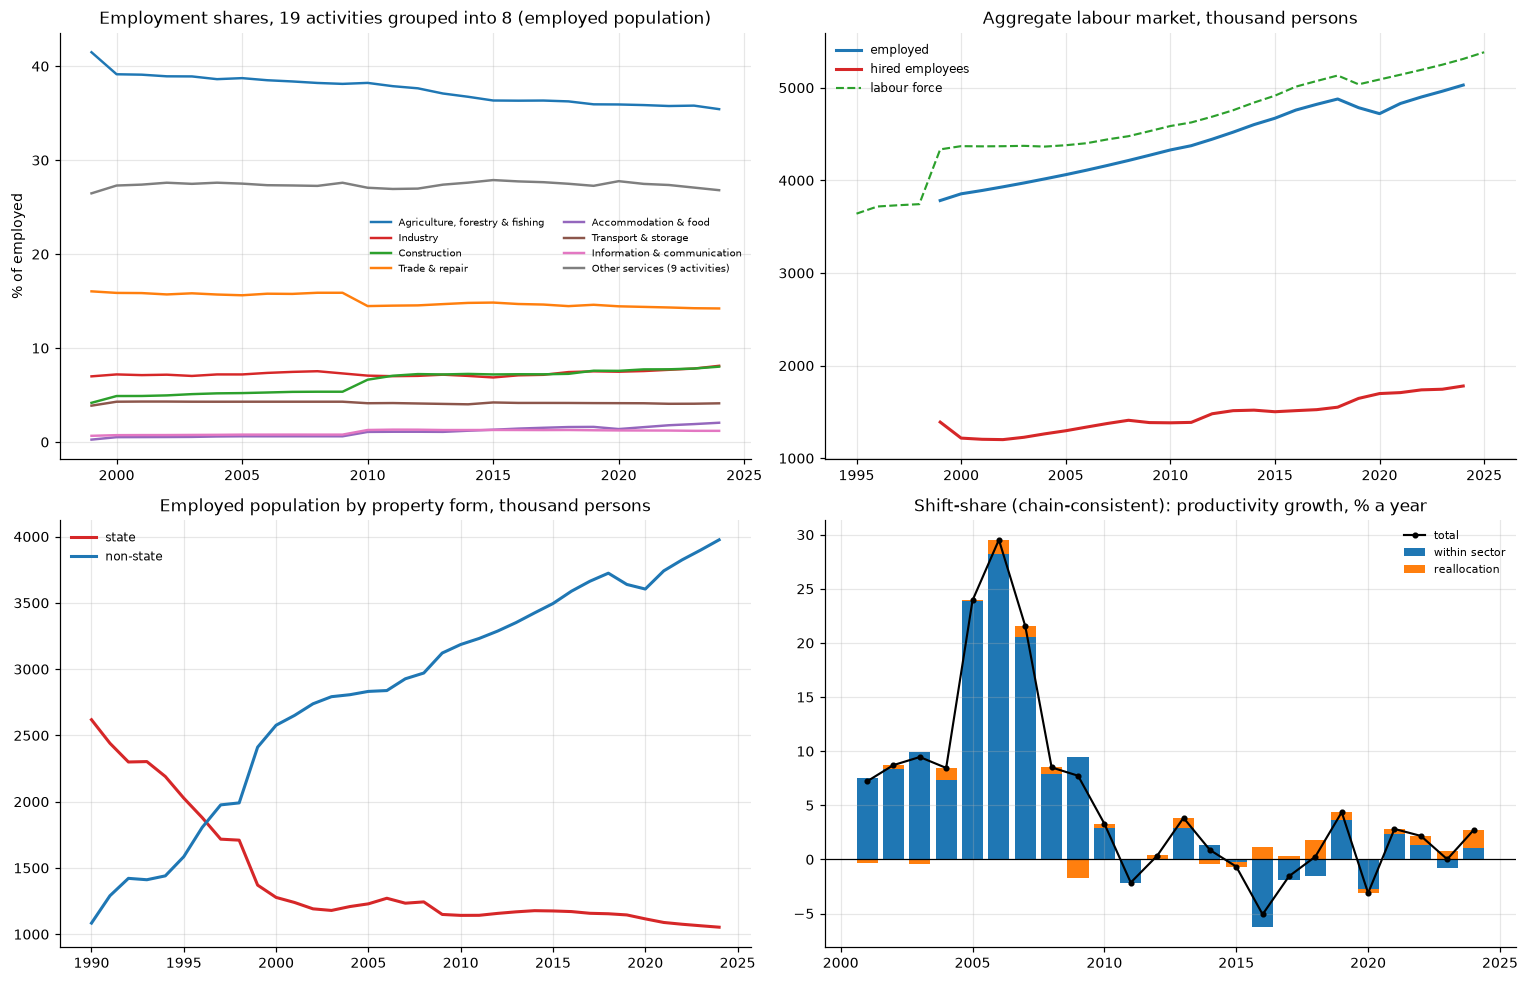

In [17]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))
a = ax[0, 0]
for i, k in enumerate(G8_KEYS):
    a.plot(E8.index, E8[k] / E8.total * 100, color=PAL[i], lw=1.6, label=G8_LABEL[k])
a.set_title('Employment shares, 19 activities grouped into 8 (employed population)')
a.set_ylabel('% of employed'); a.legend(fontsize=6.5, ncol=2)

a = ax[0, 1]
a.plot(EMP_ACT.index, EMP_ACT.total, color=PAL[0], lw=2, label='employed')
a.plot(HIR_ACT.index, HIR_ACT.total, color=PAL[1], lw=2, label='hired employees')
a.plot(SOC.lf.dropna().index, SOC.lf.dropna(), color=PAL[2], lw=1.4, ls='--', label='labour force')
a.set_title('Aggregate labour market, thousand persons'); a.legend(fontsize=8)

a = ax[1, 0]
a.plot(EMP_PROP.index, EMP_PROP.state, color=PAL[1], lw=2, label='state')
a.plot(EMP_PROP.index, EMP_PROP.nonstate, color=PAL[0], lw=2, label='non-state')
a.set_title('Employed population by property form, thousand persons'); a.legend(fontsize=8)

a = ax[1, 1]
b = SS[['within', 'reallocation']]
a.bar(b.index, b.within.clip(lower=0), color=PAL[0], label='within sector')
a.bar(b.index, b.within.clip(upper=0), color=PAL[0])
a.bar(b.index, b.reallocation, bottom=np.where(b.reallocation >= 0, b.within.clip(lower=0),
      b.within.clip(upper=0)), color=PAL[3], label='reallocation')
a.plot(SS.index, SS.total, color='k', lw=1.4, marker='o', ms=3, label='total')
a.axhline(0, color='k', lw=0.8)
a.set_title('Shift-share (chain-consistent): productivity growth, % a year'); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

## Part 9 — Econometric toolkit

`linearmodels` is not available in this environment, so the estimators are implemented directly. The
three cells below are the **same code used in FR1 and FR3**, carried over unchanged so that all three
deliverables share one estimator and one covariance convention. The last cell validates the
implementations against `statsmodels` on simulated data: coefficients, standard errors and test
statistics must agree to within 1e-8, otherwise the notebook stops.

Provided: OLS with HC1 and Newey–West HAC covariance; two-stage least squares with first-stage F and
the Sargan over-identification test; dynamic OLS (DOLS) for cointegrating relations; Wald tests of
linear restrictions; variance inflation factors; seemingly-unrelated regressions with cross-equation
restrictions; three-stage least squares; two-way panel fixed effects with Driscoll–Kraay standard
errors; and a damped Gauss–Seidel solver for the simultaneous system.

In [18]:
class Fit:
    def __init__(self, **kw): self.__dict__.update(kw)
    def table(self, digits=4):
        t = pd.DataFrame({'coef': self.beta, 'se': self.se, 't': self.tstat, 'p': self.pval},
                         index=self.names)
        t['sig'] = ['***' if p<.01 else '**' if p<.05 else '*' if p<.10 else '' for p in self.pval]
        return t.round(digits)
    def summary(self, title=''):
        out = [f"{title or self.kind}   n={self.n}  R2={self.r2:.4f}  adj={self.r2a:.4f}"]
        if getattr(self, 'extra', None): out.append("  " + self.extra)
        out.append(self.table().to_string())
        return "\n".join(out)
    def __repr__(self): return self.summary()

def _prep(y, X, add_const=True):
    d = pd.concat([y.rename('__y__'), X], axis=1).dropna()
    yv = d['__y__'].to_numpy(float); Xv = d.drop(columns='__y__').to_numpy(float)
    names = [c for c in d.columns if c != '__y__']
    if add_const:
        Xv = np.column_stack([np.ones(len(Xv)), Xv]); names = ['const'] + names
    return yv, Xv, names, d.index

def hac_cov(X, u, XtXi, lags=None):
    '''Newey-West HAC covariance. This corrects INFERENCE for residual dependence;
    it adds no autoregressive term to the model and never changes a fitted value.'''
    n = len(X)
    if lags is None: lags = max(1, int(np.floor(4*(n/100)**(2/9))))
    Xu = X * u[:, None]
    S = Xu.T @ Xu
    for L in range(1, lags+1):
        G = Xu[L:].T @ Xu[:-L]
        S += (1 - L/(lags+1)) * (G + G.T)
    return XtXi @ S @ XtXi

def ols(y, X, cov='hac', lags=None, add_const=True):
    yv, Xv, names, idx = _prep(y, X, add_const)
    n, k = Xv.shape
    XtXi = np.linalg.pinv(Xv.T @ Xv)
    b = XtXi @ Xv.T @ yv
    u = yv - Xv @ b
    dof = max(n-k, 1)
    # HAC carries the finite-sample scaling n/(n-k); p-values come from t(n-k) (revision rule 3)
    if   cov == 'hac': V = hac_cov(Xv, u, XtXi, lags) * n/dof
    elif cov == 'hc1': V = XtXi @ ((Xv*u[:,None]).T @ (Xv*u[:,None])) @ XtXi * n/dof
    else:              V = XtXi * (u@u)/dof
    se = np.sqrt(np.maximum(np.diag(V), 0))
    with np.errstate(divide='ignore', invalid='ignore'): t = b/se
    tss = ((yv-yv.mean())**2).sum() if add_const else (yv**2).sum()
    r2 = 1 - (u@u)/tss
    return Fit(kind=f'OLS[{cov}]', beta=b, se=se, tstat=t, pval=2*(1-stats.t.cdf(np.abs(t), dof)),
               names=names, n=n, k=k, r2=r2, r2a=1-(1-r2)*(n-1)/dof, V=V, X=Xv, y=yv, index=idx,
               resid=pd.Series(u, index=idx), fitted=pd.Series(Xv@b, index=idx), sigma2=(u@u)/dof,
               dof=dof)

def tsls(y, X_endog, X_exog, Z, cov='hac', lags=None):
    '''2SLS for a structural equation. X_endog: jointly determined regressors;
    X_exog: included exogenous; Z: EXCLUDED instruments.
    Reports first-stage F (weak-instrument screen) and Sargan J (over-identification).'''
    En = list(X_endog.columns)
    Xn = [] if X_exog is None or X_exog.shape[1]==0 else list(X_exog.columns)
    Zn = list(Z.columns)
    parts = [p for p in (X_endog, X_exog, Z) if p is not None and p.shape[1] > 0]
    d = pd.concat([y.rename('__y__')] + parts, axis=1).dropna()
    yv = d['__y__'].to_numpy(float)
    E  = d[En].to_numpy(float)
    Xx = d[Xn].to_numpy(float) if Xn else np.empty((len(d), 0))
    Zz = d[Zn].to_numpy(float)
    one = np.ones((len(d), 1))
    W = np.column_stack([one, E, Xx])          # regressors
    I = np.column_stack([one, Xx, Zz])         # instrument set
    names = ['const'] + En + Xn
    n, k = W.shape
    if I.shape[1] < k:
        raise ValueError(f"under-identified: {I.shape[1]} instruments for {k} parameters")
    PiI = np.linalg.pinv(I.T @ I)
    Wh = I @ (PiI @ (I.T @ W))
    b = np.linalg.pinv(Wh.T @ W) @ (Wh.T @ yv)
    u = yv - W @ b
    dof = max(n-k, 1)
    XtXi = np.linalg.pinv(Wh.T @ Wh)
    if   cov == 'hac': V = hac_cov(Wh, u, XtXi, lags) * n/dof
    elif cov == 'hc1': V = XtXi @ ((Wh*u[:,None]).T @ (Wh*u[:,None])) @ XtXi * n/dof
    else:              V = XtXi * (u@u)/dof
    se = np.sqrt(np.maximum(np.diag(V), 0))
    with np.errstate(divide='ignore', invalid='ignore'): t = b/se
    X0 = np.column_stack([one, Xx]); q = Zz.shape[1]
    fsF = {}
    for j, nm in enumerate(En):
        ru = E[:,j] - I @ (PiI @ (I.T @ E[:,j]))
        rr = E[:,j] - X0 @ (np.linalg.pinv(X0.T@X0) @ (X0.T @ E[:,j]))
        den = (ru@ru)/max(n-I.shape[1], 1)
        fsF[nm] = ((rr@rr - ru@ru)/q)/den if den > 0 else np.nan
    over = I.shape[1] - k
    if over > 0:
        uh = I @ (PiI @ (I.T @ u)); J = n*(uh@uh)/(u@u); Jp = 1-stats.chi2.cdf(J, over)
    else:
        J, Jp = np.nan, np.nan
    r2 = 1 - (u@u)/((yv-yv.mean())**2).sum()
    extra = ("first-stage F: " + ", ".join(f"{m}={v:.1f}" for m, v in fsF.items()) +
             (f" | Sargan J({over})={J:.2f} p={Jp:.3f}" if over > 0 else " | just-identified"))
    return Fit(kind=f'2SLS[{cov}]', beta=b, se=se, tstat=t, pval=2*(1-stats.t.cdf(np.abs(t), dof)),
               names=names, n=n, k=k, r2=r2, r2a=1-(1-r2)*(n-1)/dof, V=V, index=d.index,
               resid=pd.Series(u, index=d.index), fitted=pd.Series(W@b, index=d.index),
               first_stage_F=fsF, J=J, J_p=Jp, extra=extra, sigma2=(u@u)/dof, dof=dof)

def dols(y, X, leads=1, lags_=1, cov='hac'):
    '''Stock-Watson Dynamic OLS of a cointegrating relation.
    The levels regression is augmented with LEADS AND LAGS OF THE DIFFERENCES OF THE
    REGRESSORS to purge endogeneity and residual serial correlation.
    The dependent variable's own lags NEVER enter: this is not an autoregression.'''
    aug = {}
    for c in X.columns:
        dx = X[c].diff()
        for L in range(-leads, lags_+1):
            if L == 0: continue
            aug[f'd_{c}_{"F" if L<0 else "L"}{abs(L)}'] = dx.shift(L)
    Xa = pd.concat([X, pd.DataFrame(aug, index=X.index)], axis=1)
    f = ols(y, Xa, cov=cov)
    f.kind = f'DOLS[leads={leads},lags={lags_}]'
    f.long_run    = pd.Series(f.beta[1:1+X.shape[1]], index=list(X.columns))
    f.long_run_se = pd.Series(f.se[1:1+X.shape[1]],   index=list(X.columns))
    f.core = list(X.columns)
    return f

def wald_test(fit, R, q):
    '''Test R*beta = q. R is (m,k) over the fit's parameter vector. Reported as a small-sample
    HAC-F: F = W/m referred to F(m, n-k), not to a chi-squared.'''
    R = np.atleast_2d(np.asarray(R, float)); q = np.atleast_1d(np.asarray(q, float))
    d = R @ fit.beta - q
    Vr = R @ fit.V @ R.T
    m = R.shape[0]
    Fs = float(d @ np.linalg.pinv(Vr) @ d) / m
    return Fs, 1 - stats.f.cdf(Fs, m, fit.dof)

def restrict_row(fit, name, value=1.0):
    R = np.zeros(len(fit.beta)); R[fit.names.index(name)] = 1.0
    return wald_test(fit, R, [value])

def vif(X):
    Xd = X.dropna()
    out = {}
    for c in Xd.columns:
        rest = Xd.drop(columns=c)
        if rest.shape[1] == 0: out[c] = 1.0; continue
        r2 = ols(Xd[c], rest, cov='nonrobust').r2
        out[c] = np.inf if r2 >= 1 else 1/(1-r2)
    return pd.Series(out)
print("estimators defined: ols, tsls, dols, wald_test (HAC-F), vif")

estimators defined: ols, tsls, dols, wald_test (HAC-F), vif


In [19]:
def sur(eqs, restrictions=None, iterate=3):
    '''Seemingly-unrelated regressions by feasible GLS.
    `restrictions` = (R, q) imposes R*beta = q exactly (used for adding-up in share systems).'''
    names = list(eqs); idx = None
    for nm in names:
        y, X = eqs[nm]
        d = pd.concat([y, X], axis=1).dropna()
        idx = d.index if idx is None else idx.intersection(d.index)
    Y = [eqs[nm][0].loc[idx].to_numpy(float) for nm in names]
    Xs = [np.column_stack([np.ones(len(idx)), eqs[nm][1].loc[idx].to_numpy(float)]) for nm in names]
    n, m = len(idx), len(names); ks = [x.shape[1] for x in Xs]
    yb = np.concatenate(Y); Xb = np.zeros((n*m, sum(ks))); c = 0
    for i, x in enumerate(Xs):
        Xb[i*n:(i+1)*n, c:c+ks[i]] = x; c += ks[i]
    b = np.linalg.pinv(Xb.T@Xb) @ Xb.T @ yb
    Om = np.eye(n*m)
    for _ in range(iterate):
        U = (yb - Xb@b).reshape(m, n); S = U@U.T/n
        Om = np.kron(np.linalg.pinv(S), np.eye(n))
        Amat = Xb.T @ Om @ Xb; rhs = Xb.T @ Om @ yb
        if restrictions is not None:
            Rm, qv = restrictions
            KKT = np.block([[Amat, Rm.T], [Rm, np.zeros((Rm.shape[0], Rm.shape[0]))]])
            b = (np.linalg.pinv(KKT) @ np.concatenate([rhs, qv]))[:Amat.shape[0]]
        else:
            b = np.linalg.pinv(Amat) @ rhs
    V = np.linalg.pinv(Xb.T @ Om @ Xb); se = np.sqrt(np.maximum(np.diag(V), 0))
    out, c = {}, 0
    for i, nm in enumerate(names):
        cols = ['const'] + list(eqs[nm][1].columns)
        t = pd.DataFrame({'coef': b[c:c+ks[i]], 'se': se[c:c+ks[i]]}, index=cols)
        t['t'] = t.coef/t.se; out[nm] = t; c += ks[i]
    U = (yb - Xb@b).reshape(m, n)
    return out, pd.DataFrame(U.T, index=idx, columns=names), U@U.T/n

def system_3sls(eqs, instruments, iterate=2):
    '''Three-stage least squares for a simultaneous structural system.
    Stage 1-2: project all regressors on the instrument set (2SLS).
    Stage 3: re-weight by the cross-equation error covariance for efficiency.'''
    names = list(eqs); idx = None
    for nm in names:
        y, X = eqs[nm]
        d = pd.concat([y, X, instruments], axis=1).dropna()
        idx = d.index if idx is None else idx.intersection(d.index)
    Z = np.column_stack([np.ones(len(idx)), instruments.loc[idx].to_numpy(float)])
    Pz = Z @ np.linalg.pinv(Z.T@Z) @ Z.T
    Y, Xs, Xh = [], [], []
    for nm in names:
        y, X = eqs[nm]
        Xv = np.column_stack([np.ones(len(idx)), X.loc[idx].to_numpy(float)])
        Y.append(y.loc[idx].to_numpy(float)); Xs.append(Xv); Xh.append(Pz @ Xv)
    n, m = len(idx), len(names); ks = [x.shape[1] for x in Xs]
    yb = np.concatenate(Y)
    Xb = np.zeros((n*m, sum(ks))); Hb = np.zeros((n*m, sum(ks))); c = 0
    for i in range(m):
        Xb[i*n:(i+1)*n, c:c+ks[i]] = Xs[i]; Hb[i*n:(i+1)*n, c:c+ks[i]] = Xh[i]; c += ks[i]
    b = np.linalg.pinv(Hb.T@Xb) @ (Hb.T@yb)
    Om = np.eye(n*m)
    for _ in range(iterate):
        U = (yb - Xb@b).reshape(m, n); S = U@U.T/n
        Om = np.kron(np.linalg.pinv(S), np.eye(n))
        b = np.linalg.pinv(Hb.T @ Om @ Hb) @ (Hb.T @ Om @ yb)
    V = np.linalg.pinv(Hb.T @ Om @ Hb); se = np.sqrt(np.maximum(np.diag(V), 0))
    out, res, c = {}, {}, 0
    for i, nm in enumerate(names):
        cols = ['const'] + list(eqs[nm][1].columns)
        t = pd.DataFrame({'coef': b[c:c+ks[i]], 'se': se[c:c+ks[i]]}, index=cols)
        t['t'] = t.coef/t.se; t['p'] = 2*(1-stats.norm.cdf(t.t.abs()))
        t['sig'] = ['***' if p<.01 else '**' if p<.05 else '*' if p<.10 else '' for p in t.p]
        out[nm] = t
        res[nm] = pd.Series(Y[i] - Xs[i]@b[c:c+ks[i]], index=idx); c += ks[i]
    U = (yb - Xb@b).reshape(m, n)
    return out, pd.DataFrame(res), U@U.T/n, idx

def panel_fe(df, dep, regs, entity='unit', time='year', twoway=True, dk_lags=2):
    '''Two-way (entity and time) fixed-effects within estimator with Driscoll-Kraay
    standard errors, robust to cross-sectional dependence and limited time dependence.'''
    d = df[[entity, time, dep] + regs].dropna().copy()
    cols = [dep] + regs
    if twoway:
        for c in cols:
            d[c] = (d[c] - d.groupby(entity)[c].transform('mean')
                         - d.groupby(time)[c].transform('mean') + d[c].mean())
    else:
        for c in cols:
            d[c] = d[c] - d.groupby(entity)[c].transform('mean')
    yv = d[dep].to_numpy(float); Xv = d[regs].to_numpy(float)
    XtXi = np.linalg.pinv(Xv.T@Xv); b = XtXi @ Xv.T @ yv; u = yv - Xv@b
    nN, nT = d[entity].nunique(), d[time].nunique()
    k = len(regs) + nN + (nT-1 if twoway else 0)
    ht = (pd.DataFrame(Xv*u[:,None], index=d[time].to_numpy())
            .groupby(level=0).sum().sort_index().to_numpy())
    S = ht.T @ ht
    for L in range(1, dk_lags+1):
        G = ht[L:].T @ ht[:-L]; S += (1 - L/(dk_lags+1))*(G + G.T)
    V = XtXi @ S @ XtXi * (len(d)/max(len(d)-k, 1))
    se = np.sqrt(np.maximum(np.diag(V), 0)); t = b/se; dof = max(len(d)-k, 1)
    r2 = 1 - (u@u)/(yv@yv)
    return Fit(kind='Panel 2-way FE [Driscoll-Kraay]' if twoway else 'Panel entity FE [DK]',
               beta=b, se=se, tstat=t, pval=2*(1-stats.t.cdf(np.abs(t), dof)), names=regs,
               n=len(d), k=k, r2=r2, r2a=1-(1-r2)*(len(d)-1)/dof, V=V,
               resid=pd.Series(u, index=d.index), nN=nN, nT=nT, dof=dof,
               extra=f"units={nN}  periods={nT}")

def gauss_seidel(eq_funcs, order, state, exog, max_iter=800, tol=1e-9, damp=0.55):
    '''Solve one period of the simultaneous nonlinear system by damped Gauss-Seidel.
    eq_funcs: variable -> f(state, exog) returning that variable's new value.'''
    s = dict(state)
    err = np.inf
    for it in range(max_iter):
        err = 0.0
        for v in order:
            new = eq_funcs[v](s, exog)
            old = s.get(v, new)
            if old is None or not np.isfinite(old): old = new
            upd = damp*new + (1-damp)*old
            err = max(err, abs(upd-old)/max(abs(old), 1e-6))
            s[v] = upd
        if err < tol:
            return s, it+1, err
    return s, max_iter, err
print("estimators defined: sur, system_3sls, panel_fe, gauss_seidel")

estimators defined: sur, system_3sls, panel_fe, gauss_seidel


In [20]:
import statsmodels.api as sm
from statsmodels.sandbox.regression.gmm import IV2SLS

rng = np.random.default_rng(SEED); n = 80
Xt = pd.DataFrame(rng.standard_normal((n,3)), columns=['a','b','c'])
yt = pd.Series(1 + 2*Xt.a - 1.5*Xt.b + .5*Xt.c + rng.standard_normal(n)*.3, name='y')
rows = []
f0 = ols(yt, Xt, cov='nonrobust'); r0 = sm.OLS(yt, sm.add_constant(Xt)).fit()
rows.append(['OLS coefficients', np.abs(f0.beta-r0.params.values).max()])
rows.append(['OLS standard errors', np.abs(f0.se-r0.bse.values).max()])
f1 = ols(yt, Xt, cov='hc1'); r1 = sm.OLS(yt, sm.add_constant(Xt)).fit(cov_type='HC1')
rows.append(['HC1 robust SE', np.abs(f1.se-r1.bse.values).max()])
f2 = ols(yt, Xt, cov='hac', lags=3)
r2_ = sm.OLS(yt, sm.add_constant(Xt)).fit(cov_type='HAC',
        cov_kwds={'maxlags':3, 'use_correction':True}, use_t=True)
rows.append(['Newey-West HAC SE', np.abs(f2.se-r2_.bse.values).max()])
Zt = pd.DataFrame(rng.standard_normal((n,2)), columns=['z1','z2'])
en = pd.Series(.8*Zt.z1 + .6*Zt.z2 + rng.standard_normal(n)*.5, name='en')
y2 = pd.Series(1 + 1.5*en + .7*Xt.a + rng.standard_normal(n)*.4, name='y2')
g = tsls(y2, en.to_frame(), Xt[['a']], Zt, cov='nonrobust')
r3 = IV2SLS(y2, sm.add_constant(pd.concat([en, Xt.a], axis=1)),
                sm.add_constant(pd.concat([Xt.a, Zt], axis=1))).fit()
rows.append(['2SLS coefficients', np.abs(g.beta-r3.params.values).max()])
rows.append(['2SLS standard errors', np.abs(g.se-r3.bse.values).max()])
# 3SLS on a just-identified single equation must reproduce 2SLS
o3, _, _, _ = system_3sls({'eq': (y2, pd.concat([en, Xt.a], axis=1))},
                          pd.concat([Xt.a, Zt], axis=1))
rows.append(['3SLS vs 2SLS (just-identified)', np.abs(o3['eq'].coef.values - g.beta).max()])
# panel FE within-transform must reproduce OLS on demeaned data
pdf = pd.DataFrame({'unit': np.repeat(np.arange(10), 8), 'year': np.tile(np.arange(8), 10)})
pdf['x'] = rng.standard_normal(80); pdf['fe'] = pdf.unit*0.3
pdf['y'] = 1 + 0.6*pdf.x + pdf.fe + rng.standard_normal(80)*.2
fp = panel_fe(pdf, 'y', ['x'], twoway=False)
dd = pdf.copy()
for c in ['y','x']: dd[c] = dd[c] - dd.groupby('unit')[c].transform('mean')
rows.append(['panel FE coefficient', abs(fp.beta[0] - ols(dd.y, dd[['x']], cov='nonrobust').beta[1])])
chk = pd.DataFrame(rows, columns=['check','max abs difference'])
chk['verdict'] = np.where(chk['max abs difference'] < 1e-8, 'exact', 'MISMATCH')
display(chk)
assert (chk.verdict == 'exact').all(), "estimator validation failed"
print("all estimators reproduce statsmodels to machine precision")
print(f"\nWald machinery sanity check: H0 slope on 'a' = 2 (true value) -> "
      f"p = {restrict_row(f0, 'a', 2.0)[1]:.3f}  (should not reject)")
print(f"                             H0 slope on 'a' = 0            -> "
      f"p = {restrict_row(f0, 'a', 0.0)[1]:.3f}  (should reject)")

,check,max abs difference,verdict
0,OLS coefficients,0.000,exact
1,OLS standard errors,0.000,exact
2,HC1 robust SE,0.000,exact
3,Newey-West HAC SE,0.000,exact
4,2SLS coefficients,0.000,exact
5,2SLS standard errors,0.000,exact
6,3SLS vs 2SLS (just-identified),0.000,exact
7,panel FE coefficient,0.000,exact


all estimators reproduce statsmodels to machine precision

Wald machinery sanity check: H0 slope on 'a' = 2 (true value) -> p = 0.386  (should not reject)
                             H0 slope on 'a' = 0            -> p = 0.000  (should reject)


In [21]:
# ---------- revision toolkit (2026-09-27): cointegration p-values, DOLS long-run estimator,
#            difference-form comparison, Diebold-Mariano with the HLN correction --------------
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.adfvalues import mackinnonp

def eg_coint_p(resid, n_i1, trend=False):
    '''Residual-based (Engle-Granger) cointegration p-value: ADF statistic on the residuals with no
    deterministic terms and a fixed single lag, mapped through MacKinnon's response surface with
    N = number of I(1) regressors + 1 ('ct' when the equation carries a linear trend).'''
    r = np.asarray(pd.Series(resid).dropna(), float)
    stat = adfuller(r, maxlag=1, autolag=None, regression='n')[0]
    return float(mackinnonp(stat, regression='ct' if trend else 'c', N=int(n_i1) + 1))

def _dols_design(X, k):
    aug = {}
    for c in X.columns:
        dx = X[c].diff()
        for Lg in range(-k, k + 1):
            aug[f'd_{c}_{"F" if Lg < 0 else "L"}{abs(Lg)}'] = dx.shift(Lg)
    return pd.DataFrame(aug, index=X.index)

def lr_eq(y, X=None, det=None, name='', lags=None):
    '''Long-run (level) relation, estimated per the FR4 revision rules.
    X   : stochastic (I(1)) regressors;  det : deterministic regressors (a linear trend).
    DOLS (Stock-Watson) with +/-1 lead/lag of the REGRESSOR differences if >= 10 residual df remain,
    otherwise contemporaneous differences only (Saikkonen), otherwise plain OLS if < 8 df.
    The dependent variable's own lags never enter. Returns the level coefficients used in forecasting,
    their small-sample HAC covariance, the cointegration p-value and the difference-form comparison.'''
    X = pd.DataFrame(index=y.index) if X is None else pd.DataFrame(X)
    det = pd.DataFrame(index=y.index) if det is None else pd.DataFrame(det)
    base = pd.concat([y.rename('_y'), X, det], axis=1).dropna()
    yb, Xb, Db = base['_y'], base[list(X.columns)], base[list(det.columns)]
    core = list(X.columns) + list(det.columns)
    fit, est, kk = None, None, None
    if X.shape[1] > 0:
        for k in (1, 0):
            A = pd.concat([Xb, Db, _dols_design(Xb, k)], axis=1)
            f = ols(yb, A, cov='hac', lags=lags)
            need = 10 if k == 1 else 8
            if f.dof >= need:
                fit, est, kk = f, ('DOLS(+/-1)' if k == 1 else 'DOLS(0: contemporaneous dx)'), k; break
    if fit is None:
        fit = ols(yb, pd.concat([Xb, Db], axis=1), cov='hac', lags=lags)
        est = 'OLS' + (' (deterministic regressors only)' if X.shape[1] == 0 else ' (too few df for DOLS)')
    idx = [fit.names.index(c) for c in ['const'] + core]
    b = pd.Series(fit.beta[idx], index=['const'] + core)
    Vb = pd.DataFrame(fit.V[np.ix_(idx, idx)], index=b.index, columns=b.index)
    se = np.sqrt(np.maximum(np.diag(Vb), 0))
    tt = b.values / se
    pv = 2 * (1 - stats.t.cdf(np.abs(tt), fit.dof))
    # static long-run residual on the full level sample
    Z = np.column_stack([np.ones(len(base))] + [base[c].to_numpy(float) for c in core])
    res = pd.Series(yb.to_numpy(float) - Z @ b.to_numpy(float), index=base.index)
    egp = eg_coint_p(res, X.shape[1], trend='trend' in det.columns)
    rho = float(np.clip(np.corrcoef(res.values[1:], res.values[:-1])[0, 1], 0, 1)) if len(res) > 3 else np.nan
    dw = float((np.diff(res.values) ** 2).sum() / (res.values ** 2).sum())
    # difference form: dy on dX (+ const, which is the trend in levels)
    # step dummies in levels become impulses in differences
    imp = [Db[c].diff().rename(c) for c in det.columns if c != 'trend']
    dd = pd.concat([yb.diff().rename('dy')] + [Xb[c].diff().rename(c) for c in X.columns] + imp, axis=1).dropna()
    fd = ols(dd['dy'], dd[[c for c in dd.columns if c != 'dy']], cov='hac', lags=1)
    dmap = {c: c for c in X.columns}
    if 'trend' in det.columns: dmap['trend'] = 'const'
    comp = {}
    for c, dc in dmap.items():
        j = fd.names.index(dc)
        crit = stats.t.ppf(0.975, fd.dof)
        lo_, hi_ = fd.beta[j] - crit * fd.se[j], fd.beta[j] + crit * fd.se[j]
        comp[c] = dict(level=float(b[c]), diff=float(fd.beta[j]), diff_t=float(fd.tstat[j]),
                       diff_lo=float(lo_), diff_hi=float(hi_), outside=bool(b[c] < lo_ or b[c] > hi_))
    r2 = 1 - (res ** 2).sum() / ((yb - yb.mean()) ** 2).sum()
    return Fit(kind=est, name=name, lr=b, V_lr=Vb, se_lr=pd.Series(se, index=b.index),
               t_lr=pd.Series(tt, index=b.index), p_lr=pd.Series(pv, index=b.index),
               n=int(len(base)), n_eff=int(fit.n), dof=int(fit.dof), eg_p=egp, rho=rho, dw=dw,
               resid=res, comp=comp, fd=fd, core=core, stoch=list(X.columns), det=list(det.columns),
               r2=float(r2), fit=fit, beta=b.values, names=list(b.index), se=se, tstat=tt, pval=pv)

def dm_d(d, h=1):
    '''Diebold-Mariano / HLN test on a given loss-differential series d (t(n-1) p-value).'''
    d = np.asarray(d, float); n = len(d); dbar = d.mean(); u = d - dbar
    g = [float(u @ u) / n] + [float(u[k:] @ u[:-k]) / n for k in range(1, h)]
    var = (g[0] + 2 * sum(g[1:])) / n
    if var <= 0: var = g[0] / n
    s = dbar / np.sqrt(var) * np.sqrt(max(n + 1 - 2 * h + h * (h - 1) / n, 1e-12) / n)
    return float(s), float(2 * (1 - stats.t.cdf(abs(s), n - 1)))

def dm_test(e1, e2, h=1):
    '''Diebold-Mariano test on squared-error loss with the Harvey-Leybourne-Newbold small-sample
    correction; p-value from t(n-1). Positive statistic = model 1 has the larger loss.'''
    d = np.asarray(e1, float) ** 2 - np.asarray(e2, float) ** 2
    n = len(d); dbar = d.mean(); u = d - dbar
    g = [float(u @ u) / n] + [float(u[k:] @ u[:-k]) / n for k in range(1, h)]
    var = (g[0] + 2 * sum(g[1:])) / n
    if var <= 0: var = g[0] / n
    dm = dbar / np.sqrt(var)
    hln = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
    s = dm * hln
    return float(s), float(2 * (1 - stats.t.cdf(abs(s), n - 1)))

# validation: eg_coint_p on OLS residuals must equal statsmodels' coint() with the same settings
from statsmodels.tsa.stattools import coint as _sm_coint
_x = pd.Series(np.cumsum(rng.standard_normal(60)), name='x')
_y = pd.Series(0.5 + 0.8 * _x + rng.standard_normal(60) * 4.0, name='y')
_f = ols(_y, _x.to_frame(), cov='nonrobust')
_p_own = eg_coint_p(_f.resid, 1, trend=False)
_p_sm = _sm_coint(_y, _x, trend='c', maxlag=1, autolag=None)[1]
print(f'eg_coint_p vs statsmodels coint(): {_p_own:.6f} vs {_p_sm:.6f}')
assert abs(_p_own - _p_sm) < 1e-8, 'cointegration p-value does not reproduce statsmodels'
_s, _p = dm_test(rng.standard_normal(60), rng.standard_normal(60) * 3, h=1)
print(f'DM/HLN sanity check (model 1 has one-third the error s.d.): stat {_s:+.2f}, p = {_p:.3f}')
print('revision toolkit defined: eg_coint_p, lr_eq (DOLS / Saikkonen / OLS by df), dm_test (HLN)')


eg_coint_p vs statsmodels coint(): 0.000200 vs 0.000200
DM/HLN sanity check (model 1 has one-third the error s.d.): stat -5.44, p = 0.000
revision toolkit defined: eg_coint_p, lr_eq (DOLS / Saikkonen / OLS by df), dm_test (HLN)


## Part 10 — What is estimated, what is forbidden, and what was rejected

### 10.1 The no-autoregression constraint, stated precisely

No equation in FR4 contains a lagged dependent variable, a moving-average error, or a conditional
variance process. Three lag constructs *do* appear, and each is an accounting or inferential device
rather than a dynamic model of the dependent variable:

| Construct | Where | Why it is not an autoregression |
|---|---|---|
| Newey–West HAC covariance (with the n/(n−k) small-sample scaling) | every time-series equation | Affects **standard errors only**. No lag enters the conditional mean. |
| DOLS leads and lags of **regressor differences** | every level equation with a stochastic regressor (Parts 11–14) | Stock–Watson correction for endogeneity in a levels regression; the long-run (level) coefficients it returns are the ones used in forecasting. The dependent variable's own lags never enter. |
| Residual-based cointegration test (ADF on the residuals, fixed single lag) | every level equation | A **test statistic** computed on residuals; nothing enters the model. |
| Constant add-factor (each equation's own last-actual-year residual) | Part 15 | A level adjustment held fixed; it is not a function of the dependent variable's past. The sensitivity in Part 18 decays it at the residual's first-order autocorrelation — a judgemental rule for the adjustment, not a model of the dependent variable. |
| Cumulated bootstrap shocks in the fan charts | Part 17.5 | Resampled historical residual changes added as persistent level shocks to describe uncertainty; they never feed back into any estimated equation. |
| Previous-year share weights in chain aggregation | Part 8.1 | An accounting identity of the official chain-linking method, not a behavioural equation. |

FR4 has no partial-year (year-to-date) data, so the contract's nowcast add-factor rule (a partial-year
increment applied in full in the nowcast year and halved each year after) does not arise here.

Everything else is contemporaneous. Where employment adjusts slowly, the slow adjustment is described
by a **levels relation** rather than by adding a lagged dependent variable. **Revision note:** the
first version called these relations cointegrating. The revised notebook tests that claim for every
equation (residual-based Engle–Granger p-value, `eg_coint_p`) and, for most equations, cointegration is
**not established** at 10%; their $t$-statistics are then labelled *descriptive* in the audit table
(Part 19.4). The cost of the levels choice is unchanged: the model describes the long-run allocation of
labour and will understate how sluggishly employment responds in the first year after a shock.

### 10.2 Four devices used to identify a large system from short samples

The same four devices FR1 and FR3 relied on: (1) restrictions tested and then imposed; (2) parameters
transferred from a panel with many observations to an aggregate equation with few;
(3) parsimony — no equation carries a regressor it cannot support; (4) levels (DOLS) estimation
without autoregression, with cointegration tested rather than assumed.

### 10.3 Specifications tested and rejected

The table below is produced by running each candidate. It is not a narrative: every number comes from
an estimate computed in this notebook. The first eight candidates are rejected or set aside here, and the reasons fall into
three families — a **wrong sign** relative to theory, an **implausible magnitude**, or an estimate that
**is not stable between levels and differences**, which is the signature of a spurious trend match
rather than a structural relationship.

In [22]:
# ---------- helpers used by the specification search and by Parts 12-13 -------------------------
def L(x): return np.log(x)

def share_panel(Efr, Qfr, keys, ref, extra=None):
    # Long panel of log employment shares and log output shares, plus multinomial-logit
    # (log-odds against a reference group) transforms of both.
    yrs = sorted(set(Efr.index) & set(Qfr.dropna().index))
    se  = Efr[keys].loc[yrs].div(Efr[keys].loc[yrs].sum(axis=1), axis=0)
    sq  = Qfr[keys].loc[yrs].div(Qfr[keys].loc[yrs].sum(axis=1), axis=0)
    P = pd.concat([pd.DataFrame({'unit': k, 'year': yrs,
                                 'ln_se': L(se[k]).values, 'ln_sq': L(sq[k]).values})
                   for k in keys], ignore_index=True)
    r = P[P.unit == ref].set_index('year')
    P['lo_se'] = P.ln_se - P.year.map(r.ln_se)
    P['lo_sq'] = P.ln_sq - P.year.map(r.ln_sq)
    P['trend'] = P.year - min(yrs)
    if extra:
        for nm, s in extra.items():
            P[nm] = P.year.map(s)
    # The reference group's log-odds are identically zero on both sides, so its rows carry no
    # information and would distort a within estimator. They are dropped; the reference group is
    # restored analytically when shares are recovered (its log-odds is zero by definition).
    P = P[P.unit != ref]
    for c in ['ln_se', 'ln_sq', 'lo_se', 'lo_sq']:
        P = P[np.isfinite(P[c])]
    return P.dropna().reset_index(drop=True)

def ts(dep, xd, cov='hac', lags=2):
    # Single time-series equation on the aligned intersection of dep and the regressors.
    d = pd.concat([dep.rename('_y')] + [v.rename(k) for k, v in xd.items()], axis=1).dropna()
    return ols(d['_y'], d.drop(columns='_y'), cov=cov, lags=lags), d

def coefs(fit, names):
    return {n: (fit.beta[fit.names.index(n)], fit.tstat[fit.names.index(n)]) for n in names}

REJ = []
def reject(spec, block, verdict, detail):
    REJ.append(dict(specification=spec, block=block, verdict=verdict, evidence=detail))
print('helpers defined')

helpers defined


In [23]:
# ---- R1  sector employment proportional to sector output, in levels ---------------------------
rows = []
for g, q in [('agr', 'rva_agr'), ('manuf', 'rva_man'), ('mining', 'rva_min'),
             ('constr', 'rva_con'), ('trade', 'rva_trd'), ('transp', 'rva_tra')]:
    f1, _ = ts(L(HIR_ACT[g]), {'ln_q': L(F[q])})
    f2, _ = ts(L(HIR_ACT[g]), {'ln_q': L(F[q]), 'trend': pd.Series(F.index - 2000., index=F.index)})
    dd = pd.concat([L(HIR_ACT[g]).diff().rename('dy'), L(F[q]).diff().rename('dq')], axis=1).dropna()
    f3 = ols(dd.dy, dd[['dq']], cov='hac', lags=1)
    rows.append(dict(sector=g, b_level=f1.beta[1], t_level=f1.tstat[1],
                     b_with_trend=f2.beta[1], t_with_trend=f2.tstat[1],
                     b_difference=f3.beta[1], t_difference=f3.tstat[1], R2_diff=f3.r2))
R1 = pd.DataFrame(rows).set_index('sector')
print('R1 — hired employment on own-sector real value added: level, level+trend, and difference')
display(R1.round(3))
print('    The level coefficients look strong, but adding a trend collapses or reverses most of them,')
print('    and in differences there is almost no relationship (R2 near zero). Both series simply')
print('    trend. REJECTED as a spurious trend match.')
reject('ln(sector employment) = a + b ln(sector real value added)', 'sector allocation',
       'REJECTED — spurious',
       f'coefficient unstable between levels and differences; mean difference-form R2 = {R1.R2_diff.mean():.3f}')

R1 — hired employment on own-sector real value added: level, level+trend, and difference


,b_level,t_level,b_with_trend,t_with_trend,b_difference,t_difference,R2_diff
sector,,,,,,,
agr,0.031,0.112,-3.502,-2.233,-0.712,-0.565,0.022
manuf,0.358,4.286,0.720,4.027,0.211,0.854,0.045
mining,-0.137,-2.906,-0.084,-1.824,-0.010,-0.158,0.001
constr,0.306,4.309,0.049,0.617,0.162,1.485,0.075
trade,0.290,4.133,0.347,1.896,0.219,0.954,0.012
transp,-0.020,-1.117,-0.030,-0.235,0.024,0.236,0.001


    The level coefficients look strong, but adding a trend collapses or reverses most of them,
    and in differences there is almost no relationship (R2 near zero). Both series simply
    trend. REJECTED as a spurious trend match.


In [24]:
# ---- C1  robustness: nominal rather than real value-added shares as the driver ----------------
NOM = {'agr': 'va_agr_n', 'industry': None, 'constr': 'va_con_n', 'trade': 'va_trd_n',
       'hotel': 'va_tou_n', 'transp': 'va_tra_n', 'ict': 'va_ict_n', 'services': 'va_oth_n'}
QN = pd.DataFrame({k: (F[['va_min_n', 'va_man_n', 'va_elc_n', 'va_wat_n']].sum(axis=1)
                       .where(F[['va_min_n', 'va_man_n', 'va_elc_n', 'va_wat_n']].notna().all(axis=1))
                       if v is None else F[v]) for k, v in NOM.items()})
rows = []
for lbl, Qfr in [('REAL value-added shares', Q8), ('NOMINAL value-added shares', QN)]:
    P = share_panel(H8, Qfr, G8_KEYS, 'services')
    lv = panel_fe(P, 'lo_se', ['lo_sq'], entity='unit', twoway=False)
    Pd = P.sort_values(['unit', 'year']).copy()
    for c in ['lo_se', 'lo_sq']:
        Pd['d_' + c] = Pd.groupby('unit')[c].diff()
    df = panel_fe(Pd.dropna(), 'd_lo_se', ['d_lo_sq'], entity='unit', twoway=False)
    rows.append(dict(driver=lbl, years=f'{P.year.min()}-{P.year.max()}', n=lv.n,
                     b_level=lv.beta[lv.names.index('lo_sq')], t_level=lv.tstat[lv.names.index('lo_sq')],
                     b_diff=df.beta[df.names.index('d_lo_sq')], t_diff=df.tstat[df.names.index('d_lo_sq')]))
R2 = pd.DataFrame(rows).set_index('driver')
R2['level / difference'] = R2.b_level / R2.b_diff
display(R2.round(3))
print('    NOT a rejection but a robustness comparison of the pooled panel elasticity: for BOTH drivers')
print(f'    the level and difference estimates are close (ratios {R2["level / difference"].min():.2f}-'
      f'{R2["level / difference"].max():.2f}). They differ in MAGNITUDE - the')
print('    real-share elasticity is larger than the nominal-share one. (Whether the driver helps a')
print('    FORECAST is a separate question, settled out of sample in Part 12.)')
print()
print('    Real value-added shares are preferred, on three grounds:')
print('      (i)   theory - labour demand responds to real activity, not to a share that has risen')
print('            only because the oil price inflated one sector\'s nominal value added;')
print(f'      (ii)  sample length - real shares give {R2.loc["REAL value-added shares","years"]} '
      f'({int(R2.loc["REAL value-added shares","n"])} group-year observations), nominal only')
print(f'            {R2.loc["NOMINAL value-added shares","years"]} ({int(R2.loc["NOMINAL value-added shares","n"])}), '
      'because the nominal industrial branches start later;')
print('      (iii) the driver is the volume series FR1 actually forecasts.')
B_NOM = float(R2.loc['NOMINAL value-added shares', 'b_level'])

# ---- R3  mining employment on oil production;  R4 oil+gas combined ----------------------------
f, _ = ts(L(HIR_ACT.mining), {'ln_oil_prod': L(F.oil_prod)})
print(f'R3 — ln(mining hired employment) on ln(crude oil production): b = {f.beta[1]:+.3f} '
      f'(t = {f.tstat[1]:+.1f}), R2 = {f.r2:.3f}, n = {f.n}')
print('    Wrong sign: mining employment did not fall as oil output fell, because mining also')
print('    contains fast-growing metal-ore extraction and mining support services. REJECTED.')
reject('ln(mining employment) on ln(crude oil production)', 'sector allocation',
       'REJECTED — wrong sign', f'b = {f.beta[1]:+.3f} (t = {f.tstat[1]:+.1f})')

oe = (PI[PI.branch == 'Xam neft və təbii qaz hasilatı'].set_index('year').emp / 1000.)
f2, _ = ts(L(oe), {'ln_oil_and_gas': L(F.oil_prod + F.gas_prod * 0.9)}, lags=1)
print(f'\nR4 — ln(oil-extraction employment) on a combined oil+gas volume: b = {f2.beta[1]:+.3f} '
      f'(t = {f2.tstat[1]:+.1f})')
print('    Wrong sign, because gas output rose while extraction employment fell: gas extraction is')
print('    far more capital-intensive per worker. REJECTED in favour of a single oil driver.')
reject('oil-extraction employment on combined oil+gas volume', 'oil / non-oil',
       'REJECTED — wrong sign', f'b = {f2.beta[1]:+.3f} (t = {f2.tstat[1]:+.1f})')

,years,n,b_level,t_level,b_diff,t_diff,level / difference
driver,,,,,,,
REAL value-added shares,2000-2024,175,0.205,5.989,0.179,5.801,1.146
NOMINAL value-added shares,2005-2024,140,0.135,2.682,0.117,4.358,1.149


    NOT a rejection but a robustness comparison of the pooled panel elasticity: for BOTH drivers
    the level and difference estimates are close (ratios 1.15-1.15). They differ in MAGNITUDE - the
    real-share elasticity is larger than the nominal-share one. (Whether the driver helps a
    FORECAST is a separate question, settled out of sample in Part 12.)

    Real value-added shares are preferred, on three grounds:
      (i)   theory - labour demand responds to real activity, not to a share that has risen
            only because the oil price inflated one sector's nominal value added;
      (ii)  sample length - real shares give 2000-2024 (175 group-year observations), nominal only
            2005-2024 (140), because the nominal industrial branches start later;
      (iii) the driver is the volume series FR1 actually forecasts.
R3 — ln(mining hired employment) on ln(crude oil production): b = -0.052 (t = -1.8), R2 = 0.094, n = 26
    Wrong sign: mining employment did not fall as 

In [25]:
# ---- R5  participation on the real wage;  R6 free population elasticity -----------------------
tr = pd.Series(F.index - 2000., index=F.index)
f, _ = ts(L(SOC.lf / F['pop']), {'ln_real_wage': L(F.rwage), 'trend': tr})
print(f'R5 — ln(labour force / population) on ln(real wage): b = {f.beta[1]:+.3f} (t = {f.tstat[1]:+.1f})')
print('    Wrong sign for a labour-supply relation: participation drifted down while real wages rose')
print('    strongly, so the regression reads a coincidence of trends as a negative wage effect.')
f0, _ = ts(L(SOC.lf / F['pop']), {'trend': tr})
print(f'    Participation on a trend alone: b = {f0.beta[1]:+.4f} (t = {f0.tstat[1]:+.1f}), '
      f'R2 = {f0.r2:.3f} — essentially trendless.')
print('    REJECTED. Part 11 imposes a unit population elasticity instead, as FR1 did.')
reject('participation rate on the real wage', 'aggregate labour force',
       'REJECTED — wrong sign', f'b = {f.beta[1]:+.3f} (t = {f.tstat[1]:+.1f})')

pub = EMP_ACT[PUB].sum(axis=1); mkt = EMP_ACT[MKT].sum(axis=1)
f, _ = ts(L(pub), {'ln_pop': L(F['pop']), 'trend': tr})
print(f'\nR6 — ln(public-service employment) with a FREE population elasticity: '
      f'ln_pop = {f.beta[1]:+.3f} (t = {f.tstat[1]:+.1f}), trend = {f.beta[2]:+.4f}')
f2, _ = ts(L(mkt / pub), {'ln_rva_oth': L(F.rva_oth), 'ln_pop': L(F['pop'])})
print(f'     ln(market/public services) with a free population elasticity: '
      f'ln_pop = {f2.beta[2]:+.3f} (t = {f2.tstat[2]:+.1f})')
print('    Population elasticities of 2.8 and 4.8 are not structural parameters — a 1% larger')
print('    population cannot raise public employment by 2.8%. They are trend proxies fitted to a')
print('    smooth, almost monotone regressor. REJECTED; Part 13 imposes a unit elasticity.')
reject('public-service employment with a free population elasticity', 'services allocation',
       'REJECTED — implausible magnitude',
       f'ln(pop) elasticity {f.beta[1]:.1f} (services level) and {f2.beta[2]:.1f} (bloc split)')

R5 — ln(labour force / population) on ln(real wage): b = -0.072 (t = -12.6)
    Wrong sign for a labour-supply relation: participation drifted down while real wages rose
    strongly, so the regression reads a coincidence of trends as a negative wage effect.
    Participation on a trend alone: b = +0.0005 (t = +0.4), R2 = 0.015 — essentially trendless.
    REJECTED. Part 11 imposes a unit population elasticity instead, as FR1 did.

R6 — ln(public-service employment) with a FREE population elasticity: ln_pop = +2.801 (t = +5.2), trend = -0.0279
     ln(market/public services) with a free population elasticity: ln_pop = +4.755 (t = +6.3)
    Population elasticities of 2.8 and 4.8 are not structural parameters — a 1% larger
    population cannot raise public employment by 2.8%. They are trend proxies fitted to a
    smooth, almost monotone regressor. REJECTED; Part 13 imposes a unit elasticity.


In [26]:
# ---- R7  state employment on fiscal and output drivers ---------------------------------------
cand = [('real state investment per capita', L(F.rinv_state / F['pop'])),
        ('real total expenditure per capita', L(F.rexp_tot / F['pop'])),
        ('real value added of other services', L(F.rva_oth)),
        ('real GDP per capita', L(F.rgdp / F['pop']))]
rows = []
ysp = L(EMP_PROP.state / F['pop'])
for nm, x in cand:
    f, d = ts(ysp, {'ln_x': x, 'trend': tr})
    dd = pd.concat([ysp.diff().rename('dy'), x.diff().rename('dx')], axis=1).dropna()
    fd = ols(dd.dy, dd[['dx']], cov='hac', lags=1)
    rows.append(dict(driver=nm, n=f.n, b_driver=f.beta[1], t_driver=f.tstat[1], p_driver=f.pval[1],
                     b_trend=f.beta[2], t_trend=f.tstat[2], R2=f.r2,
                     b_difference=fd.beta[1], t_difference=fd.tstat[1]))
R7 = pd.DataFrame(rows).set_index('driver')
print('R7 - ln(state employment per capita): does any fiscal or output driver enter?')
print('     (levels with a trend, small-sample HAC; and the same driver in first differences)')
display(R7.round(3))
f0, _ = ts(ysp, {'trend': tr})
print(f'    trend alone: b = {f0.beta[1]:+.4f} (t = {f0.tstat[1]:+.1f}), R2 = {f0.r2:.3f}')
sig = R7[R7.p_driver < 0.05]
if len(sig):
    for nm, r in sig.iterrows():
        print(f'    CORRECTION to the first version, which said no driver is significant: {nm} IS significant')
        print(f'    in levels (b = {r.b_driver:+.3f}, t = {r.t_driver:+.2f}, p = {r.p_driver:.3f}), with a NEGATIVE sign.')
        print(f'    In first differences it is {r.b_difference:+.3f} (t = {r.t_difference:+.1f}): the level relation does')
        print('    not survive differencing, which is the notebook\'s own test (R1) for a shared-trend match.')
print('    The remaining candidates are insignificant in levels. No candidate driver passes both the')
print('    levels and the difference test, so none is used. State employment is modelled on a trend')
print('    in Part 14 and exposed as a POLICY LEVER - a statement that the data do not identify a')
print('    behavioural driver, not a claim that none exists.')
reject('state employment on fiscal capacity or output', 'state / non-state',
       'REJECTED - no driver passes both level and difference tests',
       '; '.join(f'{nm}: level t = {r.t_driver:+.2f}, difference t = {r.t_difference:+.2f}'
                 for nm, r in R7.iterrows() if abs(r.t_driver) >= 1.96) or
       f'largest |t| on any driver = {R7.t_driver.abs().max():.1f}')


R7 - ln(state employment per capita): does any fiscal or output driver enter?
     (levels with a trend, small-sample HAC; and the same driver in first differences)


,n,b_driver,t_driver,p_driver,b_trend,t_trend,R2,b_difference,t_difference
driver,,,,,,,,,
real state investment per capita,25,0.004,0.447,0.659,-0.018,-12.594,0.966,0.021,1.702
real total expenditure per capita,15,0.026,0.549,0.593,-0.016,-10.557,0.950,0.014,0.903
real value added of other services,25,-0.010,-0.134,0.895,-0.017,-5.762,0.965,-0.043,-0.221
real GDP per capita,30,-0.143,-2.116,0.044,-0.017,-11.115,0.862,0.046,0.496


    trend alone: b = -0.0259 (t = -6.3), R2 = 0.838
    CORRECTION to the first version, which said no driver is significant: real GDP per capita IS significant
    in levels (b = -0.143, t = -2.12, p = 0.044), with a NEGATIVE sign.
    In first differences it is +0.046 (t = +0.5): the level relation does
    not survive differencing, which is the notebook's own test (R1) for a shared-trend match.
    The remaining candidates are insignificant in levels. No candidate driver passes both the
    levels and the difference test, so none is used. State employment is modelled on a trend
    in Part 14 and exposed as a POLICY LEVER - a statement that the data do not identify a
    behavioural driver, not a claim that none exists.


In [27]:
# ---- R8  market services plus credit;  R9 the panel real-wage elasticity ----------------------
f, _ = ts(L(mkt), {'ln_rva_oth': L(F.rva_oth), 'ln_real_credit': L(F.rcred_tot)})
print(f'R8 — ln(market-service employment) on output and real credit: '
      f'credit = {f.beta[2]:+.3f} (t = {f.tstat[2]:+.1f})')
print('    Credit enters NEGATIVELY, which no theory of service-sector labour demand supports;')
print('    it is absorbing the post-2015 deleveraging. REJECTED; output alone is retained.')
reject('market-service employment with a real-credit term', 'services allocation',
       'REJECTED — wrong sign', f'credit coefficient {f.beta[2]:+.3f} (t = {f.tstat[2]:+.1f})')

pan = PI[~PI.branch.isin(['Emal sənayesi', 'Mədənçıxarma sənayesi'])].copy()
pan['cpi'] = pan.year.map(F['cpi'])
pan = pan.dropna(subset=['emp', 'wage', 'output', 'cpi'])
pan['ln_emp'] = L(pan.emp); pan['ln_real_output'] = L(pan.output / pan.cpi * 100)
pan['ln_real_wage'] = L(pan.wage / pan.cpi * 100); pan['unit'] = pan.branch
fp = panel_fe(pan, 'ln_emp', ['ln_real_output', 'ln_real_wage'], entity='unit', twoway=True)
print(f'\nR9 — industry branch panel ({pan.unit.nunique()} branches x {pan.year.nunique()} years, '
      f'n = {fp.n}), two-way fixed effects, Driscoll-Kraay standard errors:')
display(fp.table())
bw, tw = fp.beta[fp.names.index('ln_real_wage')], fp.tstat[fp.names.index('ln_real_wage')]
bo, to = fp.beta[fp.names.index('ln_real_output')], fp.tstat[fp.names.index('ln_real_output')]
print(f'    Output elasticity {bo:+.3f} (t = {to:+.1f}) — correctly signed and significant, and it is')
print('    transferred to the aggregate equations in Part 12 as an independent cross-check.')
print(f'    Real-wage elasticity {bw:+.3f} (t = {tw:+.1f}) — correctly signed but NOT significant.')
print('    With year effects absorbing the common wage cycle, the surviving cross-branch wage')
print('    variation is too weak to identify a substitution effect. The wage channel is therefore')
print('    REPORTED but NOT imposed: no FR4 employment equation carries a wage term it cannot')
print('    support, which is device (3), parsimony.')
reject('wage term in sector labour demand', 'sector allocation',
       'REPORTED, NOT IMPOSED — insignificant',
       f'panel real-wage elasticity {bw:+.3f} (t = {tw:+.1f}) with n = {fp.n}')

R8 — ln(market-service employment) on output and real credit: credit = -0.167 (t = -4.1)
    Credit enters NEGATIVELY, which no theory of service-sector labour demand supports;
    it is absorbing the post-2015 deleveraging. REJECTED; output alone is retained.

R9 — industry branch panel (29 branches x 10 years, n = 290), two-way fixed effects, Driscoll-Kraay standard errors:


,coef,se,t,p,sig
ln_real_output,0.169,0.066,2.548,0.011,**
ln_real_wage,-0.128,0.186,-0.690,0.491,


    Output elasticity +0.169 (t = +2.5) — correctly signed and significant, and it is
    transferred to the aggregate equations in Part 12 as an independent cross-check.
    Real-wage elasticity -0.128 (t = -0.7) — correctly signed but NOT significant.
    With year effects absorbing the common wage cycle, the surviving cross-branch wage
    variation is too weak to identify a substitution effect. The wage channel is therefore
    REPORTED but NOT imposed: no FR4 employment equation carries a wage term it cannot
    support, which is device (3), parsimony.


In [28]:
RJ = pd.DataFrame(REJ)
print(f'Specification search: {len(RJ)} candidate specifications rejected or set aside.')
display(RJ)
RJ.to_csv(OUT / 'FR4_rejected_specifications.csv', index=False)
print('\nsaved -> FR4_rejected_specifications.csv')
print()
print('None of these rejections is cosmetic. Each one removes a specification that would have')
print('produced a confident-looking forecast resting on a trend coincidence, a wrong sign, or an')
print('elasticity no economy could exhibit.')

Specification search: 8 candidate specifications rejected or set aside.


,specification,block,verdict,evidence
0,ln(sector employment) = a + b ln(sector real v...,sector allocation,REJECTED — spurious,coefficient unstable between levels and differ...
1,ln(mining employment) on ln(crude oil production),sector allocation,REJECTED — wrong sign,b = -0.052 (t = -1.8)
2,oil-extraction employment on combined oil+gas ...,oil / non-oil,REJECTED — wrong sign,b = -0.670 (t = -4.4)
3,participation rate on the real wage,aggregate labour force,REJECTED — wrong sign,b = -0.072 (t = -12.6)
4,public-service employment with a free populati...,services allocation,REJECTED — implausible magnitude,ln(pop) elasticity 2.8 (services level) and 4....
5,state employment on fiscal capacity or output,state / non-state,REJECTED - no driver passes both level and dif...,"real GDP per capita: level t = -2.12, differen..."
6,market-service employment with a real-credit term,services allocation,REJECTED — wrong sign,credit coefficient -0.167 (t = -4.1)
7,wage term in sector labour demand,sector allocation,"REPORTED, NOT IMPOSED — insignificant",panel real-wage elasticity -0.128 (t = -0.7) w...



saved -> FR4_rejected_specifications.csv

None of these rejections is cosmetic. Each one removes a specification that would have
produced a confident-looking forecast resting on a trend coincidence, a wrong sign, or an
elasticity no economy could exhibit.


## Part 11 — Aggregate block: the labour force and the employment rate

**What this block is for (revised).** The **headline** total employment and labour force of FR4 are
**FR1's** (`emp` and `lf` in `FR1_forecast_full.csv`), so that FR1, FR3 and FR4 publish one labour
market. FR4's own aggregate equations E1–E2 below are a **cross-check** on FR1's path (Part 17.1) and
the engine of the **ex-post hold-out** (Part 16), where FR1's pre-2019 forecast is not available inside
FR4. E3, the employee share, is used in the forecast.

Employment is decomposed into three multiplicative pieces:

$$L_t \;=\; \underbrace{N_t}_{\text{population}} \times \underbrace{\pi_t}_{\text{participation}} \times \underbrace{(1-u_t)}_{\text{employment rate}}, \qquad
H_t \;=\; \phi_t \, L_t$$

where $L$ is the employed population, $H$ hired employees, and $\phi$ the employee share.

**E1 — participation.** Part 10 (R5) showed the real wage enters with the wrong sign and that
participation has no significant trend. A unit population elasticity is *tested* (small-sample HAC-F)
and, if not rejected, imposed — with the test's low power stated. Participation is then held at its
**latest actual value (2025)**, so the block reproduces the 2025 labour force exactly.

**E2 — the employment rate.** An Okun-type levels relation on real non-oil output, estimated by DOLS,
with its cointegration p-value and its difference-form counterpart reported.

**E3 — the employee share.** Tested for a trend; if none is usable, held at its **latest actual
value (2024)** for every year from 2025 on, and exposed as a formalisation lever.

**Reconciliation with FR1.** FR1's own employment equation differs from E2: FR1 regresses the
employment rate on real non-oil GDP **per capita** with no trend, and keeps a trend in participation.
Both are shown below; the numerical gap between the two blocks is reported in Part 17.1.


In [29]:
EQ, AUD = {}, []
HCUT = 2019        # the hold-out cut: every specification decision uses data up to it only
def audit(name, f, note, restriction='', used='yes'):
    # One audit row per level equation (revision rules 1-3): estimator, df, cointegration p-value,
    # inference label, difference-form coefficient and whether the level estimate lies outside its CI.
    key = f.stoch[0] if f.stoch else (f.det[0] if f.det else 'const')
    c = f.comp.get(key, {})
    AUD.append(dict(equation=name, used_in_forecast=used, estimator=f.kind, n=f.n, df=f.dof,
                    R2=round(f.r2, 4), key_regressor=key, level_coef=round(float(f.lr[key]), 4),
                    t_HAC=round(float(f.t_lr[key]), 2), eg_coint_p=round(f.eg_p, 3),
                    inference=('descriptive (cointegration not established)' if f.eg_p > 0.10
                               else 'cointegrated at 10%'),
                    diff_coef=round(c.get('diff', np.nan), 4),
                    diff_ci_95=(f"[{c['diff_lo']:.3f}, {c['diff_hi']:.3f}]" if c else ''),
                    level_outside_diff_ci=c.get('outside', np.nan), resid_rho1=round(f.rho, 2),
                    specification=note, restriction=restriction))

tr = pd.Series(F.index - 2000., index=F.index, name='trend')

# ---- E1  labour force, unit population elasticity tested then imposed -------------------------
f_free = lr_eq(L(SOC.lf), L(F['pop']).to_frame('ln_pop'), tr.to_frame(), name='E1 free')
print(f'E1a - labour force with a FREE population elasticity ({f_free.kind}, n = {f_free.n}, df = {f_free.dof})')
display(pd.DataFrame({'coef': f_free.lr, 'se': f_free.se_lr, 't': f_free.t_lr, 'p': f_free.p_lr}).round(4))
_R = np.zeros(len(f_free.fit.beta)); _R[f_free.fit.names.index('ln_pop')] = 1.0
w_stat, w_p = wald_test(f_free.fit, _R, [1.0])
_fo = ols(L(SOC.lf), pd.concat([L(F['pop']).rename('ln_pop'), tr], axis=1), cov='hac')
w_stat_o, w_p_o = restrict_row(_fo, 'ln_pop', 1.0)
POWER_E1 = float(f_free.se_lr['ln_pop'])
print(f'    HAC-F test of H0: population elasticity = 1 -> F(1,{f_free.dof}) = {w_stat:.3f}, p = {w_p:.3f}')
print(f'    (static OLS with the same covariance: F(1,{_fo.dof}) = {w_stat_o:.3f}, p = {w_p_o:.3f})')
print(f'    Power proxy: the standard error of the tested coefficient is {POWER_E1:.2f}, and ln(population)')
print(f'    and the trend correlate at {np.corrcoef(L(F["pop"]).loc[1995:LAST_ACT], tr.loc[1995:LAST_ACT])[0,1]:.3f}.')
# the DECISION uses data up to the hold-out cut only (2019); the full-sample test above is information
f_free19 = lr_eq(L(SOC.lf).loc[:HCUT], L(F['pop']).loc[:HCUT].to_frame('ln_pop'), tr.loc[:HCUT].to_frame())
_R19 = np.zeros(len(f_free19.fit.beta)); _R19[f_free19.fit.names.index('ln_pop')] = 1.0
w_stat19, w_p19 = wald_test(f_free19.fit, _R19, [1.0])
print(f'    DECISION SAMPLE (data <= {HCUT}): elasticity {f_free19.lr["ln_pop"]:+.3f} (se {f_free19.se_lr["ln_pop"]:.2f}), '
      f'HAC-F(1,{f_free19.dof}) = {w_stat19:.3f}, p = {w_p19:.3f}')
imposed = w_p19 > 0.05
print('    On either sample the data barely inform the elasticity; the restriction is')
print(f'    {"NOT REJECTED (low power)" if imposed else "REJECTED"} and is '
      f'{"imposed as an identifying assumption, not as a finding" if imposed else "nevertheless imposed, as FR1 does"}.')
part = (SOC.lf / F['pop']).dropna()
f_e1 = lr_eq(L(part), None, tr.to_frame(), name='E1')
f_e1_19 = lr_eq(L(part).loc[:HCUT], None, tr.loc[:HCUT].to_frame())
print(f'\n    Participation trend on data <= {HCUT} (the decision sample): {f_e1_19.lr["trend"]:+.5f} '
      f'(t = {f_e1_19.t_lr["trend"]:+.1f})')
PART_LVL = float(part.loc[LAST_ACT])
print(f'\nE1  ln(labour force) = ln(population) + ln(participation), participation held constant')
print(f'    participation rate: mean {part.mean():.4f}, range {part.min():.4f}-{part.max():.4f},')
print(f'    trend coefficient {f_e1.lr["trend"]:+.5f} (t = {f_e1.t_lr["trend"]:+.1f}) - not significant;')
print(f'    residual-based cointegration (trend-stationarity) p-value {f_e1.eg_p:.3f}.')
print(f'    Level used for the forecast: the latest actual, {LAST_ACT}: {PART_LVL:.4f}, so the block')
print(f'    reproduces the {LAST_ACT} labour force exactly (the first version used the 2021-2025 mean,')
print(f'    {float(part.loc[LAST_ACT-4:LAST_ACT].mean()):.4f}, and missed the {LAST_ACT} labour force by '
      f'{(float(part.loc[LAST_ACT-4:LAST_ACT].mean())/PART_LVL-1)*100:+.2f}%).')
audit('E1 labour force (free population elasticity)', f_free, 'ln(LF) on ln(pop) + trend',
      f'unit elasticity: HAC-F p = {w_p:.3f}, not rejected (low power, se {POWER_E1:.2f})', used='test only')
audit('E1 participation rate', f_e1, 'ln(LF/pop) on trend',
      'trend insignificant; held at latest actual', used='cross-check block')


E1a - labour force with a FREE population elasticity (DOLS(+/-1), n = 31, df = 22)


,coef,se,t,p
const,7.074,8.615,0.821,0.420
ln_pop,0.139,0.965,0.144,0.887
trend,0.009,0.012,0.792,0.437


    HAC-F test of H0: population elasticity = 1 -> F(1,22) = 0.797, p = 0.382
    (static OLS with the same covariance: F(1,28) = 2.711, p = 0.111)
    Power proxy: the standard error of the tested coefficient is 0.96, and ln(population)
    and the trend correlate at 0.996.
    DECISION SAMPLE (data <= 2019): elasticity -3.639 (se 2.49), HAC-F(1,16) = 3.473, p = 0.081
    On either sample the data barely inform the elasticity; the restriction is
    NOT REJECTED (low power) and is imposed as an identifying assumption, not as a finding.

    Participation trend on data <= 2019 (the decision sample): +0.00074 (t = +0.4)

E1  ln(labour force) = ln(population) + ln(participation), participation held constant
    participation rate: mean 0.5164, range 0.4804-0.5514,
    trend coefficient +0.00045 (t = +0.4) - not significant;
    residual-based cointegration (trend-stationarity) p-value 0.152.
    Level used for the forecast: the latest actual, 2025: 0.5256, so the block
    reproduces the

In [30]:
# ---- E2  employment rate, Okun-type ----------------------------------------------------------
er = (SOC.emp / SOC.lf).rename('emp_rate')
f_e2 = lr_eq(L(er), L(F.rgdpnon).to_frame('ln_rgdpnon'), tr.to_frame(), name='E2')
print(f'E2 - ln(employed / labour force) on ln(real non-oil GDP) and a trend ({f_e2.kind}, df = {f_e2.dof})')
display(pd.DataFrame({'coef': f_e2.lr, 'se': f_e2.se_lr, 't': f_e2.t_lr, 'p': f_e2.p_lr}).round(4))
c2 = f_e2.comp['ln_rgdpnon']
b_lv = float(f_e2.lr['ln_rgdpnon'])
print(f'    level (DOLS long-run) : elasticity {b_lv:+.4f} (t = {f_e2.t_lr["ln_rgdpnon"]:+.1f})')
print(f'    difference form       : elasticity {c2["diff"]:+.4f} (t = {c2["diff_t"]:+.1f}), '
      f'95% CI [{c2["diff_lo"]:.3f}, {c2["diff_hi"]:.3f}]')
print(f'    The level estimate lies {"OUTSIDE" if c2["outside"] else "inside"} the difference-form interval, so the')
print('    elasticity survives differencing - the test the sector equations in Part 10 (R1) fail.')
print(f'    But the residual-based cointegration p-value is {f_e2.eg_p:.3f} and the residual Durbin-Watson')
print(f'    statistic {f_e2.dw:.2f} (first-order autocorrelation {f_e2.rho:.2f}): cointegration is '
      f'{"NOT established" if f_e2.eg_p > 0.10 else "supported at 10%"},')
print('    so the level t-statistics are descriptive; the slope is supported by the difference form.')
er_now = float(er.loc[LAST_ACT])
print(f'\n    Interpretation: a 1% rise in real non-oil output raises the employment RATE by')
print(f'    {b_lv:.4f}% - that is {b_lv/100*er_now*100:.4f} percentage points at the current rate of {er_now:.3f}.')
print(f'    Against this the equation carries a drift of {f_e2.lr["trend"]*100:+.2f}% a year.')
f_e2_fr1 = lr_eq(L(er), L(F.rgdpnon / F['pop']).to_frame('ln_rgdpnon_pc'), None, name='E2 FR1 form')
print(f'\n    FR1\'s form of the same equation (per-capita non-oil GDP, no trend): elasticity '
      f'{f_e2_fr1.lr["ln_rgdpnon_pc"]:+.4f}')
print(f'    (t = {f_e2_fr1.t_lr["ln_rgdpnon_pc"]:+.1f}), cointegration p-value {f_e2_fr1.eg_p:.3f}, DW {f_e2_fr1.dw:.2f}. '
      'The two forms imply different')
print('    paths because FR1 lets population growth LOWER the employment rate through the per-capita')
print('    term, while FR4 carries a negative trend. Neither is cointegrated; FR1\'s form is the one the')
print('    headline uses, FR4\'s is the cross-check.')
EQ['E2'] = f_e2
audit('E2 employment rate', f_e2, 'ln(emp/LF) on ln(real non-oil GDP) + trend', used='cross-check block, hold-out')
audit('E2 employment rate, FR1 form (reference)', f_e2_fr1, 'ln(emp/LF) on ln(real non-oil GDP per capita)',
      used='reference only')


E2 - ln(employed / labour force) on ln(real non-oil GDP) and a trend (DOLS(+/-1), df = 17)


,coef,se,t,p
const,-0.860,0.113,-7.623,0.000
ln_rgdpnon,0.082,0.012,7.104,0.000
trend,-0.004,0.001,-5.984,0.000


    level (DOLS long-run) : elasticity +0.0824 (t = +7.1)
    difference form       : elasticity +0.0967 (t = +2.7), 95% CI [0.021, 0.172]
    The level estimate lies inside the difference-form interval, so the
    elasticity survives differencing - the test the sector equations in Part 10 (R1) fail.
    But the residual-based cointegration p-value is 0.225 and the residual Durbin-Watson
    statistic 0.58 (first-order autocorrelation 0.60): cointegration is NOT established,
    so the level t-statistics are descriptive; the slope is supported by the difference form.

    Interpretation: a 1% rise in real non-oil output raises the employment RATE by
    0.0824% - that is 0.0782 percentage points at the current rate of 0.948.
    Against this the equation carries a drift of -0.36% a year.

    FR1's form of the same equation (per-capita non-oil GDP, no trend): elasticity +0.0337
    (t = +3.0), cointegration p-value 0.171, DW 0.28. The two forms imply different
    paths because FR1 let

In [31]:
# ---- E3  employee share of employment --------------------------------------------------------
phi = (HIR_ACT.total / EMP_ACT.total).rename('phi')
f_e3 = lr_eq(L(phi), None, pd.Series(phi.index - 1999., index=phi.index, name='trend').to_frame(), name='E3')
print('E3 - ln(hired employees / employed population) on a trend')
display(pd.DataFrame({'coef': f_e3.lr, 'se': f_e3.se_lr, 't': f_e3.t_lr, 'p': f_e3.p_lr}).round(4))
PHI_LVL = float(phi.loc[LAST_DSK])
f_e3_19 = lr_eq(L(phi).loc[:HCUT], None, pd.Series(phi.loc[:HCUT].index - 1999., index=phi.loc[:HCUT].index,
                                                    name='trend').to_frame())
print(f'    DECISION SAMPLE (data <= {HCUT}): trend {f_e3_19.lr["trend"]:+.5f} (t = {f_e3_19.t_lr["trend"]:+.2f}, '
      f'p = {f_e3_19.p_lr["trend"]:.3f}); difference-form drift {f_e3_19.comp["trend"]["diff"]:+.5f} '
      f'(t = {f_e3_19.comp["trend"]["diff_t"]:+.1f}). Full sample, for information:')
print(f'    trend {f_e3.lr["trend"]:+.5f} (t = {f_e3.t_lr["trend"]:+.2f}, p = {f_e3.p_lr["trend"]:.3f}), R2 = {f_e3.r2:.3f}; '
      f'in differences the drift is {f_e3.comp["trend"]["diff"]:+.5f} (t = {f_e3.comp["trend"]["diff_t"]:+.1f}).')
print('    The level trend is marginal and the difference form shows none. Look at the path:')
display(pd.DataFrame({'hired / employed': phi}).loc[[1999, 2002, 2005, 2010, 2015, 2018, 2020, 2022, LAST_DSK]].round(4).T)
lo_yr = int(phi.idxmin())
print(f'    The ratio FELL from {phi.loc[1999]:.3f} in 1999 to {phi.min():.3f} in {lo_yr}, then ROSE back to')
print(f'    {phi.loc[LAST_DSK]:.3f}. It is U-shaped, not trending; a linear trend would extrapolate the recovery leg.')
print(f'    HELD CONSTANT at its latest actual value ({LAST_DSK}: {PHI_LVL:.4f}) for EVERY year from {LAST_ACT} on,')
print(f'    and exposed in Part 18 as a formalisation lever. (The first version used the {LAST_DSK-4}-{LAST_DSK} mean,')
print(f'    {float(phi.loc[LAST_DSK-4:LAST_DSK].mean()):.4f}, for 2026-2030 but the {LAST_DSK} ratio for {LAST_ACT}; that '
      'inconsistency created an artificial')
print('    jump in hired employment in 2026. One path, anchored on the latest actual, removes it.)')
print()
print('    Cross-check on the 2025 level. The available measures of employee numbers are:')
hh = pd.DataFrame({'measure': ['DSK hired employees (survey, annual avg)',
                               'DVX employment contracts (tax records, end of period)',
                               'DVX hired employees (tax records, monthly avg)',
                               'E3 applied to the workbook employed total'],
                   '2024': [HIR_ACT.total.loc[LAST_DSK], DVX.contracts_tot.loc[LAST_DSK],
                            DVX.hired_avg.loc[LAST_DSK], PHI_LVL*SOC.emp.loc[LAST_DSK]],
                   '2025': [np.nan, DVX.contracts_tot.loc[LAST_ACT], DVX.hired_avg.loc[LAST_ACT],
                            PHI_LVL*SOC.emp.loc[LAST_ACT]]}).set_index('measure')
display(hh.round(1))
print(f'    The workbook itself carries TWO employee measures that differ by')
print(f'    {DVX.hired_avg.loc[LAST_DSK]/DVX.contracts_tot.loc[LAST_DSK]-1:+.1%} in {LAST_DSK} (r107 against r91) - finding F5 in Part 6.')
print('    E3 is on the DSK survey basis, which sits BELOW both tax-record measures; FR4 reports the DSK')
print('    basis as the headline and Part 17 publishes the tax-record basis alongside it.')
audit('E3 employee share', f_e3, 'ln(hired/employed) on trend',
      'trend not used (U-shaped); held at latest actual')


E3 - ln(hired employees / employed population) on a trend


,coef,se,t,p
const,-1.154,0.026,-44.227,0.000
trend,0.004,0.002,1.973,0.060


    DECISION SAMPLE (data <= 2019): trend +0.00060 (t = +0.28, p = 0.781); difference-form drift -0.00331 (t = -0.3). Full sample, for information:
    trend +0.00355 (t = +1.97, p = 0.060), R2 = 0.270; in differences the drift is -0.00152 (t = -0.2).
    The level trend is marginal and the difference form shows none. Look at the path:


,1999,2002,2005,2010,2015,2018,2020,2022,2024
hired / employed,0.368,0.306,0.319,0.319,0.322,0.318,0.360,0.355,0.354


    The ratio FELL from 0.368 in 1999 to 0.306 in 2002, then ROSE back to
    0.354. It is U-shaped, not trending; a linear trend would extrapolate the recovery leg.
    HELD CONSTANT at its latest actual value (2024: 0.3540) for EVERY year from 2025 on,
    and exposed in Part 18 as a formalisation lever. (The first version used the 2020-2024 mean,
    0.3548, for 2026-2030 but the 2024 ratio for 2025; that inconsistency created an artificial
    jump in hired employment in 2026. One path, anchored on the latest actual, removes it.)

    Cross-check on the 2025 level. The available measures of employee numbers are:


,2024,2025
measure,,
"DSK hired employees (survey, annual avg)","1,780.300",NaN
"DVX employment contracts (tax records, end of period)","1,872.900","1,895.400"
"DVX hired employees (tax records, monthly avg)","2,073.800","2,059.900"
E3 applied to the workbook employed total,"1,780.300","1,807.000"


    The workbook itself carries TWO employee measures that differ by
    +10.7% in 2024 (r107 against r91) - finding F5 in Part 6.
    E3 is on the DSK survey basis, which sits BELOW both tax-record measures; FR4 reports the DSK
    basis as the headline and Part 17 publishes the tax-record basis alongside it.


## Part 12 — Sector allocation: the employment share system

### 12.1 The form of the system

Part 10 (R1) rejected the textbook conditional labour demand $\ln L_i = a + b \ln Q_i$ as a spurious
trend match. What replaces it is a **share system in multinomial-logit form**. For each group $i$
against a reference group $r$ (other services):

$$\ln\!\left(\frac{s^L_{i,t}}{s^L_{r,t}}\right) \;=\; \alpha_i \;+\; \boldsymbol{\beta}_i' \mathbf{x}_t \;+\; \varepsilon_{i,t}$$

Recovering levels by $s^L_i = \exp(z_i)/\sum_j \exp(z_j)$ forces the shares to sum to one exactly, so
the nineteen activities always reproduce the published total. There is no residual sector and no
normalisation applied after the fact.

The open question is **what belongs in $\mathbf{x}$**, and this is where the notebook departs from what
one would write down a priori. Five candidates are tested, and they are not tested on fit:

| Candidate | Economic content |
|---|---|
| **Constant shares** | Employment composition does not move. The honest null. |
| **Relative real output share** | Labour follows output between sectors — conditional labour demand in share form. |
| **Trend** | Composition drifts for reasons the model does not name. |
| **Real non-oil GDP per capita** | **Structural transformation**: as a country grows richer, labour leaves agriculture for services. The Kuznets–Chenery mechanism. |
| **Income per capita and relative output** | Both channels at once. |

### 12.2 Selection is by out-of-sample forecast accuracy, on data that end before the hold-out

Each candidate is estimated (by DOLS where it has a stochastic regressor) on data up to an origin, then
used to predict every group's employment **share** over the following five years from actual drivers,
and scored by root-mean-square error in share space. Every candidate starts from the **actual** shares
at the origin, so none gains or loses from where it starts.

**Revision (2026-09-27/28).** The first version chose among the candidates with origins 2015, 2018 and
2019 scored through 2024, and then used 2020–2024 again as the "independent" hold-out. Now **every
choice uses only data up to 2019 and scores only years up to 2019**: origins 2011–2014 (every origin
after the 2010 classification break that leaves a full five-year window ending no later than 2019),
both measurement bases pooled; 2020–2024 is kept purely for Part 16. Candidates are compared with
constant shares by a Diebold–Mariano test (Harvey–Leybourne–Newbold correction) computed on the loss
differential **averaged by target year** — overlapping origins that score the same year are not
independent observations, so the test has one observation per scored year (eight). The adopted rule
for the baseline is set out in 12.5.


In [32]:
# The industry output driver. FR1 publishes 'rind' over 2000-2025 but forecasts the four industrial
# sectors separately, so the two definitions are checked against each other before either is used.
s4 = F[['rva_min', 'rva_man', 'rva_elc', 'rva_wat']].sum(axis=1).where(
     F[['rva_min', 'rva_man', 'rva_elc', 'rva_wat']].notna().all(axis=1))
chk = pd.DataFrame({'rind': F.rind, 'sum of the 4 industrial sectors': s4, 'ratio': F.rind / s4})
display(chk.loc[2009:LAST_ACT].round(3))
gcorr = float(chk[['rind', 'sum of the 4 industrial sectors']].pct_change().loc[2010:LAST_ACT]
              .corr().iloc[0, 1])
IND_RATIO = float(chk.ratio.loc[LAST_ACT])
assert gcorr > 0.95, 'rind and the sum of the four industrial sectors do not track'
print(f'growth correlation {gcorr:.3f}; ratio within {chk.ratio.loc[2009:].min():.3f}-'
      f'{chk.ratio.loc[2009:].max():.3f}; {LAST_ACT} ratio {IND_RATIO:.4f}')
print('History uses rind, which starts in 2000; the forecast uses the sum of the four forecast')
print('industrial sectors rescaled by that ratio. It is a level splice that preserves growth.')

,rind,sum of the 4 industrial sectors,ratio
year,,,
2009,"19,734.384","19,395.069",1.017
2010,"20,148.806","19,796.515",1.018
2011,"18,496.604","18,270.009",1.012
2012,"17,775.236","17,666.777",1.006
2013,"17,935.214","17,849.015",1.005
2014,"17,630.315","17,591.487",1.002
2015,"17,912.400","17,912.400",1.000
2016,"17,966.137","17,976.096",0.999
2017,"17,211.559","17,260.823",0.997


growth correlation 0.989; ratio within 0.941-1.018; 2025 ratio 0.9411
History uses rind, which starts in 2000; the forecast uses the sum of the four forecast
industrial sectors rescaled by that ratio. It is a level splice that preserves growth.


In [33]:
# ---------- the logit share machinery ----------------------------------------------------------
YPC = L(F.rgdpnon / F['pop']).rename('ypc')     # real non-oil GDP per capita: the development driver
HCUT = 2019                                      # the hold-out origin: nothing after it is used to choose
BREAK = 2010                                     # DSK activity-classification break (see Part 8 / 12.1)

def logit_data(Efr, keys, ref, Qfr, ypc=YPC):
    # One frame per group holding the dependent log-odds and every candidate driver.
    yrs = sorted(set(Efr.index) & set(Qfr.dropna().index) & set(ypc.dropna().index))
    se = Efr.loc[yrs, keys].div(Efr.loc[yrs, keys].sum(axis=1), axis=0)
    sq = Qfr.loc[yrs, keys].div(Qfr.loc[yrs, keys].sum(axis=1), axis=0)
    return {k: pd.DataFrame({'lo_se': L(se[k] / se[ref]), 'lo_sq': L(sq[k] / sq[ref]),
                             'ypc': ypc.loc[yrs],
                             'trend': np.asarray(yrs, float) - min(yrs),
                             'd2010': (np.asarray(yrs) >= BREAK).astype(float)}, index=yrs) for k in keys}, yrs

POOLED, COMBO = 'pooled output elasticity (FD)', 'combination: constant + pooled (equal weights)'
SPECS = {'constant shares': [], 'relative output share': ['lo_sq'], 'trend': ['trend'],
         'income per capita': ['ypc'], 'income per capita + relative output': ['ypc', 'lo_sq']}

def _det(d, xs):
    cols = (['trend'] if 'trend' in xs else [])
    # step dummy for the 2010 break whenever the sample has at least two years on each side of it
    if (d.index < BREAK).sum() >= 2 and (d.index >= BREAK).sum() >= 2:
        cols.append('d2010')
    return d[cols] if cols else None

def fit_logit(dat, keys, ref, xs, upto, anchor=None, lam=1.0):
    # Group-by-group long-run (DOLS) estimates on data <= upto (with a 2010 step dummy), then an
    # add-factor so the system reproduces the anchor year's actual shares. 'constant shares' has no
    # estimated slope: every group simply starts from its actual log-odds.
    anchor = upto if anchor is None else anchor
    par = {}
    for k in keys:
        if k == ref:
            par[k] = dict(b0=0.0, b={}, xs=[], fit=None, addf=0.0, rho=0.0, anchor=anchor); continue
        d = dat[k].loc[:upto]
        if xs:
            st = [c for c in xs if c != 'trend']
            f = lr_eq(d.lo_se, d[st] if st else None, _det(d, xs))
            b = {c: float(f.lr[c]) * lam for c in xs}
            b0 = float(f.lr['const']) + (float(f.lr['d2010']) if 'd2010' in f.lr.index else 0.0)
            rho = f.rho
        else:
            f, b, b0, rho = None, {}, float(d.lo_se.loc[anchor] if anchor in d.index else d.lo_se.iloc[-1]), 0.0
        lp_a = b0 + sum(b[c] * dat[k][c].loc[anchor] for c in xs)
        par[k] = dict(b0=b0, b=b, xs=xs, fit=f, rho=rho, anchor=anchor,
                      addf=float(dat[k].lo_se.loc[anchor] - lp_a))
    return par

def pooled_fd(Efr, keys, ref, Qfr, upto):
    # ONE common elasticity of the relative employment share on the relative real output share,
    # estimated in first differences with group fixed effects (Driscoll-Kraay SEs); the 2010
    # classification-break difference is dropped (equivalent to a step dummy in levels).
    P = share_panel(Efr, Qfr, keys, ref)
    P = P[P.year <= upto].sort_values(['unit', 'year']).copy()
    for c in ['lo_se', 'lo_sq']:
        P['d_' + c] = P.groupby('unit')[c].diff()
    P = P[P.year != BREAK].dropna(subset=['d_lo_se', 'd_lo_sq'])
    fp = panel_fe(P, 'd_lo_se', ['d_lo_sq'], entity='unit', twoway=False)
    return float(fp.beta[0]), float(fp.se[0]), fp

def pooled_par(dat, keys, ref, beta, anchor):
    # the group fixed effects (drifts) identify beta but are NOT extrapolated: a bare trend fails
    # out of sample (12.2), so the forecast is z_t = z_anchor + beta * (lo_sq_t - lo_sq_anchor)
    par = {}
    for k in keys:
        if k == ref:
            par[k] = dict(b0=0.0, b={}, xs=[], fit=None, addf=0.0, rho=1.0, anchor=anchor); continue
        par[k] = dict(b0=0.0, b={'lo_sq': beta}, xs=['lo_sq'], fit=None, rho=1.0, anchor=anchor,
                      addf=float(dat[k].lo_se.loc[anchor] - beta * dat[k].lo_sq.loc[anchor]))
    return par

def pred_logit(par, dat, keys, ref, years, decay=False):
    # decay=True: the add-factor fades at the equation's residual autocorrelation (Part 18 sensitivity)
    z = {}
    for k in keys:
        if k == ref:
            z[k] = pd.Series(0.0, index=years); continue
        p = par[k]
        af = p['addf'] * (np.power(p['rho'], np.maximum(np.asarray(years, float) - p['anchor'], 0))
                          if decay else 1.0)
        z[k] = (p['b0'] + af + (sum(p['b'][c] * dat[k][c].reindex(years) for c in p['xs'])
                                if p['xs'] else 0.0)) * pd.Series(1.0, index=years)
    e = np.exp(pd.DataFrame(z, index=years)[keys])
    return e.div(e.sum(axis=1), axis=0)

def pred_tier(mode, parC, parO, dat, keys, ref, years, decay=False):
    # shares under the selected mode: one specification, or the equal-weight forecast combination
    if mode == COMBO:
        return 0.5 * pred_logit(parC, dat, keys, ref, years, decay) + 0.5 * pred_logit(parO, dat, keys, ref, years, decay)
    return pred_logit(parO if mode == POOLED else parC, dat, keys, ref, years, decay)

def oos_select(specs, Efrs, keys, ref, Qfr, cuts, H=5, last=HCUT, lam=1.0):
    # Rolling-origin out-of-sample errors (per cent, on shares); each forecast cell (origin, year)
    # holds the errors of every group on every basis.
    out = {}
    for name in specs:
        cells = {}
        for CUT in cuts:
            FY = [y for y in range(CUT + 1, min(CUT + H, last) + 1)]
            for basis, Efr in Efrs:
                dat, _ = logit_data(Efr, keys, ref, Qfr)
                if name in (POOLED, COMBO):
                    b_, _, _ = pooled_fd(Efr, keys, ref, Qfr, CUT)
                    pO = pooled_par(dat, keys, ref, b_, CUT)
                    pC = fit_logit(dat, keys, ref, [], CUT)
                    pr = pred_tier(name, pC, pO, dat, keys, ref, FY)
                else:
                    pr = pred_logit(fit_logit(dat, keys, ref, specs[name], CUT, lam=lam), dat, keys, ref, FY)
                act = Efr[keys].loc[FY].div(Efr[keys].loc[FY].sum(axis=1), axis=0)
                e = (pr / act - 1) * 100
                for y in FY:
                    cells.setdefault((CUT, y), []).extend(list(e.loc[y].values))
        out[name] = cells
    return out

def selection_table(errs, null='constant shares', H=5):
    # DM test on the loss differential AVERAGED BY TARGET YEAR: overlapping origins scoring the same
    # year are not independent observations, so the test uses one observation per target year.
    mse = {n: pd.Series({k: float(np.mean(np.square(v))) for k, v in c.items()}) for n, c in errs.items()}
    rows = []
    for n, c in errs.items():
        e = np.concatenate([np.asarray(v) for v in c.values()])
        if n == null:
            s_, p_, ny = np.nan, np.nan, np.nan
        else:
            d = (mse[n] - mse[null]); d.index = pd.MultiIndex.from_tuples(d.index)
            dy = d.groupby(level=1).mean()
            s_, p_ = dm_d(dy.values, h=2); ny = len(dy)
        rows.append(dict(specification=n, n_predictions=len(e),
                         pooled_OOS_RMSE_pct=round(float(np.sqrt(np.mean(e ** 2))), 3),
                         median_abs_err_pct=round(float(np.median(np.abs(e))), 3),
                         DM_stat_vs_null=round(s_, 2) if n != null else np.nan,
                         DM_p_vs_null=round(p_, 3) if n != null else np.nan,
                         DM_target_years=ny))
    return pd.DataFrame(rows).sort_values('pooled_OOS_RMSE_pct').set_index('specification')

def choose(tab, null='constant shares', alpha=0.10):
    # the best candidate replaces the null only if DM rejects equal accuracy at alpha
    best = tab.index[0]
    if best != null and tab.loc[best, 'pooled_OOS_RMSE_pct'] < tab.loc[null, 'pooled_OOS_RMSE_pct'] \
            and tab.loc[best, 'DM_p_vs_null'] <= alpha:
        return best
    return null

SEL_CUTS = [c for c in range(BREAK + 1, HCUT) if c + 5 <= HCUT]
print('logit share machinery defined; candidate specifications:', list(SPECS) + [POOLED, COMBO])
print(f'selection origins {SEL_CUTS} (after the {BREAK} classification break, so no origin sits on it), '
      f'five-year windows, scoring years <= {HCUT} only;')
print('DM tests use the loss differential averaged by target year (one observation per scored year).')


logit share machinery defined; candidate specifications: ['constant shares', 'relative output share', 'trend', 'income per capita', 'income per capita + relative output', 'pooled output elasticity (FD)', 'combination: constant + pooled (equal weights)']
selection origins [2011, 2012, 2013, 2014] (after the 2010 classification break, so no origin sits on it), five-year windows, scoring years <= 2019 only;
DM tests use the loss differential averaged by target year (one observation per scored year).


In [34]:
CANDS = dict(SPECS, **{POOLED: None, COMBO: None})
ERR1 = oos_select(CANDS, [('employed population', E8), ('hired employees', H8)],
                  G8_KEYS, 'services', Q8, SEL_CUTS)
SEL1 = selection_table(ERR1)
print(f'Tier-1 selection. Origins {SEL_CUTS}, horizon <= 5 years, scoring years <= {HCUT}, both bases pooled,')
print('error on SHARES; DM = Diebold-Mariano (HLN) against constant shares on the target-year loss differential.')
display(SEL1)

def tier_mode(tab):
    # the adopted rule: the pooled restricted share system is the baseline if it beats constant shares
    # at p < 0.10; otherwise the baseline is the equal-weight combination of the two
    r = tab.loc[POOLED]
    if r.pooled_OOS_RMSE_pct < tab.loc['constant shares', 'pooled_OOS_RMSE_pct'] and r.DM_p_vs_null < 0.10:
        return POOLED
    return COMBO
BEST1 = tier_mode(SEL1)
r = SEL1.loc[POOLED]
print()
print(f'Pooled restricted share system: {r.pooled_OOS_RMSE_pct:.2f}% against {SEL1.loc["constant shares","pooled_OOS_RMSE_pct"]:.2f}% '
      f'for constant shares, DM p = {r.DM_p_vs_null:.3f}.')
print(f'BASELINE AT TIER 1: {BEST1.upper()}')
if BEST1 == COMBO:
    print(f'    The pooled system does not beat constant shares at 10%, so the baseline averages the two forecasts')
    print(f'    with equal weights ({SEL1.loc[COMBO,"pooled_OOS_RMSE_pct"]:.2f}% out of sample). Pure constant shares are a Part 18 sensitivity.')
print()
print('Why this structure. A constant-share baseline is itself a persistence forecast and leaves FR1\'s')
print('sector scenarios with no route to sector employment. The pooled system gives that route with ONE')
print('elasticity estimated on ~170 group-year differences - a restricted, low-variance specification -')
print('while the out-of-sample test decides how much weight it earns. The other candidates are reported')
print(f'for completeness: income per capita {SEL1.loc["income per capita","pooled_OOS_RMSE_pct"]:.2f}% '
      f'(DM p = {SEL1.loc["income per capita","DM_p_vs_null"]:.2f}), group-specific output elasticities '
      f'{SEL1.loc["relative output share","pooled_OOS_RMSE_pct"]:.2f}%, trend {SEL1.loc["trend","pooled_OOS_RMSE_pct"]:.2f}%.')


Tier-1 selection. Origins [2011, 2012, 2013, 2014], horizon <= 5 years, scoring years <= 2019, both bases pooled,
error on SHARES; DM = Diebold-Mariano (HLN) against constant shares on the target-year loss differential.


,n_predictions,pooled_OOS_RMSE_pct,median_abs_err_pct,DM_stat_vs_null,DM_p_vs_null,DM_target_years
specification,,,,,,
pooled output elasticity (FD),320,6.481,2.433,-0.810,0.445,8.000
combination: constant + pooled (equal weights),320,6.563,2.264,-1.680,0.138,8.000
constant shares,320,6.965,2.236,NaN,NaN,NaN
relative output share,320,7.320,2.546,0.850,0.422,8.000
income per capita,320,7.445,2.477,1.290,0.237,8.000
trend,320,12.228,3.948,2.130,0.070,8.000
income per capita + relative output,320,13.698,3.347,1.710,0.131,8.000



Pooled restricted share system: 6.48% against 6.96% for constant shares, DM p = 0.445.
BASELINE AT TIER 1: COMBINATION: CONSTANT + POOLED (EQUAL WEIGHTS)
    The pooled system does not beat constant shares at 10%, so the baseline averages the two forecasts
    with equal weights (6.56% out of sample). Pure constant shares are a Part 18 sensitivity.

Why this structure. A constant-share baseline is itself a persistence forecast and leaves FR1's
sector scenarios with no route to sector employment. The pooled system gives that route with ONE
elasticity estimated on ~170 group-year differences - a restricted, low-variance specification -
while the out-of-sample test decides how much weight it earns. The other candidates are reported
for completeness: income per capita 7.45% (DM p = 0.24), group-specific output elasticities 7.32%, trend 12.23%.


In [35]:
# does a damped income elasticity help? (lambda chosen on the same pre-2019 origins, never on 2020-2024)
rows = []
for lam in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
    er_ = oos_select({'income per capita': ['ypc']}, [('employed population', E8), ('hired employees', H8)],
                     G8_KEYS, 'services', Q8, SEL_CUTS, lam=lam)
    er_['constant shares'] = ERR1['constant shares']
    t_ = selection_table(er_)
    rows.append(dict(shrinkage_lambda=lam, pooled_OOS_RMSE_pct=t_.loc['income per capita', 'pooled_OOS_RMSE_pct'],
                     DM_p_vs_constant=t_.loc['income per capita', 'DM_p_vs_null'] if lam > 0 else np.nan))
SH = pd.DataFrame(rows).set_index('shrinkage_lambda')
print('A damped (shrunk) income elasticity against constant shares (lambda = 0 IS constant shares):')
display(SH.T)
best_lam = float(SH.pooled_OOS_RMSE_pct.idxmin())
n_lam = int((SH.index > 0).sum())
p_raw = float(SH.loc[best_lam, 'DM_p_vs_constant']) if best_lam > 0 else np.nan
p_adj = min(1.0, p_raw * n_lam) if best_lam > 0 else np.nan
print(f'    best lambda = {best_lam:.1f}' + (f'; DM p = {p_raw:.3f}, {p_adj:.3f} after allowing for the {n_lam}-value search (Bonferroni).'
                                          if best_lam > 0 else '.'))
print('    Income per capita is reported only; it is not part of the baseline.')
LAM1 = 1.0


A damped (shrunk) income elasticity against constant shares (lambda = 0 IS constant shares):


shrinkage_lambda,0.000,0.200,0.400,0.600,0.800,1.000
pooled_OOS_RMSE_pct,6.965,6.891,6.900,6.994,7.176,7.445
DM_p_vs_constant,NaN,0.285,0.783,0.596,0.331,0.237


    best lambda = 0.2; DM p = 0.285, 1.000 after allowing for the 5-value search (Bonferroni).
    Income per capita is reported only; it is not part of the baseline.


In [36]:
print('E4 - Tier-1 employment share system')
print('     (a) the pooled restricted elasticity used in the baseline; (b) the group-specific income')
print('         elasticities (DOLS with a 2010 step dummy, 2000-2024), reported DESCRIPTIVELY.')
TIER1, TIER1_ALT, E4TAB, BETA1 = {}, {}, [], {}
for basis, E8fr in [('employed population', E8), ('hired employees', H8)]:
    dat, yrs = logit_data(E8fr, G8_KEYS, 'services', Q8)
    b_, se_, fp_ = pooled_fd(E8fr, G8_KEYS, 'services', Q8, LAST_DSK)
    BETA1[basis] = (b_, se_, fp_.n)
    TIER1[basis] = dict(mode=BEST1, parC=fit_logit(dat, G8_KEYS, 'services', [], LAST_DSK, anchor=LAST_DSK),
                        parO=pooled_par(dat, G8_KEYS, 'services', b_, LAST_DSK), dat=dat)
    for alt in ['relative output share', 'income per capita']:
        TIER1_ALT[(basis, alt)] = (fit_logit(dat, G8_KEYS, 'services', SPECS[alt], LAST_DSK, anchor=LAST_DSK), dat)
    par = TIER1_ALT[(basis, 'income per capita')][0]
    for k in G8_KEYS:
        if k == 'services':
            continue
        f = par[k]['fit']; c = f.comp['ypc']
        E4TAB.append(dict(basis=basis, group=G8_LABEL[k], income_elasticity=round(f.lr['ypc'], 3),
                          t_HAC=round(f.t_lr['ypc'], 1), eg_coint_p=round(f.eg_p, 2),
                          diff_coef=round(c['diff'], 3), diff_t=round(c['diff_t'], 1),
                          level_outside_diff_CI=c['outside'], addf_2024=round(par[k]['addf'], 3)))
        audit(f'E4 share of {k} on income per capita ({basis})', f,
              'logit employment share on ln(real non-oil GDP per capita) + 2010 step, DOLS',
              used='no - descriptive (not selected)')
    parO = TIER1_ALT[(basis, 'relative output share')][0]
    for k in G8_KEYS:
        if k != 'services':
            audit(f'E4 share of {k} on relative output ({basis})', parO[k]['fit'],
                  'logit employment share on logit real output share + 2010 step, DOLS',
                  used='no - group-specific version, sensitivity only')
E4T = pd.DataFrame(E4TAB)
display(E4T.set_index(['basis', 'group']))
n_ci = int((E4T.eg_coint_p <= 0.10).sum()); n_dsig = int((E4T.diff_t.abs() >= 2).sum())
n_out = int(E4T.level_outside_diff_CI.sum())
print(f'\n    Of the {len(E4T)} income-elasticity equations: cointegration at 10% (eg_coint_p) in {n_ci};')
print(f'    a significant difference-form coefficient (|t| >= 2) in {n_dsig}; a level estimate outside the')
print(f'    difference-form 95% interval in {n_out}. By the notebook\'s own rule (R1) the level elasticities are')
print('    largely a shared-trend match: they are reported as a DESCRIPTION of the historical co-movement')
print('    (their t-statistics are descriptive), not as structural parameters, and none of them beats')
print('    constant shares out of sample (12.2).')
print()
print('    (a) POOLED RESTRICTED ELASTICITY used at Tier 1 (first differences, group fixed effects,')
print('        2010 difference dropped, Driscoll-Kraay SEs):')
for basis, (b_, se_, n_) in BETA1.items():
    print(f'        {basis:<20} beta = {b_:+.3f} (se {se_:.3f}, t = {b_/se_:+.1f}), n = {n_}')
print(f'    Baseline mode: {BEST1}. The anchoring terms are not add-factors in the residual sense: every')
print('    group starts from its 2024 actual log-odds and moves by beta times the change in its relative')
print('    output share.')


E4 - Tier-1 employment share system
     (a) the pooled restricted elasticity used in the baseline; (b) the group-specific income
         elasticities (DOLS with a 2010 step dummy, 2000-2024), reported DESCRIPTIVELY.


income_elasticity  t_HAC  eg_coint_p  diff_coef  diff_t  level_outside_diff_CI  addf_2024
basis               group                                                                                                                     
employed population Agriculture, forestry & fishing             -0.055 -1.400       0.900      0.005   0.100                  False      0.020
                    Industry                                     0.184  4.600       0.730      0.014   0.100                  False      0.102
                    Construction                                 0.216  5.300       0.770      0.106   1.800                  False      0.073
                    Trade & repair                              -0.003 -0.100       0.570      0.078   1.700                  False      0.003
                    Accommodation & food                         0.595  2.100       0.870      0.082   0.200                  False      0.232
                    Transport & storage                         -0.008 -0.500       0.030     -0.018  -0.300                  False      0.023
                    Information & communication                  0.003  0.000       0.740      0.107   1.600                  False     -0.033
hired employees     Agriculture, forestry & fishing              0.174  1.300       0.000     -1.094  -2.500                   True     -0.267
                    Industry                                     0.026  0.600       0.150     -0.208  -1.200                  False      0.091
                    Construction                                 0.396  4.200       0.300      0.297   0.700                  False     -0.077
                    Trade & repair                               0.113  0.800       0.060      0.245   0.800                  False     -0.009
                    Accommodation & food                         1.700  9.200       0.660      0.487   1.300                   True      0.465
                    Transport & storage                         -0.143 -2.500       0.140     -0.114  -0.800                  False     -0.025
                    Information & communication                  0.025  0.100       0.520      0.288   0.500                  False      0.164


    Of the 14 income-elasticity equations: cointegration at 10% (eg_coint_p) in 3;
    a significant difference-form coefficient (|t| >= 2) in 1; a level estimate outside the
    difference-form 95% interval in 2. By the notebook's own rule (R1) the level elasticities are
    largely a shared-trend match: they are reported as a DESCRIPTION of the historical co-movement
    (their t-statistics are descriptive), not as structural parameters, and none of them beats
    constant shares out of sample (12.2).

    (a) POOLED RESTRICTED ELASTICITY used at Tier 1 (first differences, group fixed effects,
        2010 difference dropped, Driscoll-Kraay SEs):
        employed population  beta = +0.108 (se 0.048, t = +2.2), n = 161
        hired employees      beta = +0.174 (se 0.030, t = +5.9), n = 161
    Baseline mode: combination: constant + pooled (equal weights). The anchoring terms are not add-factors in the residual sense: every
    group starts from its 2024 actual log-odds and moves by 

### 12.5 In-sample significance is not forecasting value — and the adopted compromise

The relative-output-share elasticity is positive and significant in pooled panel estimates — levels,
levels with year effects, and first differences — yet no specification, including the pooled one,
beats constant shares significantly out of sample on the pre-2019 design. Two facts pull in opposite
directions: a pure constant-share baseline is itself a persistence forecast and leaves FR1's sector
scenarios no route to sector employment; a driver whose forecasting gain is not significant should not
carry the full weight.

**Adopted rule (revision 2, 2026-09-28).** A *pooled, restricted* share system — one common elasticity
of the relative employment share on the relative real output share, estimated in first differences
with group fixed effects (the 2010 difference dropped) — is scored on the same design. If it beats
constant shares at p < 0.10 it is the baseline; otherwise the baseline is the **equal-weight
combination** of it and constant shares (a forecast combination), with pure constant shares reported
as a sensitivity in Part 18. The fixed effects identify the elasticity but the group drifts are not
extrapolated (a bare trend fails out of sample). The same mechanism is applied inside industry;
inside the market-services bloc there is no activity-level output series, so composition there stays
constant (see 13).

**The 2010 break.** The DSK activity tables show a one-year jump in 2010 (employed basis: log-odds of
accommodation +0.59, ICT +0.50, construction +0.23; hired basis: transport −0.28; market-services
activities too) — a classification change, not economic movement. It is handled by a 2010 step dummy
in every level equation, by dropping the 2010 difference in first-difference estimates, by starting
the selection origins in 2011, and by starting the fan-chart resampling in 2011.


In [37]:
print('The in-sample evidence for the output-share driver (pooled panel, Driscoll-Kraay SEs):')
rows = []
for basis, E8fr in [('employed population', E8), ('hired employees', H8)]:
    P = share_panel(E8fr, Q8, G8_KEYS, 'services')
    Pd = P.sort_values(['unit', 'year']).copy()
    for c in ['lo_se', 'lo_sq']:
        Pd['d_' + c] = Pd.groupby('unit')[c].diff()
    for nm, dd, dep, rg, fes in [('levels, group effects', P, 'lo_se', ['lo_sq'], ('unit',)),
                                 ('levels, group + year effects', P, 'lo_se', ['lo_sq'], ('unit', 'year')),
                                 ('first differences', Pd.dropna(), 'd_lo_se', ['d_lo_sq'], ('unit',))]:
        fit = panel_fe(dd, dep, rg, entity='unit', twoway=(len(fes) > 1))
        rows.append(dict(basis=basis, variant=nm, n=fit.n, beta=round(fit.beta[0], 3),
                         t=round(fit.tstat[0], 1), R2=round(fit.r2, 3)))
display(pd.DataFrame(rows))
print()
cs = SEL1.loc['constant shares']
def _v(n):
    r = SEL1.loc[n]
    return f'pooled OOS RMSE {r.pooled_OOS_RMSE_pct:.2f}% vs {cs.pooled_OOS_RMSE_pct:.2f}% constant shares, DM p = {r.DM_p_vs_null:.3f}'
print(f'Out of sample the pooled restricted version scores {_v(POOLED)}.')
print('It enters the baseline through the equal-weight combination' if BEST1 == COMBO else 'It is the baseline.')
reject('group-specific relative-output elasticities as the Tier-1 driver', 'sector allocation',
       'NOT ADOPTED - replaced by the pooled restricted elasticity', _v('relative output share'))
reject('real non-oil GDP per capita as the Tier-1 driver (first version\'s choice)', 'sector allocation',
       'REJECTED - not better than constant shares out of sample; level elasticities descriptive', _v('income per capita'))
reject('a bare trend as the Tier-1 driver', 'sector allocation', 'REJECTED - fails out of sample', _v('trend'))
reject('income per capita and relative output jointly', 'sector allocation', 'REJECTED - collinear', _v('income per capita + relative output'))
if BEST1 == COMBO:
    reject('pooled restricted output elasticity ALONE as the Tier-1 baseline', 'sector allocation',
           'NOT ADOPTED ALONE - enters via equal-weight combination', _v(POOLED))


The in-sample evidence for the output-share driver (pooled panel, Driscoll-Kraay SEs):


,basis,variant,n,beta,t,R2
0,employed population,"levels, group effects",175,0.304,12.700,0.530
1,employed population,"levels, group + year effects",175,0.363,13.500,0.451
2,employed population,first differences,168,0.148,2.300,0.080
3,hired employees,"levels, group effects",175,0.205,6.000,0.199
4,hired employees,"levels, group + year effects",175,0.342,3.800,0.253
5,hired employees,first differences,168,0.179,5.800,0.040



Out of sample the pooled restricted version scores pooled OOS RMSE 6.48% vs 6.96% constant shares, DM p = 0.445.
It enters the baseline through the equal-weight combination


## Part 13 — Within-group allocation

Tier 1 places employment into eight groups. Two of those groups are composites and must be opened up,
because the task asks for employment by *sectors of the economy* and the nineteen published activities
are the sectors.

- **Industry** splits into mining, manufacturing, electricity and water. Each has its own real value
  added, so the same candidates and the same rule apply as at Tier 1 (12.5). In the forecast, oil
  extraction and oilfield services (inside mining) and refining (inside manufacturing) follow the oil
  equation E9, and the remaining non-oil industry is shared out by the same mechanism.
- **Other services** splits into nine activities. Here there is no activity-level output series, so a
  different structure is needed, and it is the economically meaningful one: the nine activities divide
  into **budget-financed services** (public administration, education, health, arts) whose employment
  is set by public staffing decisions, and **market services** (finance, real estate, professional,
  administrative support, other) whose employment follows service-sector output. The split between the
  two blocs is estimated (E6) and kept only if it beats a constant split out of sample; the composition
  within each bloc (E7) chooses, activity by activity, between a trend and a constant share on the
  same pre-2019 rolling origins, keeping a trend only if it forecasts significantly better.

Every allocation is a softmax over log-odds, so each level of the hierarchy sums exactly to the level
above it and the nineteen activities always reproduce the published total.

In [38]:
# ---- Tier 2a: within industry -----------------------------------------------------------------
QI = pd.DataFrame({'mining': F.rva_min, 'manuf': F.rva_man, 'elec': F.rva_elc, 'water': F.rva_wat})
y0_ind = int(QI.dropna().index.min())
CUTS2 = [c for c in range(max(y0_ind, BREAK), HCUT) if HCUT - c >= 3 and c - y0_ind + 1 >= 6]
print('E5 - within-industry employment shares: the same candidates, the same pre-2019 rule and the same')
print(f'     baseline rule as Tier 1. Branch real value added starts in {y0_ind}, so the origins are {CUTS2}')
print(f'     (at least six estimation years; windows of 3-5 years ending no later than {HCUT}) - a thin design.')
ERR2 = oos_select(CANDS, [('employed population', EMP_ACT), ('hired employees', HIR_ACT)],
                  IND, 'manuf', QI, CUTS2)
SEL2 = selection_table(ERR2)
display(SEL2)
BEST2 = tier_mode(SEL2)
print(f'Pooled restricted system inside industry: {SEL2.loc[POOLED,"pooled_OOS_RMSE_pct"]:.2f}% vs '
      f'{SEL2.loc["constant shares","pooled_OOS_RMSE_pct"]:.2f}% constant, DM p = {SEL2.loc[POOLED,"DM_p_vs_null"]:.3f}')
print(f'BASELINE inside industry: {BEST2.upper()}')
BETA2 = {}
for basis, Efr in [('employed population', EMP_ACT), ('hired employees', HIR_ACT)]:
    b_, se_, fp_ = pooled_fd(Efr, IND, 'manuf', QI, LAST_DSK)
    BETA2[basis] = (b_, se_, fp_.n)
    print(f'    pooled within-industry elasticity, {basis}: {b_:+.3f} (se {se_:.3f}), n = {fp_.n}')
    dat, yrs = logit_data(Efr, IND, 'manuf', QI)
    parY = fit_logit(dat, IND, 'manuf', ['ypc'], LAST_DSK, anchor=LAST_DSK)
    for k in IND:
        if k != 'manuf':
            audit(f'E5 within-industry share of {k} on income per capita ({basis})', parY[k]['fit'],
                  'logit share on ln(real non-oil GDP per capita), DOLS/OLS by df', used='no - descriptive')
print()
print('In the forecast the mechanism is applied to the NON-OIL part of industry: oil extraction plus')
print('oilfield services (inside mining) and oil refining (inside manufacturing) follow E9 (Part 14.3),')
print('and the rest of industry is shared among non-oil mining, non-refining manufacturing, electricity')
print('and water (Part 15). Without that, mining - about 86% of which is oil - would grow with the')
print('industry total while E9 has oil employment falling.')
print()
# ---- Tier 2b: services, bloc split -------------------------------------------------------------
print('E6 - the split of other services between budget-financed and market services')
E6, cellA, cellB = {}, {}, {}
for basis, Efr in [('employed population', EMP_ACT), ('hired employees', HIR_ACT)]:
    r6 = L(Efr[MKT].sum(axis=1) / Efr[PUB].sum(axis=1)); x6 = L(F.rva_oth)
    fit = lr_eq(r6, x6.to_frame('ln_rva_oth'), (pd.Series(r6.index >= BREAK, index=r6.index, dtype=float)
                                                 .rename('d2010').to_frame()), name='E6')
    E6[basis] = fit
    c = fit.comp['ln_rva_oth']
    print(f'  {basis}: elasticity {fit.lr["ln_rva_oth"]:+.3f} (t = {fit.t_lr["ln_rva_oth"]:+.1f}, {fit.kind}), '
          f'eg_coint_p {fit.eg_p:.2f}; difference form {c["diff"]:+.3f} (t = {c["diff_t"]:+.1f})')
    for CUT in SEL_CUTS:          # out-of-sample: elasticity vs a constant split, both from the actual
        fc_ = lr_eq(r6.loc[:CUT], x6.loc[:CUT].to_frame('ln_rva_oth'),
                    pd.Series(r6.loc[:CUT].index >= BREAK, index=r6.loc[:CUT].index, dtype=float).rename('d2010').to_frame())
        for y in range(CUT + 1, min(CUT + 5, HCUT) + 1):
            cellA.setdefault((CUT, y), []).append((r6.loc[CUT] + fc_.lr['ln_rva_oth'] * (x6.loc[y] - x6.loc[CUT]) - r6.loc[y]) * 100)
            cellB.setdefault((CUT, y), []).append((r6.loc[CUT] - r6.loc[y]) * 100)
E6SEL = selection_table({'output elasticity': cellA, 'constant shares': cellB})
print('\n  out of sample, pre-2019 origins, both bases pooled (error in log points of the bloc ratio):')
display(E6SEL)
E6_USE = choose(E6SEL) == 'output elasticity'
for basis in E6:
    audit(f'E6 services bloc split ({basis})', E6[basis],
          'ln(market/budget services) on ln(real other-services VA) + 2010 step, DOLS',
          used='yes' if E6_USE else 'no - constant split selected')
print(f'  SELECTED: {"the output elasticity" if E6_USE else "a constant bloc split"}.')
if E6_USE:
    print('  The elasticity forecasts the bloc split better than a constant ratio, significantly at 10%, on')
    _nc = sum(E6[b].eg_p > 0.10 for b in E6); _no = sum(E6[b].comp['ln_rva_oth']['outside'] for b in E6)
    print(f'  origins that end before the hold-out. Cointegration is not established in {_nc} of 2 bases and the')
    print(f'  level estimate lies outside its difference-form interval in {_no} of 2, so the t-statistics are')
    print('  descriptive: the equation is kept on its forecasting record, not on a claim of a structural')
    print('  long-run relation. Its 2024 add-factor')
    print('  is held constant; Part 18 shows the forecast with the add-factor decaying instead.')
print('Part 10 (R6, R8) rejected adding population or credit to this equation.')


E5 - within-industry employment shares: the same candidates, the same pre-2019 rule and the same
     baseline rule as Tier 1. Branch real value added starts in 2009, so the origins are [2014, 2015, 2016]
     (at least six estimation years; windows of 3-5 years ending no later than 2019) - a thin design.


,n_predictions,pooled_OOS_RMSE_pct,median_abs_err_pct,DM_stat_vs_null,DM_p_vs_null,DM_target_years
specification,,,,,,
trend,96,9.855,4.962,-2.050,0.110,5.000
pooled output elasticity (FD),96,10.642,6.409,-0.910,0.416,5.000
combination: constant + pooled (equal weights),96,10.712,6.745,-1.000,0.375,5.000
constant shares,96,10.811,6.780,NaN,NaN,NaN
income per capita,96,10.985,7.040,2.370,0.077,5.000
relative output share,96,11.374,7.112,5.090,0.007,5.000
income per capita + relative output,96,13.709,7.791,3.420,0.027,5.000


Pooled restricted system inside industry: 10.64% vs 10.81% constant, DM p = 0.416
BASELINE inside industry: COMBINATION: CONSTANT + POOLED (EQUAL WEIGHTS)
    pooled within-industry elasticity, employed population: +0.054 (se 0.085), n = 42
    pooled within-industry elasticity, hired employees: +0.160 (se 0.195), n = 42

In the forecast the mechanism is applied to the NON-OIL part of industry: oil extraction plus
oilfield services (inside mining) and oil refining (inside manufacturing) follow E9 (Part 14.3),
and the rest of industry is shared among non-oil mining, non-refining manufacturing, electricity
and water (Part 15). Without that, mining - about 86% of which is oil - would grow with the
industry total while E9 has oil employment falling.

E6 - the split of other services between budget-financed and market services
  employed population: elasticity +0.702 (t = +2.9, DOLS(+/-1)), eg_coint_p 0.84; difference form -0.154 (t = -0.9)
  hired employees: elasticity +1.626 (t = +7.5, DO

,n_predictions,pooled_OOS_RMSE_pct,median_abs_err_pct,DM_stat_vs_null,DM_p_vs_null,DM_target_years
specification,,,,,,
output elasticity,40,6.705,3.930,-3.210,0.015,8.000
constant shares,40,9.503,6.423,NaN,NaN,NaN


  SELECTED: the output elasticity.
  The elasticity forecasts the bloc split better than a constant ratio, significantly at 10%, on
  origins that end before the hold-out. Cointegration is not established in 2 of 2 bases and the
  level estimate lies outside its difference-form interval in 2 of 2, so the t-statistics are
  descriptive: the equation is kept on its forecasting record, not on a claim of a structural
  long-run relation. Its 2024 add-factor
  is held constant; Part 18 shows the forecast with the add-factor decaying instead.
Part 10 (R6, R8) rejected adding population or credit to this equation.


In [39]:
# ---- Tier 2b: composition inside each bloc -----------------------------------------------------
def _tdet(idx):
    # trend plus the 2010 step dummy (the classification break) when both sides have >= 2 years
    D = pd.DataFrame({'trend': np.asarray(idx, float) - min(idx)}, index=idx)
    if sum(y < BREAK for y in idx) >= 2 and sum(y >= BREAK for y in idx) >= 2:
        D['d2010'] = (np.asarray(idx) >= BREAK).astype(float)
    return D

def select_composition(keys, ref, cuts=SEL_CUTS, H=5, last=HCUT):
    # For each activity, TREND vs CONSTANT in its log-odds against the reference activity, BOTH starting
    # from the actual value at the origin; origins end <= last and score years <= last only; both bases
    # pooled; the trend is kept only if it has the lower error AND a DM test rejects equal accuracy at 10%.
    rows, pick = [], {}
    for k in [x for x in keys if x != ref]:
        cA, cB = {}, {}
        for basis, Efr in [('employed population', EMP_ACT), ('hired employees', HIR_ACT)]:
            lo = L(Efr[k] / Efr[ref])
            for cut in cuts:
                idx = [y for y in Efr.index if y <= cut]
                f = lr_eq(lo.loc[idx], None, _tdet(idx))
                for y in range(cut + 1, min(cut + H, last) + 1):
                    cA.setdefault((cut, y), []).append((lo.loc[cut] + f.lr['trend'] * (y - cut) - lo.loc[y]) * 100)
                    cB.setdefault((cut, y), []).append((lo.loc[cut] - lo.loc[y]) * 100)
        t_ = selection_table({'trend': cA, 'constant shares': cB})
        pick[k] = 'trend' if choose(t_) == 'trend' else 'constant'
        rows.append(dict(activity=k, RMSE_trend=t_.loc['trend', 'pooled_OOS_RMSE_pct'],
                         RMSE_constant=t_.loc['constant shares', 'pooled_OOS_RMSE_pct'],
                         DM_p=t_.loc['trend', 'DM_p_vs_null'], chosen=pick[k]))
    return pick, pd.DataFrame(rows).set_index('activity')

def fit_composition(Efr, keys, ref, pick, upto):
    # slopes of the retained trends, estimated on data <= upto; constant activities get slope 0
    idx = [y for y in Efr.index if y <= upto]
    c = {ref: 0.0}
    for k in [x for x in keys if x != ref]:
        if pick[k] == 'trend':
            lo = L(Efr.loc[idx, k] / Efr.loc[idx, ref])
            f = lr_eq(lo, None, _tdet(idx))
            c[k] = float(f.lr['trend'])
        else:
            c[k] = 0.0
    return c

COMP_PICK, COMP = {}, {}
for bloc, keys, ref in [('budget-financed services', PUB, 'educ'), ('market services', MKT, 'prof')]:
    pick, tab = select_composition(keys, ref)
    COMP_PICK[bloc] = pick
    print(f'E7 - composition of {bloc} (reference = {ref}); pre-2019 origins {SEL_CUTS}, both bases pooled')
    display(tab.round(3))
    for basis, Efr in [('employed population', EMP_ACT), ('hired employees', HIR_ACT)]:
        COMP[(basis, bloc)] = fit_composition(Efr, keys, ref, pick, LAST_DSK)
    print()
n_tr = sum(v == 'trend' for p in COMP_PICK.values() for v in p.values())
print(f'Trends retained: {n_tr} of {sum(len(p) for p in COMP_PICK.values())}. Both candidates now start from the actual value at')
print('the origin (the first version started the trend candidate from its fitted value, which penalised')
print('it for a starting error that has nothing to do with the trend), each activity is decided on its')
print('own rather than by a 2^k search on a single window, and the decision uses no data after 2019.')
print('Administrative and support services illustrate why significance is not the criterion: its trend')
print('is strongly significant in sample, because employment jumped from 25 to 76 thousand hired between')
print('2015 and 2020 on an outsourcing reclassification, but extrapolating it does not forecast.')
print()
print('The pooled output-share mechanism of 12.5 cannot be applied inside the market-services bloc: there is')
print('no activity-level output series for finance, real estate, professional, administrative and other')
print('services. Composition there is held at 2024 shares. One visible consequence: employed-basis real')
print('estate, whose share of the bloc drifted down and which the first version extrapolated at about')
print('-1.8% a year, now grows with the market-services bloc. The data cannot adjudicate (its trend fails')
print('out of sample); the limitation is recorded in Part 20.')


E7 - composition of budget-financed services (reference = educ); pre-2019 origins [2011, 2012, 2013, 2014], both bases pooled


,RMSE_trend,RMSE_constant,DM_p,chosen
activity,,,,
pubadm,22.373,20.660,0.095,constant
health,2.508,2.986,0.159,constant
art,6.024,9.554,0.389,constant



E7 - composition of market services (reference = prof); pre-2019 origins [2011, 2012, 2013, 2014], both bases pooled


,RMSE_trend,RMSE_constant,DM_p,chosen
activity,,,,
fin,23.842,19.342,0.113,constant
realest,24.770,22.390,0.170,constant
admsup,24.973,22.234,0.933,constant
othsvc,15.556,14.565,0.576,constant



Trends retained: 0 of 7. Both candidates now start from the actual value at
the origin (the first version started the trend candidate from its fitted value, which penalised
it for a starting error that has nothing to do with the trend), each activity is decided on its
own rather than by a 2^k search on a single window, and the decision uses no data after 2019.
Administrative and support services illustrate why significance is not the criterion: its trend
is strongly significant in sample, because employment jumped from 25 to 76 thousand hired between
2015 and 2020 on an outsourcing reclassification, but extrapolating it does not forecast.

The pooled output-share mechanism of 12.5 cannot be applied inside the market-services bloc: there is
no activity-level output series for finance, real estate, professional, administrative and other
services. Composition there is held at 2024 shares. One visible consequence: employed-basis real
estate, whose share of the bloc drifted down and which 

## Part 14 — The three institutional breakdowns

These are the parts of the task that the workbook alone could not have answered, and each needs a
different treatment because each is identified by different evidence.

### 14.1 State and non-state — a policy lever, honestly labelled

Part 10 (R7) tested four candidate drivers of state employment — state investment, total public
expenditure, service-sector output and GDP per capita. **Correction to the first version**, which said
that none was significant: real GDP per capita *is* significant in levels at 5%, with a negative sign,
but the relation vanishes in first differences, which is the notebook's own test for a shared-trend
match (R1). No candidate passes both tests, while a trend is overwhelmingly significant. The data
therefore do not identify a behavioural driver of public-sector headcount; that is a statement about
what the data can show, not a claim that fiscal capacity is irrelevant.

The honest representation is therefore a **logistic trend in the state share**, exposed in Part 18 as a
policy lever. A logistic form is used rather than a linear one so the share cannot leave $(0,1)$ and so
its decline naturally decelerates, which is what the last decade of data show. Non-state employment is
then the residual, which makes the two sum to the total by construction.

In [40]:
st_odds = L(EMP_PROP.state / EMP_PROP.nonstate)
t_st = pd.Series(EMP_PROP.index - 1990., index=EMP_PROP.index, dtype=float, name='trend')
# the estimation SAMPLE is chosen on pre-2019 data: forecast the state log-odds from origins 2011-2014
# with a trend fitted from 1990 or from 2000, both starting at the actual value; DM on target years
cA, cB = {}, {}
for cut in SEL_CUTS:
    for start, store in [(1990, cA), (2000, cB)]:
        f_ = lr_eq(st_odds.loc[start:cut], None, t_st.loc[start:cut].to_frame())
        for y in range(cut + 1, min(cut + 5, HCUT) + 1):
            store.setdefault((cut, y), []).append((st_odds.loc[cut] + f_.lr['trend'] * (y - cut) - st_odds.loc[y]) * 100)
E8SEL = selection_table({'trend from 1990': cA, 'constant shares': cB}).rename(index={'constant shares': 'trend from 2000'})
print('E8 sample choice on pre-2019 origins (error in log points of the state/non-state odds):')
display(E8SEL)
E8_START = 1990 if (E8SEL.index[0] == 'trend from 1990' and E8SEL.loc['trend from 1990', 'DM_p_vs_null'] <= 0.10) else 2000
print(f'    The post-transition sample from {E8_START} is used: a trend fitted from 1990 carries the privatisation'
      ' collapse and forecasts far worse.' if E8_START == 2000 else '    The 1990 start forecasts significantly better and is used.')
f_e8_full = lr_eq(st_odds, None, t_st.to_frame(), name='E8 full')
f_e8 = lr_eq(st_odds.loc[E8_START:], None, t_st.loc[E8_START:].to_frame(), name='E8')
print('\nE8 - logit of the state share of employment on a trend')
for lab, f in [('full sample 1990-2024 (spans the privatisation shock of the 1990s)', f_e8_full),
               (f'sample {E8_START}-2024, used for the forecast', f_e8)]:
    print(f'\n  {lab}:')
    display(pd.DataFrame({'coef': f.lr, 'se': f.se_lr, 't': f.t_lr, 'p': f.p_lr}).round(4))
c8 = f_e8.comp['trend']
print(f'    trend {f_e8.lr["trend"]:+.4f} a year (t = {f_e8.t_lr["trend"]:+.1f}), R2 = {f_e8.r2:.3f}; '
      f'difference form (mean change) {c8["diff"]:+.4f} (t = {c8["diff_t"]:+.1f}),')
print(f'    95% CI [{c8["diff_lo"]:.4f}, {c8["diff_hi"]:.4f}] - the level trend lies '
      f'{"outside" if c8["outside"] else "inside"} it. Trend-stationarity p-value {f_e8.eg_p:.3f}.')
print(f'    The state share collapsed from {EMP_PROP.state.loc[1990]/EMP_PROP.total.loc[1990]:.1%} in 1990 to '
      f'{EMP_PROP.state.loc[1999]/EMP_PROP.total.loc[1999]:.1%} in 1999 (privatisation).')
ST_BASE = 1990.0
sh_now = float(EMP_PROP.state.loc[LAST_DSK] / EMP_PROP.total.loc[LAST_DSK])
print(f'\n    state share in {LAST_DSK}: {sh_now:.1%}; implied by the fitted trend: '
      f'{1/(1+np.exp(-(f_e8.lr["const"]+f_e8.lr["trend"]*(LAST_DSK-ST_BASE)))):.1%}')
EQ['E8'] = f_e8
audit('E8 state share', f_e8, f'logit(state/non-state) on trend, {E8_START}-2024 (sample chosen pre-2019)',
      'no fiscal or output driver passes the level and difference tests (Part 10 R7)')


E8 sample choice on pre-2019 origins (error in log points of the state/non-state odds):


,n_predictions,pooled_OOS_RMSE_pct,median_abs_err_pct,DM_stat_vs_null,DM_p_vs_null,DM_target_years
specification,,,,,,
trend from 2000,20,2.731,1.896,NaN,NaN,NaN
trend from 1990,20,22.277,20.074,2.730,0.030,8.000


    The post-transition sample from 2000 is used: a trend fitted from 1990 carries the privatisation collapse and forecasts far worse.

E8 - logit of the state share of employment on a trend

  full sample 1990-2024 (spans the privatisation shock of the 1990s):


,coef,se,t,p
const,0.287,0.208,1.377,0.178
trend,-0.056,0.009,-6.182,0.000



  sample 2000-2024, used for the forecast:


,coef,se,t,p
const,-0.498,0.030,-16.445,0.000
trend,-0.024,0.001,-21.723,0.000


    trend -0.0239 a year (t = -21.7), R2 = 0.963; difference form (mean change) -0.0261 (t = -3.7),
    95% CI [-0.0409, -0.0114] - the level trend lies inside it. Trend-stationarity p-value 0.063.
    The state share collapsed from 70.7% in 1990 to 36.2% in 1999 (privatisation).

    state share in 2024: 20.9%; implied by the fitted trend: 21.2%


### 14.2 Budget and non-budget organisations — an identity calibrated on the state part

There is no long time series of budget-organisation employment. What exists is (i) the DSK activity
detail, which identifies the four activities budget organisations belong to — public administration
and defence, education, health and social work, and arts and recreation; (ii) the DSK activity ×
property-form tables 2.12 and 2.13, which split the hired workforce of each activity into **state** and
**non-state** for 2023 and 2024; and (iii) the workbook's own headcount of budget organisations for
2022–2025, from tax records (DVX r130).

**Revision (2026-09-27).** The first version set $B_t=\kappa\sum_{i\in\text{PUB}}H_{i,t}$ with
$\kappa\approx0.994$, i.e. it counted **all** hired employees of the four activities — including the
private schools, clinics and cultural businesses in them — as budget-organisation staff. Tables 2.12 and
2.13, loaded in Part 4 but not used for this, show that part of that workforce is **non-state**. Budget
organisations are state-financed by definition, so the identity is now calibrated on the **state part**
of the four activities:

$$B_t \;=\; \sigma \sum_{i \in \{\text{pubadm, educ, health, art}\}} H_{i,t}, \qquad
\sigma = \text{state share of hired employees in those activities (tables 2.12–2.13)}, \qquad
\text{non-budget}_t = H_t - B_t$$

The cell below also re-examines finding F3: whether the 2025 fall in DVX r130 is a break in
employment or a change in what the row counts.


In [41]:
pub_hired = HIR_ACT[PUB].sum(axis=1)
st_pub = pd.Series({y: float(HIR_PROP[y].loc[PUB, 'state'].sum()) for y in HIR_PROP})
ns_pub = pd.Series({y: float(HIR_PROP[y].loc[PUB, 'nonstate'].sum()) for y in HIR_PROP})
sig = (st_pub / pub_hired.loc[st_pub.index])
SIGMA_PUB = float(sig.mean())
kap = pd.DataFrame({'DVX budget organisations (r130)': DVX.budget_org,
                    'DSK hired, 4 activities': pub_hired,
                    '  of which state (tables 2.12-2.13)': st_pub,
                    '  of which non-state': ns_pub})
kap['r130 / all hired in 4 activities'] = kap.iloc[:, 0] / kap.iloc[:, 1]
kap['r130 / state part'] = kap.iloc[:, 0] / kap.iloc[:, 2]
display(kap.loc[2022:LAST_ACT].round(3))
print(f'State share of the hired workforce in the four activities (sigma): '
      f'{", ".join(f"{y}={v:.4f}" for y, v in sig.items())}; mean {SIGMA_PUB:.4f}.')
KAPPA_ALL = float(kap['r130 / all hired in 4 activities'].loc[2022:LAST_DSK].mean())
print()
print('What the DVX row counts, re-examined (finding F3):')
print(f'  2022-{LAST_DSK}: r130 is {KAPPA_ALL:.3f} of ALL hired employees of the four activities, state and non-state.')
print(f'  {LAST_ACT}: r130 = {DVX.budget_org.loc[LAST_ACT]:.1f}, against a STATE part of the four activities of '
      f'{st_pub.loc[LAST_DSK]:.1f} in {LAST_DSK}')
print(f'        ({DVX.budget_org.loc[LAST_ACT]/st_pub.loc[LAST_DSK]-1:+.1%}). The non-state part in {LAST_DSK} is '
      f'{ns_pub.loc[LAST_DSK]:.1f} thousand - almost exactly the {DVX.budget_org.loc[LAST_DSK]-DVX.budget_org.loc[LAST_ACT]:.1f}')
print('        thousand by which r130 fell in 2025.')
print('  The 2025 "fall" is therefore most plausibly DEFINITIONAL: r130 appears to have switched from all')
print('  organisations in those activities to state (budget-financed) organisations only. This cannot be')
print('  confirmed from the workbook and is flagged to the data owner, but it is no longer read as a')
print('  9% collapse of budget employment.')
print()
print(f'Budget organisations are defined as state-financed, so B = sigma x (hired in the four activities),')
print(f'sigma = {SIGMA_PUB:.4f} (mean of the two years the property split is published). Budget employment then')
print('inherits the education, health and public-administration equations rather than needing a')
print('free-standing equation on four observations. The first version\'s all-activity definition')
print(f'(kappa = {KAPPA_ALL:.4f}) is kept as a Part 18 alternative.')


,DVX budget organisations (r130),"DSK hired, 4 activities",of which state (tables 2.12-2.13),of which non-state,r130 / all hired in 4 activities,r130 / state part
2022,636.734,643.100,NaN,NaN,0.990,NaN
2023,640.670,644.800,591.200,53.600,0.994,1.084
2024,645.855,647.400,588.600,58.800,0.998,1.097
2025,588.022,NaN,NaN,NaN,NaN,NaN


State share of the hired workforce in the four activities (sigma): 2023=0.9169, 2024=0.9092; mean 0.9130.

What the DVX row counts, re-examined (finding F3):
  2022-2024: r130 is 0.994 of ALL hired employees of the four activities, state and non-state.
  2025: r130 = 588.0, against a STATE part of the four activities of 588.6 in 2024
        (-0.1%). The non-state part in 2024 is 58.8 thousand - almost exactly the 57.8
        thousand by which r130 fell in 2025.
  The 2025 "fall" is therefore most plausibly DEFINITIONAL: r130 appears to have switched from all
  organisations in those activities to state (budget-financed) organisations only. This cannot be
  confirmed from the workbook and is flagged to the data owner, but it is no longer read as a
  9% collapse of budget employment.

Budget organisations are defined as state-financed, so B = sigma x (hired in the four activities),
sigma = 0.9130 (mean of the two years the property split is published). Budget employment then
inherits t

### 14.3 Oil and non-oil

The two sources define the oil cut differently, and the arithmetic below settles which is which.

On the **tax-record basis** the workbook's three rows are a genuine three-way partition:

$$\text{oil} \;+\; \text{state} \;+\; \text{non-state} \;=\; \text{total employment contracts}$$

exactly, in every year. That means the workbook's *state* and *non-state* rows cover the **non-oil
economy only** — the oil sector is lifted out first. State and non-state alone fall about 3% short of
the total, and that shortfall *is* the oil sector.

On the **DSK property-form basis** state and non-state also sum exactly to the total, but there the
total is **all** employment including oil. So the phrase "state sector" means something different in
the two sources, and the two breakdowns cannot be mixed.

FR4 resolves this by keeping each cut on its own source and never combining them:

- **state / non-state** on the DSK basis, spanning all employment (1990–2024, 35 years);
- **oil / non-oil** as a separate cut of the same total, reported on both bases;
- the workbook's own three-way split reproduced exactly, as a cross-check, in Part 19.

Oil-sector employment is measured two ways and both are published, because they answer different
questions:

- **Statistical basis** — the workbook's industrial branch detail: crude oil and gas extraction, oil
  refining, and mining support services (oilfield services). About 31 thousand in 2025.
- **Tax-record basis** — DVX row 92, the registered oil sector, about 48 thousand. Wider, because it
  includes oil-sector service and trading companies registered outside mining and manufacturing.

The equation is estimated on the statistical basis, where ten years of branch data exist and the driver
is real oil GDP, which FR1 forecasts. The tax-record level is then carried forward with the estimated
growth rate — a level anchor with an estimated path, the device FR3 used for its oil-wage premium.

**Revision (2026-09-27).** Both bases are now **anchored on 2025 actuals**. The first version carried
refining and mining support at their 2021–2025 average ratios to extraction, which do not reproduce
2025 (30.14 thousand against the actual 30.87); they are now held at their **2025** ratios, so the
statistical-basis total reproduces 2025 exactly and moves with extraction employment afterwards. E9 has
ten observations: too few residual degrees of freedom for DOLS, so it is estimated by OLS with that
stated, and its level elasticity is reported against its difference-form counterpart.


In [42]:
oilx = (PI[PI.branch == 'Xam neft və təbii qaz hasilatı'].set_index('year').emp / 1000.)
refn = (PI[PI.branch == 'Neft məhsullarının istehsalı'].set_index('year').emp / 1000.)
# The mining sheet publishes the support-services branch and the mining total explicitly, so the
# support series is read rather than inferred. The four branches must reproduce the mining total.
MIN, _ = wb_rows('Mədənçıxarma', {7: 'mining_total', 12: 'extraction', 16: 'metal_ores',
                                  20: 'other_mining', 24: 'support_services'}, first_data_col=2)
MIN = MIN / 1000.
gap_min = float((MIN[['extraction', 'metal_ores', 'other_mining', 'support_services']].sum(axis=1)
                 / MIN.mining_total - 1).abs().max() * 100)
assert gap_min < 0.01, f'the four mining branches do not sum to the mining total ({gap_min:.4f}%)'
print(f'The four mining branches reproduce the published mining total to {gap_min:.2e}% '
      f'in every year {int(MIN.index.min())}-{int(MIN.index.max())}.')
msup = MIN.support_services.rename('mining support services')
OILB = pd.DataFrame({'crude oil & gas extraction': oilx, 'oil refining': refn,
                     'mining support services': msup})
OILB['oil sector, statistical basis'] = OILB.sum(axis=1)
OILB['DVX oil sector (tax records)'] = DVX['oil']
display(OILB.round(2))
print()
f_e9 = lr_eq(L(oilx), L(F.rgdpoil).to_frame('ln_rgdpoil'), name='E9')
print(f'E9 - ln(crude oil & gas extraction employment) on ln(real oil GDP)  [{f_e9.kind}, n = {f_e9.n}, df = {f_e9.dof}]')
display(pd.DataFrame({'coef': f_e9.lr, 'se': f_e9.se_lr, 't': f_e9.t_lr, 'p': f_e9.p_lr}).round(4))
c9 = f_e9.comp['ln_rgdpoil']
print(f'    elasticity {f_e9.lr["ln_rgdpoil"]:+.3f} (t = {f_e9.t_lr["ln_rgdpoil"]:+.1f}), R2 = {f_e9.r2:.3f}; '
      f'cointegration p-value {f_e9.eg_p:.3f}')
print(f'    difference form {c9["diff"]:+.3f} (t = {c9["diff_t"]:+.1f}), 95% CI [{c9["diff_lo"]:.2f}, {c9["diff_hi"]:.2f}] - '
      f'the level estimate lies {"OUTSIDE" if c9["outside"] else "inside"} it.')
if c9['outside'] or f_e9.eg_p > 0.10:
    print('    With ten annual observations the level elasticity is not corroborated by the difference form;')
    print('    it is kept as the ONLY channel through which FR1\'s oil scenarios reach oil employment, and its')
    print('    t-statistic is descriptive. The fan chart (Part 17.5) carries its parameter uncertainty.')
print('    Part 10 (R4) rejected a combined oil+gas volume driver, which came out wrongly signed.')
EQ['E9'] = f_e9
audit('E9 oil extraction employment', f_e9, 'ln(extraction employment) on ln(real oil GDP)',
      'OLS: too few observations for DOLS; hold-out not estimable')
print()
REF_RATIO = float((refn / oilx).loc[LAST_ACT])
SUP_RATIO = float((msup / oilx).loc[LAST_ACT])
_r5 = float((refn / oilx).loc[LAST_ACT - 4:LAST_ACT].mean()); _s5 = float((msup / oilx).dropna().loc[LAST_ACT - 4:LAST_ACT].mean())
print(f'Refining and mining support (oilfield services) have no estimated output relation of their own and')
print(f'are carried at their {LAST_ACT} ratios to extraction employment: {REF_RATIO:.3f} and {SUP_RATIO:.3f}')
print(f'(2021-2025 averages {_r5:.3f} and {_s5:.3f}, which would reproduce {LAST_ACT} only to '
      f'{oilx.loc[LAST_ACT]*(1+_r5+_s5):.2f} against {OILB["oil sector, statistical basis"].loc[LAST_ACT]:.2f}).')
DVX_OIL_ANCHOR = float(DVX['oil'].loc[LAST_ACT])
OIL_STAT_ANCHOR = float(OILB['oil sector, statistical basis'].loc[LAST_ACT])
assert abs(oilx.loc[LAST_ACT] * (1 + REF_RATIO + SUP_RATIO) / OIL_STAT_ANCHOR - 1) < 1e-12
print()
print(f'Anchors for {LAST_ACT} (reproduced exactly): statistical basis {OIL_STAT_ANCHOR:.2f} thousand, '
      f'tax-record basis {DVX_OIL_ANCHOR:.2f} thousand')
print(f'    ratio {DVX_OIL_ANCHOR/OIL_STAT_ANCHOR:.2f}x - the tax-record definition is wider, as expected.')


The four mining branches reproduce the published mining total to 2.22e-14% in every year 2016-2025.


,crude oil & gas extraction,oil refining,mining support services,"oil sector, statistical basis",DVX oil sector (tax records)
2016,21.660,4.000,8.800,34.460,NaN
2017,21.090,3.940,8.820,33.840,NaN
2018,21.050,3.930,9.200,34.180,NaN
2019,20.190,3.960,10.610,34.760,NaN
2020,20.240,3.870,9.730,33.840,NaN
2021,19.160,3.730,8.850,31.740,51.230
2022,19.930,3.310,9.190,32.430,50.480
2023,20.050,3.210,8.640,31.900,50.800
2024,19.640,3.990,8.630,32.260,50.630
2025,18.390,3.790,8.700,30.870,47.780



E9 - ln(crude oil & gas extraction employment) on ln(real oil GDP)  [OLS (too few df for DOLS), n = 10, df = 8]


,coef,se,t,p
const,-4.701,1.585,-2.966,0.018
ln_rgdpoil,0.800,0.165,4.863,0.001


    elasticity +0.800 (t = +4.9), R2 = 0.646; cointegration p-value 0.170
    difference form -0.447 (t = -1.5), 95% CI [-1.13, 0.24] - the level estimate lies OUTSIDE it.
    With ten annual observations the level elasticity is not corroborated by the difference form;
    it is kept as the ONLY channel through which FR1's oil scenarios reach oil employment, and its
    t-statistic is descriptive. The fan chart (Part 17.5) carries its parameter uncertainty.
    Part 10 (R4) rejected a combined oil+gas volume driver, which came out wrongly signed.

Refining and mining support (oilfield services) have no estimated output relation of their own and
are carried at their 2025 ratios to extraction employment: 0.206 and 0.473
(2021-2025 averages 0.186 and 0.453, which would reproduce 2025 only to 30.14 against 30.87).

Anchors for 2025 (reproduced exactly): statistical basis 30.87 thousand, tax-record basis 47.78 thousand
    ratio 1.55x - the tax-record definition is wider, as expected.


In [43]:
print('The workbook\'s three-way split, on the tax-record basis:')
part = pd.DataFrame({'oil': DVX['oil'], 'state (non-oil)': DVX.state,
                     'non-state (non-oil)': DVX.nonstate,
                     'total contracts': DVX.contracts_tot}).loc[2021:LAST_ACT]
part['oil + state + non-state'] = part.oil + part['state (non-oil)'] + part['non-state (non-oil)']
part['three-way gap, %'] = (part['oil + state + non-state'] / part['total contracts'] - 1) * 100
part['state + non-state only, %'] = ((part['state (non-oil)'] + part['non-state (non-oil)'])
                                     / part['total contracts'] - 1) * 100
display(part.round(3))
g3 = float(part['three-way gap, %'].abs().max())
assert g3 < 0.01, f'the DVX three-way split does not close ({g3:.4f}%)'
print(f'    oil + state + non-state reproduces the total to {g3:.2e}% — an exact three-way partition,')
print(f'    so the workbook\'s state and non-state rows exclude the oil sector.')
print(f'    State + non-state alone falls {part["state + non-state only, %"].abs().mean():.1f}% short, and that')
print(f'    shortfall is precisely the oil sector.')
print()
print('By contrast, on the DSK property-form basis state and non-state span ALL employment:')
dsk_p = pd.DataFrame({'state': EMP_PROP.state, 'non-state': EMP_PROP.nonstate,
                      'total employed': EMP_PROP.total}).loc[2020:LAST_DSK]
dsk_p['gap, %'] = ((dsk_p.state + dsk_p['non-state']) / dsk_p['total employed'] - 1) * 100
display(dsk_p.round(3))
print(f'    gap {dsk_p["gap, %"].abs().max():.2e}% — also exact, but over a different population.')
print()
print('CONSEQUENCE  "State sector" is not the same concept in the two sources. FR4 reports the DSK')
print('             definition as the headline, because it is the one with 35 years of history and')
print('             the one that partitions total employment, and reproduces the workbook\'s')
print('             narrower definition separately in Part 17 so tax-record users are served too.')

The workbook's three-way split, on the tax-record basis:


,oil,state (non-oil),non-state (non-oil),total contracts,oil + state + non-state,"three-way gap, %","state + non-state only, %"
2021,51.233,860.514,773.050,"1,684.797","1,684.797",0.000,-3.041
2022,50.477,864.475,831.357,"1,746.309","1,746.309",0.000,-2.890
2023,50.800,860.035,897.944,"1,808.779","1,808.779",0.000,-2.809
2024,50.631,839.024,983.208,"1,872.863","1,872.863",-0.000,-2.703
2025,47.777,815.935,"1,031.666","1,895.378","1,895.378",0.000,-2.521


    oil + state + non-state reproduces the total to 1.11e-14% — an exact three-way partition,
    so the workbook's state and non-state rows exclude the oil sector.
    State + non-state alone falls 2.8% short, and that
    shortfall is precisely the oil sector.

By contrast, on the DSK property-form basis state and non-state span ALL employment:


,state,non-state,total employed,"gap, %"
2020,"1,116.400","3,604.800","4,721.200",0.000
2021,"1,089.200","3,741.900","4,831.100",0.000
2022,"1,075.700","3,825.400","4,901.100",0.000
2023,"1,064.400","3,898.900","4,963.300",0.000
2024,"1,053.600","3,976.200","5,029.800",-0.000


    gap 2.22e-14% — also exact, but over a different population.

CONSEQUENCE  "State sector" is not the same concept in the two sources. FR4 reports the DSK
             definition as the headline, because it is the one with 35 years of history and
             the one that partitions total employment, and reproduces the workbook's
             narrower definition separately in Part 17 so tax-record users are served too.


## Part 15 — Solving the model

### 15.1 The solution sequence

The system is **block-recursive**: employment is allocated downwards through a hierarchy, and each
level sums exactly to the level above. There is no fixed point to find, which is why the Gauss–Seidel
solver FR1 needed is not required here.

**Revision (2026-09-27): the design is now explicit.** The headline total employed population and the
labour force are **FR1's**, scenario by scenario; FR4 allocates that total. FR4's own aggregate block
(E1–E2) is **not** part of the forecast chain: it is the cross-check of Part 17.1 and the engine of the
Part 16 hold-out.

```
   FR1, per scenario: total employed (emp), labour force (lf), population (pop),
   real non-oil GDP, real oil GDP, real other-services value added
                              |
   headline      total employed L = FR1 emp        labour force = FR1 lf
   E3            hired employees H = phi x L        (phi held at its 2024 actual, 0.3540)
   [E1-E2        FR4's own total from pop x participation x employment rate: CROSS-CHECK ONLY]
                              |
   E4   -> 8 groups             equal-weight combination of constant shares and the pooled
                                output-share system (one elasticity), anchored on 2024 (12.5)
                              |
        +---------------------+-------------------------------+
        |                     |                               |
   E5  industry -> 4       E6  services -> budget / market     the other 6 groups
       oil parts on E9;    (elasticity on other-services VA)
       non-oil rest by the
       same combination
                           E7  composition inside each bloc
                               (constant shares, 13)
        +---------------------+-------------------------------+
                              |
                    19 activities, summing exactly to the total
                              |
   E8    state / non-state      logit trend in the state share, applied to L (DSK basis)
   E9    oil / non-oil          extraction on real oil GDP; both bases anchored on 2025
   14.2  budget / non-budget    budget = sigma x hired in the four budget activities (sigma = state share)
```

### 15.2 Add-factors

Every estimated equation leaves a residual in its last actual year. Each equation's constant is
adjusted so the model **reproduces that anchor year exactly**, and the adjustment is **held constant**
over the horizon. Two mistakes were avoided, both learned in FR1: the add-factor is each equation's
**own** residual, read once — not solved for iteratively and not re-read from a simulated path.

**Why constant (revised justification).** The first version argued that a decaying adjustment "injects
spurious movement". The better reason is the one the revision tests supply: for most FR4 equations
cointegration is **not** established (Part 19.4), so there is no evidence that the residual returns to
zero, and holding it constant is the neutral choice. Part 18 reports, **as a sensitivity only**, the case in
which each add-factor instead decays at its equation's residual first-order autocorrelation. The share
blocks need no add-factor: every share starts from its 2024 actual value and the pooled system moves it
by the elasticity times the change in relative output.

### 15.3 Two anchor years, and a nowcast

The DSK activity tables end in **2024**; the workbook's aggregate employment runs to **2025**. FR4
therefore anchors the *shares* on 2024 and the *total* on 2025, which means it produces a **2025
nowcast** of the sector breakdown as well as the 2026–2030 forecast. Part 19 compares that nowcast with
the workbook's 2025 tax-record sector figures — a weak check, for the reason given there.


In [44]:
# ---------- population path and the driver frames ------------------------------------------------
ANCHOR_SH = LAST_DSK          # shares anchored on the last year of DSK activity data
POP_G = float(F['pop'].pct_change().loc[LAST_ACT - 4:LAST_ACT].mean())
POP_S = {}
for s in SCEN:
    P_ = F['pop'].copy()
    fc_ = FC[FC.scenario == s].set_index('year')
    for i, y in enumerate(FC_YEARS):
        P_.loc[y] = float(fc_.at[y, 'pop']) if FR1_HAS_POP else float(F['pop'].loc[LAST_ACT] * (1 + POP_G) ** (i + 1))
    POP_S[s] = P_
POP = POP_S['Baseline']
if FR1_HAS_POP:
    print('Population: FR1\'s published path (FR1_forecast_full.csv, column pop), per scenario.')
else:
    print(f'WARNING: FR1 population path absent - FALLBACK to the 2021-2025 average growth of {POP_G:.3%} a year')
    print('         (computed from the data). This line must not appear after the final FR1 re-run.')
display(pd.DataFrame({'population, thsd': POP.loc[2019:FC_YEARS[-1]],
                      'growth, %': POP.pct_change().loc[2019:FC_YEARS[-1]] * 100}).round(3).T)

def drivers(scen, fc=None, pop=None):
    # Every driver the allocation needs, for the nowcast year and the forecast horizon.
    fc = FC[FC.scenario == scen].set_index('year') if fc is None else fc
    pop = POP_S[scen] if pop is None else pop
    yrs = [LAST_ACT] + FC_YEARS
    q8 = pd.DataFrame(index=yrs, columns=G8_KEYS, dtype=float)
    qi = pd.DataFrame(index=yrs, columns=IND, dtype=float)
    oth, ypc, rgn, rgo, emp, lf = {}, {}, {}, {}, {}, {}
    for y in yrs:
        src = F.loc[y] if y == LAST_ACT else fc.loc[y]
        for k, v in G8.items():
            q8.at[y, k] = (F.at[y, 'rind'] if (k == 'industry' and y == LAST_ACT)
                           else (src[['rva_min', 'rva_man', 'rva_elc', 'rva_wat']].sum() * IND_RATIO
                                 if k == 'industry' else src[v]))
        for k, v in [('mining', 'rva_min'), ('manuf', 'rva_man'),
                     ('elec', 'rva_elc'), ('water', 'rva_wat')]:
            qi.at[y, k] = src[v]
        oth[y] = float(src['rva_oth']); rgn[y] = float(src['rgdpnon']); rgo[y] = float(src['rgdpoil'])
        ypc[y] = float(np.log(rgn[y] / pop.loc[y]))
        emp[y] = float(SOC.emp.loc[LAST_ACT]) if y == LAST_ACT else float(src['emp'])
        lf[y] = float(SOC.lf.loc[LAST_ACT]) if y == LAST_ACT else float(src['lf'])
    rgo = pd.Series(rgo)
    return dict(q8=q8, qi=qi, oth=pd.Series(oth), ypc=pd.Series(ypc), rgdpnon=pd.Series(rgn),
                rgdpoil=rgo, emp=pd.Series(emp), lf=pd.Series(lf),
                pop=pop.reindex(yrs), fc=fc, **oil_parts(rgo))

def oil_parts(rgdpoil):
    # oil employment inside mining (extraction + oilfield services) and inside manufacturing (refining):
    # actual in 2024 and 2025, then E9's path on real oil GDP (both held at their 2025 ratio to extraction)
    om = {LAST_DSK: float(oilx.loc[LAST_DSK] + msup.loc[LAST_DSK]), LAST_ACT: float(oilx.loc[LAST_ACT] + msup.loc[LAST_ACT])}
    rf = {LAST_DSK: float(refn.loc[LAST_DSK]), LAST_ACT: float(refn.loc[LAST_ACT])}
    for y in FC_YEARS:
        g = float(np.exp(f_e9.lr['ln_rgdpoil'] * (np.log(rgdpoil.loc[y]) - np.log(F.rgdpoil.loc[LAST_ACT]))))
        om[y] = om[LAST_ACT] * g; rf[y] = rf[LAST_ACT] * g
    return dict(oil_min=pd.Series(om), refin=pd.Series(rf))

DRV = {s: drivers(s) for s in SCEN}
print('Driver paths, Baseline:')
d = DRV['Baseline']
tabd = pd.DataFrame({'FR1 employed': d['emp'], 'FR1 labour force': d['lf'],
                     'population, thsd': d['pop'], 'real non-oil GDP': d['rgdpnon'],
                     'real oil GDP': d['rgdpoil'], 'real other-services VA': d['oth']})
display(tabd.round(2))
print()
print('Continuity of the Tier-1 output drivers across the history/forecast junction')
print('(they drive the pooled output-share system, which carries half the weight at Tier 1):')
jr = []
for k, v in G8.items():
    gh = F[v].pct_change().dropna() * 100 if k != 'industry' else F['rind'].pct_change().dropna() * 100
    j = (d['q8'].at[FC_YEARS[0], k] / d['q8'].at[LAST_ACT, k] - 1) * 100
    jr.append(dict(group=G8_LABEL[k], junction_growth_pct=round(float(j), 1),
                   hist_min=round(float(gh.min()), 1), hist_max=round(float(gh.max()), 1),
                   outside_history=bool(j < gh.min() or j > gh.max())))
JR = pd.DataFrame(jr).set_index('group')
display(JR)
print(f'    drivers whose junction growth lies outside their own historical range: '
      f'{int(JR.outside_history.sum())}')


Population: FR1's published path (FR1_forecast_full.csv, column pop), per scenario.


year,2019,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030
"population, thsd","9,931.266","10,000.014","10,044.639","10,095.223","10,153.998","10,202.824","10,243.767","10,293.226","10,342.924","10,392.862","10,443.041","10,493.462"
"growth, %",1.135,0.692,0.446,0.504,0.582,0.481,0.401,0.483,0.483,0.483,0.483,0.483


Driver paths, Baseline:


,FR1 employed,FR1 labour force,"population, thsd",real non-oil GDP,real oil GDP,real other-services VA
2025,"5,105.200","5,384.300","10,243.770","51,212.110","14,206.440","12,821.100"
2026,"5,132.570","5,412.760","10,293.230","51,575.270","14,078.580","12,888.070"
2027,"5,168.720","5,441.360","10,342.920","54,586.110","13,300.720","13,382.250"
2028,"5,203.910","5,470.120","10,392.860","57,375.230","12,740.030","13,825.930"
2029,"5,238.700","5,499.030","10,443.040","60,086.560","12,299.130","14,247.740"
2030,"5,273.520","5,528.090","10,493.460","62,853.790","11,960.560","14,666.460"



Continuity of the Tier-1 output drivers across the history/forecast junction
(they drive the pooled output-share system, which carries half the weight at Tier 1):


,junction_growth_pct,hist_min,hist_max,outside_history
group,,,,
"Agriculture, forestry & fishing",2.000,-2.600,11.100,False
Industry,1.300,-8.200,57.500,False
Construction,-19.000,-22.600,81.700,False
Trade & repair,3.800,-1.300,18.000,False
Accommodation & food,2.600,-58.900,50.300,False
Transport & storage,4.500,-7.000,33.100,False
Information & communication,9.000,0.800,36.000,False
Other services (9 activities),0.500,-2.900,10.400,False


    drivers whose junction growth lies outside their own historical range: 0


In [45]:
# ---------- assemble the calibrated model --------------------------------------------------------
def _calib(keys, ref, actual):
    s = actual / actual.sum(); lo = np.log(s) - np.log(s[ref])
    a = {k: float(lo[k]) for k in keys}; a[ref] = 0.0; return a

def e6_params(f6, Efr, anchor, oth_hist, use):
    # bloc-split equation reduced to (const, slope, add-factor, rho); a constant split when not selected
    lhs = float(np.log(Efr[MKT].loc[anchor].sum() / Efr[PUB].loc[anchor].sum()))
    if not use:
        return dict(c6=lhs, b6=0.0, addf6=0.0, rho6=0.0, anchor6=anchor)
    c6 = float(f6.lr['const']) + (float(f6.lr['d2010']) if 'd2010' in f6.lr.index else 0.0)
    b6 = float(f6.lr['ln_rva_oth'])
    return dict(c6=c6, b6=b6, addf6=lhs - (c6 + b6 * np.log(oth_hist.loc[anchor])), rho6=f6.rho, anchor6=anchor)

def ind_params(Efr, anchor, beta2, carve):
    # within-industry block: anchor levels of the four pieces (NON-OIL pieces when carve=True) and the
    # anchor log output of each piece's driver; non-oil mining has no output series of its own, so its
    # driver is non-oil industrial output (manufacturing + electricity + water)
    A = {k: float(Efr[k].loc[anchor]) for k in IND}
    if carve:
        A['mining'] -= float(oilx.loc[anchor] + msup.loc[anchor]); A['manuf'] -= float(refn.loc[anchor])
    qa = {'mining': float(np.log(F.rva_man.loc[anchor] + F.rva_elc.loc[anchor] + F.rva_wat.loc[anchor]) if carve
                           else np.log(F.rva_min.loc[anchor])),
          'manuf': float(np.log(F.rva_man.loc[anchor])), 'elec': float(np.log(F.rva_elc.loc[anchor])),
          'water': float(np.log(F.rva_wat.loc[anchor]))}
    return dict(indA=A, indQ=qa, beta2=beta2, carve=carve)

def build_model(basis, Efr, E8fr, anchor, t1, beta2, f6, carve):
    return dict(t1=t1, **ind_params(Efr, anchor, beta2, carve), **e6_params(f6, Efr, anchor, F.rva_oth, E6_USE),
                aP=_calib(PUB, 'educ', Efr[PUB].loc[anchor]), cP=COMP[(basis, 'budget-financed services')],
                aM=_calib(MKT, 'prof', Efr[MKT].loc[anchor]), cM=COMP[(basis, 'market services')], by=anchor)

MODEL = {}
for basis, Efr, E8fr in [('employed population', EMP_ACT, E8), ('hired employees', HIR_ACT, H8)]:
    MODEL[basis] = build_model(basis, Efr, E8fr, ANCHOR_SH, TIER1[basis], BETA2[basis][0], E6[basis], carve=True)
    m = MODEL[basis]
    print(f'{basis}: Tier 1 = {BEST1} (beta {BETA1[basis][0]:+.3f}); industry = {BEST2} (beta {BETA2[basis][0]:+.3f}); '
          f'E6 slope {m["b6"]:+.3f}, add-factor {m["addf6"]:+.4f} (rho {m["rho6"]:.2f})')
    print(f'    {ANCHOR_SH} industry pieces (non-oil): ' + ', '.join(f'{k} {v:.1f}' for k, v in m['indA'].items())
          + f'; oil inside mining {oilx.loc[ANCHOR_SH]+msup.loc[ANCHOR_SH]:.1f}, refining {refn.loc[ANCHOR_SH]:.1f}')

def fut_logit_data(keys, ref, qfr, ypc, years, base_year):
    sq = qfr.loc[years, keys].div(qfr.loc[years, keys].sum(axis=1), axis=0)
    return {k: pd.DataFrame({'lo_sq': np.log(sq[k] / sq[ref]), 'ypc': ypc.reindex(years),
                             'trend': np.asarray(years, float) - base_year, 'd2010': 1.0}, index=years)
            for k in keys}

def industry_split(M, dr, years, ind_lvl, mode):
    yy = list(years)
    om = dr['oil_min'].reindex(yy).to_numpy(float) if M['carve'] else np.zeros(len(yy))
    rf = dr['refin'].reindex(yy).to_numpy(float) if M['carve'] else np.zeros(len(yy))
    rest = ind_lvl.to_numpy(float) - om - rf
    qi = dr['qi']
    lq = {'mining': (np.log(qi.loc[yy, ['manuf', 'elec', 'water']].sum(axis=1)) if M['carve'] else np.log(qi.loc[yy, 'mining'])),
          'manuf': np.log(qi.loc[yy, 'manuf']), 'elec': np.log(qi.loc[yy, 'elec']), 'water': np.log(qi.loc[yy, 'water'])}
    za = {k: np.log(M['indA'][k] / M['indA']['manuf']) for k in IND}
    zc = pd.DataFrame({k: za[k] + 0.0 * lq[k].to_numpy() for k in IND}, index=yy)
    zo = pd.DataFrame({k: za[k] + M['beta2'] * ((lq[k].to_numpy() - M['indQ'][k]) - (lq['manuf'].to_numpy() - M['indQ']['manuf']))
                       for k in IND}, index=yy)
    sm = lambda z: np.exp(z).div(np.exp(z).sum(axis=1), axis=0)
    sh = 0.5 * sm(zc) + 0.5 * sm(zo) if mode == COMBO else (sm(zo) if mode == POOLED else sm(zc))
    out = sh.mul(rest, axis=0)
    out['mining'] += om; out['manuf'] += rf
    return out

def allocate(basis, dr, years, total_emp, decay=False, M=None, mode1=None, mode2=None):
    # Returns the 19 activities plus the total for the requested years.
    M = MODEL[basis] if M is None else M
    T = M['t1']
    b1 = min(T['dat']['agr'].index)
    d1 = fut_logit_data(G8_KEYS, 'services', dr['q8'], dr['ypc'], years, b1)
    s8 = pred_tier(mode1 or T['mode'], T['parC'], T['parO'], d1, G8_KEYS, 'services', years, decay=decay)
    lvl8 = s8.mul(pd.Series(total_emp, index=years), axis=0)
    out = pd.DataFrame(index=years, dtype=float)
    for g in ['agr', 'constr', 'trade', 'hotel', 'transp', 'ict']:
        out[g] = lvl8[g]
    ind = industry_split(M, dr, years, lvl8['industry'], mode2 or BEST2)
    for k in IND:
        out[k] = ind[k]
    yy = np.asarray(years, float)
    dfac = np.power(M['rho6'], np.maximum(yy - M['anchor6'], 0)) if decay else 1.0
    ratio = np.exp(M['c6'] + M['b6'] * np.log(dr['oth'].reindex(years).to_numpy(float)) + M['addf6'] * dfac)
    pub_lvl = lvl8['services'] / (1 + ratio)
    mkt_lvl = lvl8['services'] - pub_lvl
    for keys, ref, a, c, lvl in [(PUB, 'educ', M['aP'], M['cP'], pub_lvl),
                                 (MKT, 'prof', M['aM'], M['cM'], mkt_lvl)]:
        z = pd.DataFrame({k: a[k] + c[k] * (yy - M['by']) for k in keys}, index=years)
        e = np.exp(z); sh = e.div(e.sum(axis=1), axis=0)
        for k in keys:
            out[k] = sh[k] * lvl
    out = out[ACT_KEYS]
    out['total'] = out.sum(axis=1)
    gap = float((out['total'] / pd.Series(total_emp, index=years) - 1).abs().max())
    assert gap < 1e-9, f'allocation does not sum to the total ({gap:.2e})'
    return out
print('\nallocation function defined')


employed population: Tier 1 = combination: constant + pooled (equal weights) (beta +0.108); industry = combination: constant + pooled (equal weights) (beta +0.054); E6 slope +0.702, add-factor +0.0543 (rho 0.85)
    2024 industry pieces (non-oil): mining 11.4, manuf 289.8, elec 29.7, water 45.2; oil inside mining 28.3, refining 4.0
hired employees: Tier 1 = combination: constant + pooled (equal weights) (beta +0.174); industry = combination: constant + pooled (equal weights) (beta +0.160); E6 slope +1.626, add-factor +0.0275 (rho 0.63)
    2024 industry pieces (non-oil): mining 4.7, manuf 132.0, elec 29.7, water 45.2; oil inside mining 28.3, refining 4.0

allocation function defined


In [46]:
# ---------- 15.4  anchor-year reproduction -------------------------------------------------------

hist_dr = dict(q8=Q8.assign(industry=F.rind)[G8_KEYS] if 'industry' in Q8 else Q8,
               qi=QI, oth=F.rva_oth, ypc=YPC, rgdpnon=F.rgdpnon, rgdpoil=F.rgdpoil,
               oil_min=(oilx + msup).dropna(), refin=refn)
for basis, Efr in [('employed population', EMP_ACT), ('hired employees', HIR_ACT)]:
    ay = [ANCHOR_SH]
    chk = allocate(basis, hist_dr, ay, [float(Efr['total'].loc[ANCHOR_SH])])
    err = (chk / Efr[ACT_KEYS + ['total']].loc[ay] - 1) * 100
    worst = float(err.abs().max().max())
    print(f'  {basis}: largest reproduction error across the 19 activities in {ANCHOR_SH} = {worst:.2e}%')
    assert worst < 1e-6, f'anchor year not reproduced for {basis}'
print()
print('The calibrated model reproduces every activity in the anchor year to machine precision, so')
print('the forecast starts from published data rather than from a fitted value.')

  employed population: largest reproduction error across the 19 activities in 2024 = 2.22e-14%


  hired employees: largest reproduction error across the 19 activities in 2024 = 3.33e-14%

The calibrated model reproduces every activity in the anchor year to machine precision, so
the forecast starts from published data rather than from a fitted value.


## Part 16 — Ex-post hold-out validation

A model that has not been tested out of sample is an assertion. The test below re-estimates
**everything** on data ending in 2019 — every coefficient, every calibrated share, ratio and constant —
then runs the model forward over 2020–2024 and compares the result with the outcome.

**Revision (2026-09-27): what the model is and is not given.** The first version fed the allocation
the **actual** 2020–2024 employment totals, scored E1–E2 with the **actual** labour force and the state
equation with the **actual** total, and kept specification choices made with 2020–2024 in view. Its
claim that the model saw "no actual employment outcomes" was therefore wrong. Now:

1. **No actual employment outcome enters.** Total employment is simulated by FR4's own E1–E2 block
   re-estimated to 2019: population is projected at its 2015–2019 average growth (the same rule the
   forecast uses), participation is held at its 2019 value, and the employment rate follows E2 with its
   2019 add-factor. Hired employees are the 2019 employee share times that total. The allocation, the
   state share and every group and activity are then driven by the simulated totals. (FR1's own
   pre-2019 forecast of the total is not available inside FR4, so its hold-out is FR1's business; the
   E1–E2 total stands in for it here.)
2. **Every constant is re-estimated to 2019**: participation, the employee share, the Tier-1 and Tier-2a
   anchor shares and pooled elasticities, the E6 bloc-split slope and add-factor, the within-bloc
   composition, the E8 trend. The oil carve-out inside industry is not applied (E9 is not estimable
   before 2020), so the hold-out allocates mining and manufacturing as whole activities.
3. **Every specification choice was made on data ending in 2019** (Part 12.2), so the choices are the
   same in the hold-out and in the forecast and none was made with 2020–2024 in view.
4. The model is given the **actual output drivers** (real non-oil GDP, other-services value added) —
   a conditional forecast, exactly as the 2026–2030 forecast is conditional on FR1's drivers.
5. Two parameters **cannot** be re-estimated before 2020: the budget-sector constant (its source tables
   start in 2022–2023) and the oil equation E9 (its branch data start in 2016, leaving four pre-2020
   observations). Neither enters the hold-out; E9 is reported as **not estimable**.

The model is scored against two naive benchmarks that are given the same information — none from after
2019 — using Theil's $U$ = (model RMSE)/(benchmark RMSE), so $U<1$ means the model wins: a **random
walk** (the 2019 level) and **constant growth** at the 2005–2019 average rate (2005 is the start of the
oil boom; the window is used because it is the longest one available for every activity series and
ends at the cut). The window contains the pandemic, deliberately.


In [47]:
HFY = [y for y in range(HCUT + 1, LAST_DSK + 1)]
CG_FROM = 2005

def pre_cut_total(upto=HCUT, years=HFY):
    # FR4's own aggregate block, everything estimated on data <= upto, no actual employment after upto
    g_pop = float(F['pop'].pct_change().loc[upto - 4:upto].mean())
    pop_p = pd.Series({y: float(F['pop'].loc[upto]) * (1 + g_pop) ** (y - upto) for y in years})
    part_c = float(SOC.lf.loc[upto] / F['pop'].loc[upto])
    lf_p = pop_p * part_c
    f2h = lr_eq(L(SOC.emp / SOC.lf).loc[:upto], L(F.rgdpnon).loc[:upto].to_frame('ln_rgdpnon'),
                tr.loc[:upto].to_frame())
    c, b, t_ = f2h.lr['const'], f2h.lr['ln_rgdpnon'], f2h.lr['trend']
    a2 = float(np.log(SOC.emp.loc[upto] / SOC.lf.loc[upto]) - (c + b * np.log(F.rgdpnon.loc[upto]) + t_ * tr.loc[upto]))
    er_p = pd.Series({y: float(np.exp(c + b * np.log(F.rgdpnon.loc[y]) + t_ * tr.loc[y] + a2)) for y in years})
    emp_p = lf_p * er_p
    phi_c = float(HIR_ACT.total.loc[upto] / EMP_ACT.total.loc[upto])
    return dict(emp=emp_p, hired=emp_p * phi_c, lf=lf_p, pop=pop_p, g_pop=g_pop, part=part_c,
                phi=phi_c, f2=f2h)

def refit(upto, basis, Efr, E8fr):
    # every coefficient, share, ratio and constant re-estimated on data <= upto; the oil carve-out inside
    # industry is NOT applied because E9 cannot be estimated before 2020 (stated in the text)
    d1, _ = logit_data(E8fr, G8_KEYS, 'services', Q8)
    b1_, _, _ = pooled_fd(E8fr, G8_KEYS, 'services', Q8, upto)
    t1 = dict(mode=BEST1, parC=fit_logit(d1, G8_KEYS, 'services', [], upto, anchor=upto),
              parO=pooled_par(d1, G8_KEYS, 'services', b1_, upto), dat=d1)
    b2_, _, _ = pooled_fd(Efr, IND, 'manuf', QI, upto)
    r6 = L(Efr[MKT].sum(axis=1).loc[:upto] / Efr[PUB].sum(axis=1).loc[:upto])
    f6 = lr_eq(r6, L(F.rva_oth.loc[:upto]).to_frame('ln_rva_oth'),
               pd.Series(r6.index >= BREAK, index=r6.index, dtype=float).rename('d2010').to_frame())
    m = build_model(basis, Efr, E8fr, upto, t1, b2_, f6, carve=False)
    m['cP'] = fit_composition(Efr, PUB, 'educ', COMP_PICK['budget-financed services'], upto)
    m['cM'] = fit_composition(Efr, MKT, 'prof', COMP_PICK['market services'], upto)
    return m

def theil(m, b):
    a = float(np.sqrt(np.mean(np.asarray(m, float) ** 2)))
    c = float(np.sqrt(np.mean(np.asarray(b, float) ** 2)))
    return a / c if c > 0 else np.nan

def score(actual, pred, cut=HCUT, base_first=CG_FROM):
    # model vs random walk (level at the cut) vs constant growth (pre-cut CAGR); errors in per cent
    actual = actual.astype(float)
    g0 = float((actual.loc[cut] / actual.loc[base_first]) ** (1 / (cut - base_first)) - 1)
    yy = list(pred.index)
    e_mod = (pred / actual.loc[yy] - 1) * 100
    e_rw = (actual.loc[cut] / actual.loc[yy] - 1) * 100
    e_cg = (pd.Series([actual.loc[cut] * (1 + g0) ** (y - cut) for y in yy], index=yy) / actual.loc[yy] - 1) * 100
    return dict(model_RMSE_pct=round(float(np.sqrt((e_mod ** 2).mean())), 2),
                U_vs_random_walk=round(theil(e_mod, e_rw), 3),
                U_vs_constant_growth=round(theil(e_mod, e_cg), 3),
                err_2024_pct=round(float(e_mod.iloc[-1]), 2))

PC = pre_cut_total()
print(f'Hold-out totals, everything estimated to {HCUT}: population growth {PC["g_pop"]:.3%} a year, participation '
      f'{PC["part"]:.4f},')
print(f'employee share {PC["phi"]:.4f}, E2 elasticity {PC["f2"].lr["ln_rgdpnon"]:+.4f} ({PC["f2"].kind}).')
display(pd.DataFrame({'simulated employed': PC['emp'], 'actual employed': EMP_ACT.total.loc[HFY],
                      'simulated hired': PC['hired'], 'actual hired': HIR_ACT.total.loc[HFY],
                      'simulated labour force': PC['lf'], 'actual labour force': SOC.lf.loc[HFY]}).round(1))

VAL, GVAL, HPRED = [], [], {}
for basis, Efr, E8fr, tot in [('employed population', EMP_ACT, E8, PC['emp']),
                              ('hired employees', HIR_ACT, H8, PC['hired'])]:
    m = refit(HCUT, basis, Efr, E8fr)
    pred = allocate(basis, hist_dr, HFY, [float(tot.loc[y]) for y in HFY], M=m)
    HPRED[basis] = pred
    for k in ACT_KEYS:
        VAL.append(dict(basis=basis, activity=k, label=ACT_LABEL[k], **score(Efr[k], pred[k])))
    for g in G8_KEYS:
        GVAL.append(dict(basis=basis, group=G8_LABEL[g],
                         **score(Efr[G8_MEMBERS[g]].sum(axis=1), pred[G8_MEMBERS[g]].sum(axis=1))))
V = pd.DataFrame(VAL); GV = pd.DataFrame(GVAL)
print(f'\nDynamic hold-out: everything estimated to {HCUT}, simulated over {HFY[0]}-{HFY[-1]} from SIMULATED totals')
SUMV = []
for b in V.basis.unique():
    dd = V[V.basis == b].set_index('label').drop(columns=['basis', 'activity'])
    print(f'\n--- {b}: 19 activities ---')
    display(dd)
    gg_ = GV[GV.basis == b].set_index('group').drop(columns=['basis'])
    print(f'--- {b}: 8 groups ---')
    display(gg_)
    for lvl, t_ in [('19 activities', dd), ('8 groups', gg_)]:
        SUMV.append(dict(basis=b, level=lvl, median_RMSE_pct=round(float(t_.model_RMSE_pct.median()), 2),
                         beats_random_walk=f'{int((t_.U_vs_random_walk < 1).sum())}/{len(t_)}',
                         median_U_rw=round(float(t_.U_vs_random_walk.median()), 2),
                         beats_constant_growth=f'{int((t_.U_vs_constant_growth < 1).sum())}/{len(t_)}',
                         median_U_cg=round(float(t_.U_vs_constant_growth.median()), 2)))
print()
SUMV = pd.DataFrame(SUMV).set_index(['basis', 'level'])
display(SUMV)
V.to_csv(OUT / 'FR4_holdout_validation.csv', index=False)
GV.to_csv(OUT / 'FR4_holdout_validation_groups.csv', index=False)
print('saved -> FR4_holdout_validation.csv, FR4_holdout_validation_groups.csv')


Hold-out totals, everything estimated to 2019: population growth 1.073% a year, participation 0.5073,
employee share 0.3441, E2 elasticity +0.0772 (DOLS(+/-1)).


,simulated employed,actual employed,simulated hired,actual hired,simulated labour force,actual labour force
2020,"4,811.500","4,721.200","1,655.500","1,698.700","5,091.800","5,089.900"
2021,"4,874.300","4,831.100","1,677.100","1,709.100","5,146.400","5,141.600"
2022,"4,944.900","4,901.100","1,701.400","1,738.700","5,201.600","5,194.400"
2023,"4,999.900","4,963.300","1,720.300","1,745.500","5,257.500","5,249.700"
2024,"5,062.900","5,029.800","1,742.000","1,780.300","5,313.900","5,312.100"



Dynamic hold-out: everything estimated to 2019, simulated over 2020-2024 from SIMULATED totals

--- employed population: 19 activities ---


,model_RMSE_pct,U_vs_random_walk,U_vs_constant_growth,err_2024_pct
label,,,,
"Agriculture, forestry and fishing",1.620,0.679,1.591,2.080
Mining,4.880,2.688,4.991,6.660
Manufacturing,4.110,0.568,1.810,-6.730
"Electricity, gas and steam",10.710,1.329,1.095,8.130
"Water supply, waste treatment",14.440,0.855,1.107,-29.480
Construction,2.540,0.437,0.338,-4.560
Trade; repair of transport means,3.050,1.892,1.473,3.410
Transportation and storage,2.370,1.041,1.355,1.690
Accommodation and food service,14.510,0.851,0.816,-20.880


--- employed population: 8 groups ---


...

,model_RMSE_pct,U_vs_random_walk,U_vs_constant_growth,err_2024_pct
label,,,,
"Agriculture, forestry and fishing",15.000,1.070,0.984,27.990
Mining,6.030,1.144,2.229,7.470
Manufacturing,3.650,0.562,1.133,-6.110
"Electricity, gas and steam",9.240,1.194,0.985,5.340
"Water supply, waste treatment",14.950,0.886,1.146,-30.220
Construction,8.310,1.312,0.442,9.040
Trade; repair of transport means,5.400,0.635,1.054,-5.500
Transportation and storage,7.340,4.316,3.880,9.140
Accommodation and food service,30.830,0.956,1.320,-53.620


--- hired employees: 8 groups ---


,model_RMSE_pct,U_vs_random_walk,U_vs_constant_growth,err_2024_pct
group,,,,
"Agriculture, forestry & fishing",15.000,1.070,0.984,27.990
Industry,3.370,0.622,0.964,-7.350
Construction,8.310,1.312,0.442,9.040
Trade & repair,5.400,0.635,1.054,-5.500
Accommodation & food,30.830,0.956,1.320,-53.620
Transport & storage,7.340,4.316,3.880,9.140
Information & communication,7.080,0.590,0.624,-9.920
Other services (9 activities),0.510,0.139,0.171,0.520


median_RMSE_pct beats_random_walk  median_U_rw beats_constant_growth  median_U_cg
basis               level                                                                                           
employed population 19 activities            4.850              9/19        1.040                  6/19        1.360
                    8 groups                 2.790               5/8        0.770                   4/8        1.110
hired employees     19 activities            7.120              9/19        1.060                 11/19        0.980
                    8 groups                 7.210               5/8        0.800                   5/8        0.970

saved -> FR4_holdout_validation.csv, FR4_holdout_validation_groups.csv


In [48]:
print('Hold-out of the AGGREGATE and INSTITUTIONAL equations (no actual employment outcome after 2019)')
rows = []
rows.append(dict(series='total employed (E1-E2, simulated)', **score(EMP_ACT.total, PC['emp'])))
rows.append(dict(series='hired employees (E3 x simulated total)', **score(HIR_ACT.total, PC['hired'])))
rows.append(dict(series='labour force (E1, projected population)', **score(SOC.lf, PC['lf'])))
f8h = lr_eq(st_odds.loc[E8_START:HCUT], None, t_st.loc[E8_START:HCUT].to_frame())
a8 = float(st_odds.loc[HCUT] - (f8h.lr['const'] + f8h.lr['trend'] * t_st.loc[HCUT]))
od = np.exp(f8h.lr['const'] + f8h.lr['trend'] * t_st.loc[HFY] + a8)
rows.append(dict(series='state employment (E8 x simulated total)', **score(EMP_PROP.state, PC['emp'] * od / (1 + od))))
AV = pd.DataFrame(rows).set_index('series')
n_pre9 = int(oilx.loc[:HCUT].notna().sum())
AV.loc['oil extraction employment (E9)'] = [np.nan] * AV.shape[1]
display(AV)
print(f'    E9: NOT ESTIMABLE before 2020 - the branch data start in {int(oilx.index.min())}, leaving {n_pre9} pre-2020')
print(f'    observations ({n_pre9 - 2} residual degrees of freedom), below the 8-df floor of the revision rules.')
print('    The first version refitted it on those four points; that result is withdrawn.')
print()
tu = AV.loc['total employed (E1-E2, simulated)']
print(f'READING  With no actual outcome fed in, the simulated total misses by {tu.model_RMSE_pct:.2f}% (RMSE) and scores')
print(f'         U = {tu.U_vs_random_walk:.2f} against the random walk and {tu.U_vs_constant_growth:.2f} against constant growth.')
print('         The first version reported U = 0.355 / 0.694 for this line with the ACTUAL labour force')
print('         supplied; the new numbers are the honest ones. The activity and group tables above now')
print('         also carry the error in the total, because the allocation is given the simulated total.')


Hold-out of the AGGREGATE and INSTITUTIONAL equations (no actual employment outcome after 2019)


,model_RMSE_pct,U_vs_random_walk,U_vs_constant_growth,err_2024_pct
series,,,,
"total employed (E1-E2, simulated)",1.120,0.373,0.731,0.660
hired employees (E3 x simulated total),2.060,0.391,2.410,-2.150
"labour force (E1, projected population)",0.100,0.030,0.668,0.030
state employment (E8 x simulated total),3.890,0.596,0.815,4.960
oil extraction employment (E9),NaN,NaN,NaN,NaN


    E9: NOT ESTIMABLE before 2020 - the branch data start in 2016, leaving 4 pre-2020
    observations (2 residual degrees of freedom), below the 8-df floor of the revision rules.
    The first version refitted it on those four points; that result is withdrawn.

READING  With no actual outcome fed in, the simulated total misses by 1.12% (RMSE) and scores
         U = 0.37 against the random walk and 0.73 against constant growth.
         The first version reported U = 0.355 / 0.694 for this line with the ACTUAL labour force
         supplied; the new numbers are the honest ones. The activity and group tables above now
         also carry the error in the total, because the allocation is given the simulated total.


## Part 17 — Baseline forecast 2026–2030: numbers and growth rates

The task asks for two things about each breakdown: the **number** (sayı) and the **growth rate**
(artım sürəti). Both are produced below for all four cuts of the data, on both measurement bases, for
2025 (nowcast) and 2026–2030 (forecast), with uncertainty bands in 17.5.

### 17.1 The aggregate total, and its consistency with FR1

**Design (revised).** The headline total employed population **and** labour force are FR1's, so FR1,
FR3 and FR4 publish one labour market. FR4's own aggregate block (E1–E2), anchored on the 2025 actual
labour force and employment rate, is reported beside FR1 as a **cross-check** — not averaged in and
not used anywhere downstream.


In [49]:
YRS = [LAST_ACT] + FC_YEARS

def own_total(scen):
    # FR4's own aggregate block: LF = population x participation (latest actual);
    # employed = LF x employment rate (E2, DOLS long-run, 2025 add-factor held constant).
    d = DRV[scen]
    lf = POP_S[scen].reindex(YRS) * PART_LVL
    b = f_e2.lr
    add2 = float(np.log(SOC.emp.loc[LAST_ACT] / SOC.lf.loc[LAST_ACT])
                 - (b['const'] + b['ln_rgdpnon'] * np.log(F.rgdpnon.loc[LAST_ACT]) + b['trend'] * tr.loc[LAST_ACT]))
    trf = pd.Series({y: y - 2000. for y in YRS})
    er_ = np.exp(b['const'] + b['ln_rgdpnon'] * np.log(d['rgdpnon'].reindex(YRS)) + b['trend'] * trf + add2)
    return (lf * er_).rename('FR4 own'), lf.rename('labour force'), er_.rename('employment rate')

cmpt = {}
for s in SCEN:
    own, lf, er_ = own_total(s)
    cmpt[s] = pd.DataFrame({'FR4 own employed': own, 'FR1 employed': DRV[s]['emp'],
                            'employed diff, %': (own / DRV[s]['emp'] - 1) * 100,
                            'FR4 own LF': lf, 'FR1 LF': DRV[s]['lf'],
                            'LF diff, %': (lf / DRV[s]['lf'] - 1) * 100})
print('Total employed and labour force, thousand persons: FR4\'s own block (cross-check) against FR1 (headline)')
display(pd.concat(cmpt, axis=1)['Baseline'].round(2))
mx = max(float(cmpt[s]['employed diff, %'].abs().max()) for s in SCEN)
mxl = max(float(cmpt[s]['LF diff, %'].abs().max()) for s in SCEN)
assert abs(cmpt['Baseline'].loc[LAST_ACT, 'employed diff, %']) < 1e-9 and abs(cmpt['Baseline'].loc[LAST_ACT, 'LF diff, %']) < 1e-9, \
    'FR4 own block does not reproduce the 2025 anchor'
print(f'    Both blocks reproduce {LAST_ACT} exactly (the first version\'s own block missed the {LAST_ACT} labour force')
print(f'    by -1.46%). Largest 2026-2030 gap across scenarios: employed {mx:.2f}%, labour force {mxl:.2f}%.')
print('    The gap reflects the different specifications set out in Part 11: FR1 keeps a trend in')
print('    participation and uses per-capita output in the employment rate; FR4 holds participation at')
print('    its latest value and carries a negative trend in the employment rate. Neither block\'s')
print('    equations are cointegrated, so the gap is a measure of specification uncertainty, and it is')
print('    reported rather than hidden.')
TOT = {s: DRV[s]['emp'].copy() for s in SCEN}
LFH = {s: DRV[s]['lf'].copy() for s in SCEN}
HIR = {s: TOT[s] * PHI_LVL for s in SCEN}
print()
print(f'Hired employees = {PHI_LVL:.4f} (the {LAST_DSK} actual employee share, E3) x total employed, for every year')
print(f'from {LAST_ACT}: hired and total employment grow at the same rate throughout, with no jump in {FC_YEARS[0]}.')


Total employed and labour force, thousand persons: FR4's own block (cross-check) against FR1 (headline)


,FR4 own employed,FR1 employed,"employed diff, %",FR4 own LF,FR1 LF,"LF diff, %"
2025,"5,105.200","5,105.200",0.000,"5,384.300","5,384.300",0.000
2026,"5,114.340","5,132.570",-0.360,"5,410.300","5,412.760",-0.050
2027,"5,144.510","5,168.720",-0.470,"5,436.420","5,441.360",-0.090
2028,"5,171.920","5,203.910",-0.610,"5,462.670","5,470.120",-0.140
2029,"5,197.910","5,238.700",-0.780,"5,489.040","5,499.030",-0.180
2030,"5,223.540","5,273.520",-0.950,"5,515.540","5,528.090",-0.230


    Both blocks reproduce 2025 exactly (the first version's own block missed the 2025 labour force
    by -1.46%). Largest 2026-2030 gap across scenarios: employed 1.21%, labour force 0.23%.
    The gap reflects the different specifications set out in Part 11: FR1 keeps a trend in
    participation and uses per-capita output in the employment rate; FR4 holds participation at
    its latest value and carries a negative trend in the employment rate. Neither block's
    equations are cointegrated, so the gap is a measure of specification uncertainty, and it is
    reported rather than hidden.

Hired employees = 0.3540 (the 2024 actual employee share, E3) x total employed, for every year
from 2025: hired and total employment grow at the same rate throughout, with no jump in 2026.


In [50]:
# ---------- the full forecast ---------------------------------------------------------------------
FCAST = {}
for s in SCEN:
    for basis, tot in [('employed population', TOT[s]), ('hired employees', HIR[s])]:
        FCAST[(s, basis)] = allocate(basis, DRV[s], YRS, [float(tot.loc[y]) for y in YRS])

def with_growth(df):
    g = df.pct_change() * 100
    return df, g

B = FCAST[('Baseline', 'employed population')]
HB = FCAST[('Baseline', 'hired employees')]
hist_e = EMP_ACT[ACT_KEYS + ['total']].loc[[2015, 2020, LAST_DSK]]
lev = pd.concat([hist_e, B]).round(1)
lev.index = [str(int(i)) + ('' if i <= LAST_DSK else (' (nowcast)' if i == LAST_ACT else ' (f)'))
             for i in lev.index]
lev.columns = [ACT_LABEL.get(c, 'TOTAL') for c in lev.columns]
print('BASELINE — employed population by economic activity, thousand persons')
display(lev.T)
print()
g = (pd.concat([EMP_ACT[ACT_KEYS + ['total']].loc[[LAST_DSK]], B]).pct_change() * 100).dropna()
g.columns = [ACT_LABEL.get(c, 'TOTAL') for c in g.columns]
gg = g.T.round(2)
gg['2026-2030 average'] = ((B.loc[FC_YEARS[-1]] / B.loc[LAST_ACT]) ** (1 / len(FC_YEARS)) - 1).values * 100
gg['2026-2030 average'] = gg['2026-2030 average'].round(2)
print('BASELINE — annual growth rate of employment by economic activity, per cent')
display(gg)

BASELINE — employed population by economic activity, thousand persons


,2015,2020,2024,2025 (nowcast),2026 (f),2027 (f),2028 (f),2029 (f),2030 (f)
"Agriculture, forestry and fishing","1,698.400","1,696.500","1,782.300","1,808.500","1,820.000","1,832.900","1,845.600","1,858.300","1,871.000"
Mining,39.100,40.100,39.700,38.700,38.600,37.500,36.700,36.100,35.700
Manufacturing,229.800,255.300,293.800,299.100,301.300,303.400,305.600,307.800,310.000
"Electricity, gas and steam",27.100,28.300,29.700,30.200,30.400,30.600,30.800,31.000,31.200
"Water supply, waste treatment",25.400,29.900,45.200,46.000,46.300,46.600,47.000,47.300,47.600
Construction,336.400,358.000,403.800,409.400,407.000,411.200,414.300,417.000,419.400
Trade; repair of transport means,693.700,682.300,715.400,726.800,732.100,737.100,742.200,747.400,752.600
Transportation and storage,197.100,195.600,207.600,211.100,212.700,214.200,215.800,217.400,219.000
Accommodation and food service,61.500,65.500,103.600,105.500,106.200,107.500,108.600,109.800,110.900
Information and communication,60.300,58.600,60.200,61.300,61.900,62.500,63.100,63.700,64.300



BASELINE — annual growth rate of employment by economic activity, per cent


,2025,2026,2027,2028,2029,2030,2026-2030 average
"Agriculture, forestry and fishing",1.470,0.630,0.710,0.690,0.690,0.680,0.680
Mining,-2.450,-0.290,-2.860,-2.080,-1.640,-1.230,-1.630
Manufacturing,1.800,0.730,0.720,0.710,0.710,0.710,0.720
"Electricity, gas and steam",1.700,0.500,0.760,0.700,0.670,0.650,0.660
"Water supply, waste treatment",1.760,0.560,0.800,0.740,0.720,0.700,0.700
Construction,1.400,-0.600,1.020,0.770,0.640,0.580,0.480
Trade; repair of transport means,1.600,0.730,0.680,0.690,0.700,0.700,0.700
Transportation and storage,1.670,0.770,0.720,0.730,0.740,0.750,0.740
Accommodation and food service,1.870,0.670,1.150,1.090,1.050,1.040,1.000
Information and communication,1.880,1.000,0.940,0.940,0.930,0.930,0.950


In [51]:
print('BASELINE — the same, on the hired-employee basis (thousand persons and per cent)')
lh = pd.concat([HIR_ACT[ACT_KEYS + ['total']].loc[[2015, 2020, LAST_DSK]], HB]).round(1)
lh.columns = [ACT_LABEL.get(c, 'TOTAL') for c in lh.columns]
display(lh.T)
gh = (pd.concat([HIR_ACT[ACT_KEYS + ['total']].loc[[LAST_DSK]], HB]).pct_change() * 100).dropna()
gh.columns = [ACT_LABEL.get(c, 'TOTAL') for c in gh.columns]
display(gh.T.round(2))
print()
_eb = FCAST[('Baseline', 'employed population')]
_g = lambda ser: ((ser.loc[FC_YEARS[-1]] / ser.loc[LAST_ACT]) ** (1 / len(FC_YEARS)) - 1) * 100
print('How to read these tables. Tier 1 and the industrial split are the equal-weight combination of')
print('constant shares and the pooled output-share system (Part 12.5), so each group moves by half the')
print(f'pooled elasticity times the change in its relative real output share. FR1 has construction output')
print(f'changing {JR.loc["Construction","junction_growth_pct"]:+.1f}% in {FC_YEARS[0]}; construction employment (employed basis) changes '
      f'{(_eb.constr.loc[FC_YEARS[0]]/_eb.constr.loc[LAST_ACT]-1)*100:+.2f}%')
print(f'that year against {(_eb.total.loc[FC_YEARS[0]]/_eb.total.loc[LAST_ACT]-1)*100:+.2f}% for the total - a damped response, as the evidence warrants.')
print(f'Mining and manufacturing carry their oil parts on E9: mining {_g(_eb.mining):+.2f}% a year, of which oil extraction and')
print(f'oilfield services {_g(DRV["Baseline"]["oil_min"].reindex(YRS)):+.2f}% and non-oil mining grows with the non-oil industrial rest.')


BASELINE — the same, on the hired-employee basis (thousand persons and per cent)


,2015,2020,2024,2025,2026,2027,2028,2029,2030
"Agriculture, forestry and fishing",46.300,61.200,44.700,45.300,45.600,46.000,46.300,46.700,47.000
Mining,34.200,34.100,33.000,31.900,31.800,30.600,29.800,29.100,28.600
Manufacturing,94.400,127.100,136.000,138.800,140.200,141.300,142.400,143.500,144.700
"Electricity, gas and steam",27.100,28.300,29.700,30.200,30.300,30.600,30.800,31.000,31.200
"Water supply, waste treatment",25.400,29.900,45.200,46.100,46.300,46.700,47.100,47.500,47.800
Construction,95.300,134.000,117.500,119.000,117.500,119.000,120.000,120.800,121.400
Trade; repair of transport means,284.800,312.700,329.300,334.700,337.500,339.900,342.400,344.900,347.400
Transportation and storage,73.100,76.300,75.700,77.000,77.700,78.300,78.900,79.600,80.200
Accommodation and food service,21.800,25.300,62.400,63.700,64.200,65.100,66.000,66.900,67.700
Information and communication,26.100,29.800,34.400,35.100,35.600,36.000,36.400,36.800,37.200


,2025,2026,2027,2028,2029,2030
"Agriculture, forestry and fishing",1.430,0.690,0.750,0.730,0.720,0.710
Mining,-3.280,-0.470,-3.630,-2.700,-2.170,-1.690
Manufacturing,2.090,0.990,0.760,0.790,0.800,0.800
"Electricity, gas and steam",1.710,0.320,0.850,0.720,0.650,0.600
"Water supply, waste treatment",1.880,0.490,0.950,0.840,0.780,0.740
Construction,1.310,-1.300,1.260,0.850,0.640,0.550
Trade; repair of transport means,1.630,0.840,0.710,0.730,0.730,0.740
Transportation and storage,1.750,0.900,0.770,0.790,0.810,0.810
Accommodation and food service,2.070,0.740,1.480,1.370,1.310,1.290
Information and communication,2.090,1.280,1.130,1.130,1.120,1.110



How to read these tables. Tier 1 and the industrial split are the equal-weight combination of
constant shares and the pooled output-share system (Part 12.5), so each group moves by half the
pooled elasticity times the change in its relative real output share. FR1 has construction output
changing -19.0% in 2026; construction employment (employed basis) changes -0.60%
that year against +0.54% for the total - a damped response, as the evidence warrants.
Mining and manufacturing carry their oil parts on E9: mining -1.63% a year, of which oil extraction and
oilfield services -2.72% and non-oil mining grows with the non-oil industrial rest.


In [52]:
# ---------- the three institutional breakdowns ----------------------------------------------------
ext_base = {}
def institutions(s, decay=False):
    d, tot, hir = DRV[s], TOT[s], HIR[s]
    trf = pd.Series({y: y - 1990. for y in YRS})
    b8 = f_e8.lr
    add8 = float(np.log(EMP_PROP.state.loc[LAST_DSK] / EMP_PROP.nonstate.loc[LAST_DSK])
                 - (b8['const'] + b8['trend'] * (LAST_DSK - 1990.)))
    f8 = pd.Series({y: (f_e8.rho ** (y - LAST_DSK) if decay else 1.0) for y in YRS})
    od = np.exp(b8['const'] + b8['trend'] * trf + add8 * f8)
    state = tot * od / (1 + od)
    out = pd.DataFrame({'employed, total': tot, 'labour force (FR1)': LFH[s], 'state': state,
                        'non-state': tot - state})
    out['state share, %'] = out.state / out['employed, total'] * 100
    H = FCAST[(s, 'hired employees')] if not decay else FCAST_DECAY[(s, 'hired employees')]
    out['hired, total'] = hir
    out['budget organisations'] = SIGMA_PUB * H[PUB].sum(axis=1)
    out['non-budget'] = hir - out['budget organisations']
    out['budget share of hired, %'] = out['budget organisations'] / hir * 100
    # oil: extraction on real oil GDP, both bases anchored on the 2025 actual (growth from E9)
    b9 = f_e9.lr['ln_rgdpoil']
    ext = np.exp(b9 * (np.log(d['rgdpoil'].reindex(YRS)) - np.log(F.rgdpoil.loc[LAST_ACT])))
    out['oil, statistical basis'] = OIL_STAT_ANCHOR * ext
    out['non-oil, statistical basis (hired)'] = hir - out['oil, statistical basis']
    out['employment contracts, tax-record basis'] = float(DVX.contracts_tot.loc[LAST_ACT]) * hir / float(hir.loc[LAST_ACT])
    out['oil, tax-record basis'] = DVX_OIL_ANCHOR * ext
    out['non-oil, tax-record basis'] = out['employment contracts, tax-record basis'] - out['oil, tax-record basis']
    return out

INST = {s: institutions(s) for s in SCEN}
I = INST['Baseline']
print('BASELINE - state and non-state employment (DSK basis, all employment), thousand persons')
hs = EMP_PROP.loc[[2015, 2020, LAST_DSK], ['total', 'state', 'nonstate']]
hs.columns = ['employed, total', 'state', 'non-state']
hs['state share, %'] = hs.state / hs['employed, total'] * 100
t1 = pd.concat([hs, I[['employed, total', 'state', 'non-state', 'state share, %']]]).round(1)
display(t1)
gsn = t1[['employed, total', 'state', 'non-state']].pct_change() * 100
print('growth rates, per cent')
display(gsn.loc[[LAST_ACT] + FC_YEARS].round(2))


BASELINE - state and non-state employment (DSK basis, all employment), thousand persons


,"employed, total",state,non-state,"state share, %"
2015,"4,671.600","1,176.100","3,495.500",25.200
2020,"4,721.200","1,116.400","3,604.800",23.600
2024,"5,029.800","1,053.600","3,976.200",20.900
2025,"5,105.200","1,049.300","4,055.900",20.600
2026,"5,132.600","1,035.100","4,097.500",20.200
2027,"5,168.700","1,022.600","4,146.100",19.800
2028,"5,203.900","1,010.000","4,193.900",19.400
2029,"5,238.700",997.300,"4,241.400",19.000
2030,"5,273.500",984.700,"4,288.900",18.700


growth rates, per cent


,"employed, total",state,non-state
2025,1.500,-0.410,2.000
2026,0.540,-1.350,1.030
2027,0.700,-1.210,1.190
2028,0.680,-1.230,1.150
2029,0.670,-1.260,1.130
2030,0.660,-1.260,1.120


In [53]:
print('BASELINE — budget and non-budget organisations (hired-employee basis), thousand persons')
bh = pd.DataFrame({'hired, total': HIR_ACT.total.loc[[2015, 2020, LAST_DSK]],
                   'budget organisations': SIGMA_PUB * HIR_ACT[PUB].sum(axis=1).loc[[2015, 2020, LAST_DSK]]})
bh['non-budget'] = bh['hired, total'] - bh['budget organisations']
bh['budget share of hired, %'] = bh['budget organisations'] / bh['hired, total'] * 100
t2 = pd.concat([bh, I[['hired, total', 'budget organisations', 'non-budget',
                       'budget share of hired, %']]]).round(1)
display(t2)
print('growth rates, per cent')
display((t2[['hired, total', 'budget organisations', 'non-budget']].pct_change() * 100)
        .loc[[LAST_ACT] + FC_YEARS].round(2))
print()
print(f'The published workbook figure for budget organisations in {LAST_ACT} is '
      f'{DVX.budget_org.loc[LAST_ACT]:,.1f} thousand; the identity, now calibrated on the')
print(f'state part of the four activities, gives {I.loc[LAST_ACT,"budget organisations"]:,.1f} '
      f'({I.loc[LAST_ACT,"budget organisations"]/DVX.budget_org.loc[LAST_ACT]-1:+.1%}). The first version, '
      'calibrated on all hired employees')
print(f'of those activities, gave 650.1 and read the gap as a break (finding F3). Part 14.2 shows it is')
print('most plausibly a change in what DVX r130 counts. History before 2023 applies the same sigma, i.e.')
print('it assumes the state share of the four activities was as in 2023-2024 - an assumption, stated.')


BASELINE — budget and non-budget organisations (hired-employee basis), thousand persons


,"hired, total",budget organisations,non-budget,"budget share of hired, %"
2015,"1,502.500",575.400,927.100,38.300
2020,"1,698.700",584.000,"1,114.700",34.400
2024,"1,780.300",591.100,"1,189.200",33.200
2025,"1,807.000",596.700,"1,210.300",33.000
2026,"1,816.700",598.700,"1,218.000",33.000
2027,"1,829.500",592.900,"1,236.600",32.400
2028,"1,841.900",587.900,"1,254.000",31.900
2029,"1,854.200",583.300,"1,271.000",31.500
2030,"1,866.600",578.600,"1,287.900",31.000


growth rates, per cent


,"hired, total",budget organisations,non-budget
2025,1.500,0.950,1.770
2026,0.540,0.340,0.640
2027,0.700,-0.970,1.530
2028,0.680,-0.840,1.410
2029,0.670,-0.780,1.360
2030,0.670,-0.810,1.330



The published workbook figure for budget organisations in 2025 is 588.0 thousand; the identity, now calibrated on the
state part of the four activities, gives 596.7 (+1.5%). The first version, calibrated on all hired employees
of those activities, gave 650.1 and read the gap as a break (finding F3). Part 14.2 shows it is
most plausibly a change in what DVX r130 counts. History before 2023 applies the same sigma, i.e.
it assumes the state share of the four activities was as in 2023-2024 - an assumption, stated.


In [54]:
print('BASELINE — oil and non-oil employment, thousand persons')
t3 = I[['oil, statistical basis', 'non-oil, statistical basis (hired)', 'hired, total',
        'oil, tax-record basis', 'non-oil, tax-record basis', 'employment contracts, tax-record basis']].round(2)
t3['oil share, tax basis, %'] = (I['oil, tax-record basis'] / I['employment contracts, tax-record basis'] * 100).round(2)
display(t3)
print('Each cut is computed WITHIN one basis: statistical-basis oil against DSK hired employees; tax-record')
print(f'oil (DVX r92) against tax-record employment contracts (DVX r91, carried from {LAST_ACT} with hired growth).')
print('The first version subtracted tax-record oil from the DSK hired total, mixing the two bases.')
print('growth rates, per cent')
display((t3[['oil, statistical basis', 'non-oil, statistical basis (hired)', 'oil, tax-record basis',
             'non-oil, tax-record basis']].pct_change() * 100).loc[[LAST_ACT] + FC_YEARS].round(2))
print()
print(f'Oil employment declines because FR1 forecasts real oil GDP to fall from '
      f'{DRV["Baseline"]["rgdpoil"].loc[LAST_ACT]:,.0f} to')
print(f'{DRV["Baseline"]["rgdpoil"].loc[FC_YEARS[-1]]:,.0f} over the horizon, and the estimated elasticity is '
      f'{f_e9.lr["ln_rgdpoil"]:.2f}. The oil sector loses about')
print(f'{I.loc[LAST_ACT,"oil, tax-record basis"]-I.loc[FC_YEARS[-1],"oil, tax-record basis"]:,.1f} thousand jobs on the tax-record basis by {FC_YEARS[-1]}, roughly '
      f'{(I.loc[FC_YEARS[-1],"oil, tax-record basis"]/I.loc[LAST_ACT,"oil, tax-record basis"]-1)*100:.1f}%.')
print('Against total employment of over five million this is a small direct effect; the labour-market')
print('consequence of declining hydrocarbon output runs mainly through non-oil GDP and hence through')
print('the aggregate employment equation, not through oil-sector headcount.')

BASELINE — oil and non-oil employment, thousand persons


,"oil, statistical basis","non-oil, statistical basis (hired)","hired, total","oil, tax-record basis","non-oil, tax-record basis","employment contracts, tax-record basis","oil share, tax basis, %"
2025,30.870,"1,776.120","1,806.990",47.780,"1,847.600","1,895.380",2.520
2026,30.650,"1,786.030","1,816.680",47.430,"1,858.110","1,905.540",2.490
2027,29.290,"1,800.180","1,829.470",45.320,"1,873.640","1,918.960",2.360
2028,28.290,"1,813.630","1,841.930",43.790,"1,888.240","1,932.030",2.270
2029,27.510,"1,826.730","1,854.240",42.570,"1,902.370","1,944.940",2.190
2030,26.900,"1,839.670","1,866.570",41.630,"1,916.240","1,957.870",2.130


Each cut is computed WITHIN one basis: statistical-basis oil against DSK hired employees; tax-record
oil (DVX r92) against tax-record employment contracts (DVX r91, carried from 2025 with hired growth).
The first version subtracted tax-record oil from the DSK hired total, mixing the two bases.
growth rates, per cent


,"oil, statistical basis","non-oil, statistical basis (hired)","oil, tax-record basis","non-oil, tax-record basis"
2025,NaN,NaN,NaN,NaN
2026,-0.710,0.560,-0.730,0.570
2027,-4.440,0.790,-4.450,0.840
2028,-3.410,0.750,-3.380,0.780
2029,-2.760,0.720,-2.790,0.750
2030,-2.220,0.710,-2.210,0.730



Oil employment declines because FR1 forecasts real oil GDP to fall from 14,206 to
11,961 over the horizon, and the estimated elasticity is 0.80. The oil sector loses about
6.1 thousand jobs on the tax-record basis by 2030, roughly -12.9%.
Against total employment of over five million this is a small direct effect; the labour-market
consequence of declining hydrocarbon output runs mainly through non-oil GDP and hence through
the aggregate employment equation, not through oil-sector headcount.


### 17.5 Forecast uncertainty — fan charts

Every headline series carries quantile bands (5, 10, 25, 50, 75, 90, 95) from three sources at once.
No estimated residual autocorrelation (no $\hat\rho$ process) is used anywhere in the fans, consistent
with the no-AR rule and with FR1 and FR3:

1. **Equation shocks by historical residual-path resampling.** For each replication a start year $s$ is
   drawn (from 2011, after the 2010 classification break) and the **joint** vector of historical
   residual deviations $e_h = u_{s+h} - u_s$ is applied at horizon $h$ across all FR4 share equations
   (both bases), the services bloc split (E6), the state share (E8), the employee share and E2. Each
   equation's "residual" is the error of its own forecasting rule (for the share system: the log-odds
   net of the pooled output term), so a path is a realistic historical run of forecast errors, with
   cross-equation correlation and persistence preserved without any fitted dynamics. The deviations are
   centred across start years so they carry no historical drift. The oil equation E9, whose residuals
   cover only 2016–2025, draws its own start year (from 2016).
2. **Parameter uncertainty** — the pooled share elasticities and the E6, E8 and E9 slopes are drawn from
   $N(\hat\beta, \hat V)$ in every replication.
3. **Macro-driver uncertainty** — each replication takes one of FR1's baseline replication paths
   (`FR1_fan_draws.csv`: employment, sector real value added, real oil GDP), screened only for
   non-finite values. If the file is absent the cell says so with a WARNING.

Growth-rate bands are quantiles of each replication's growth rate. The cell asserts that every point
forecast lies inside its inter-quartile band.


residual-path pool: start years 2011-2018 (8 joint paths of 6 years, 18 equations); E9: start years 2016-2020 (5 paths)
macro uncertainty: 500 FR1 replication paths (0 dropped as non-finite), cycled over 2000 replications
fan simulator with zero shocks reproduces the point forecast to 4.4e-16


2000 replications; saved -> FR4_fan_employment.csv (168 rows)

2030 levels and 2026-2030 average growth, baseline: point forecast, quartiles and 90% band


,level_point,level_q05,level_q25,level_q50,level_q75,level_q95,growth_point,growth_q05,growth_q50,growth_q95
variable,,,,,,,,,,
total employed,"5,273.520","5,049.520","5,173.750","5,273.520","5,384.570","5,518.130",0.650,-0.220,0.650,1.570
hired employees,"1,866.570","1,669.360","1,782.420","1,894.080","1,957.790","2,017.100",0.650,-1.780,1.010,2.550
state,984.650,938.260,961.740,986.750,"1,009.710","1,036.200",-1.260,-2.380,-1.200,-0.220
budget organisations,578.640,540.990,559.690,575.410,591.410,612.490,-0.610,-1.810,-0.710,0.510
"oil, tax-record basis",41.630,38.020,40.030,41.560,43.380,45.430,-2.720,-4.460,-2.750,-1.000
"oil, statistical basis",26.900,24.570,25.870,26.850,28.030,29.360,-2.720,-4.460,-2.750,-1.000
"Agriculture, forestry & fishing","1,870.960","1,799.400","1,831.090","1,873.650","1,910.330","1,947.780",0.680,-0.110,0.710,1.510
Industry,424.490,402.250,414.690,425.180,435.700,446.890,0.500,-0.590,0.530,1.530
Construction,419.410,391.740,408.680,422.070,433.740,449.020,0.480,-0.850,0.610,1.810



point forecasts outside their inter-quartile band (level, 2026-2030): 0
Every point forecast lies inside its inter-quartile band.


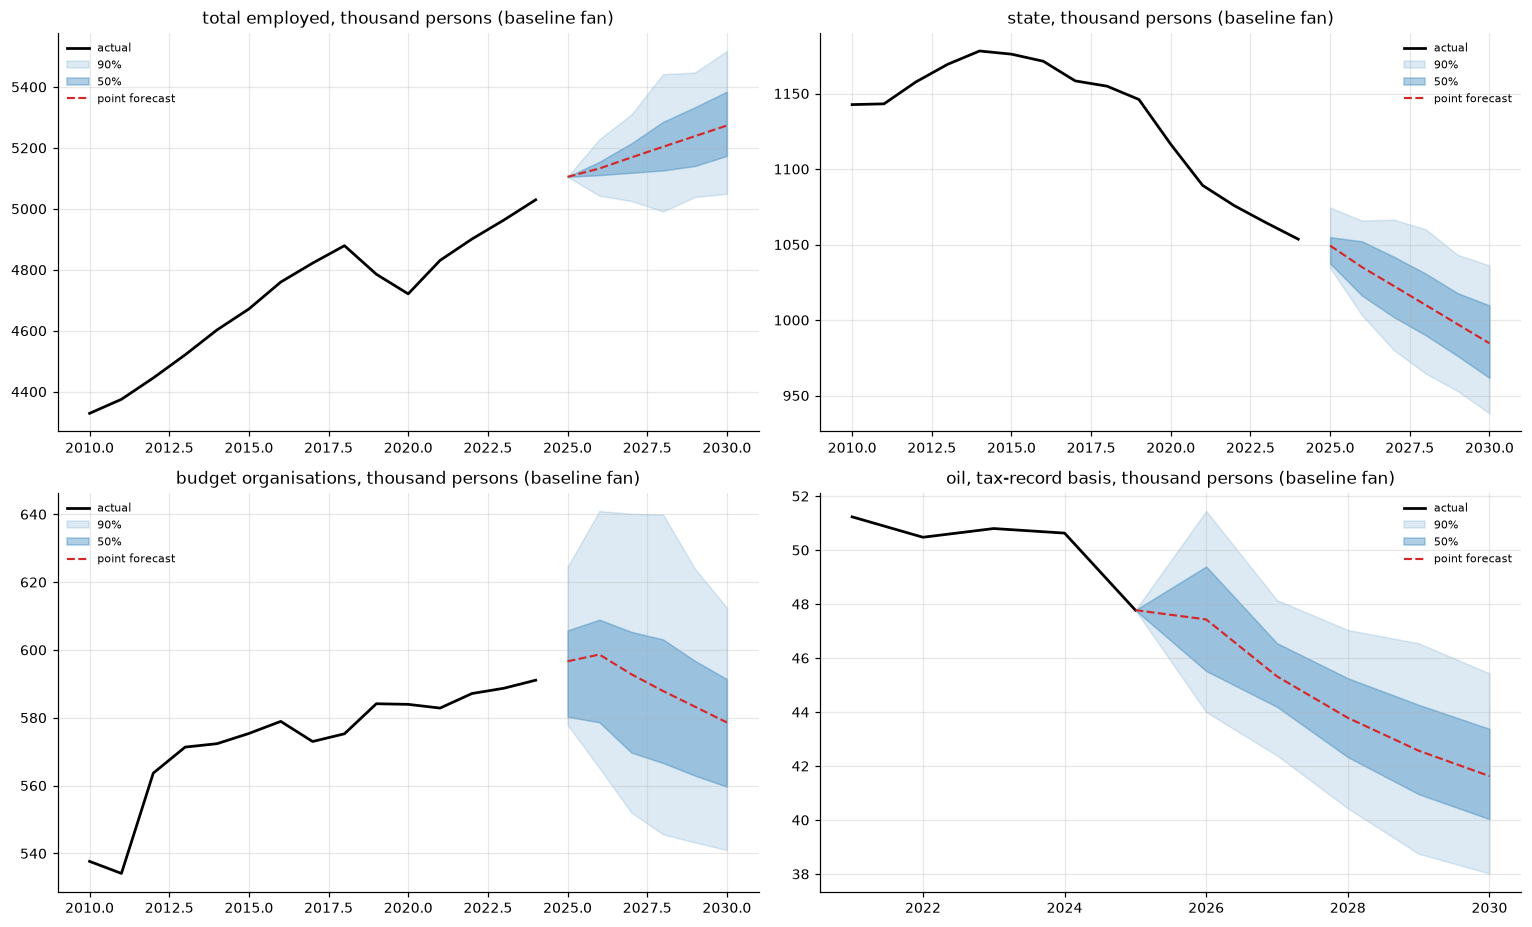

In [55]:
# ---------- 17.5  fan charts: historical residual-path resampling ---------------------------------
rs = np.random.default_rng(SEED)
N_REP = 2000
HY = YRS                                               # 2025 ... 2030 (share anchor 2024 -> h = 1..6)
nonref = [k for k in G8_KEYS if k != 'services']

def rule_resid(E8fr, beta):
    # historical error of the Tier-1 forecasting rule: log-odds net of the pooled output term
    dat, _ = logit_data(E8fr, G8_KEYS, 'services', Q8)
    return {k: dat[k].lo_se - beta * dat[k].lo_sq for k in nonref}
U = {}
for basis, E8fr, tag in [('employed population', E8, 'e'), ('hired employees', H8, 'h')]:
    for k, v in rule_resid(E8fr, BETA1[basis][0]).items():
        U[f't1{tag}_{k}'] = v
U['e6h'] = E6['hired employees'].resid
U['e8'] = f_e8.resid
U['phi'] = L(phi)
U['e2'] = f_e2.resid
U = pd.DataFrame(U).loc[BREAK + 1:LAST_DSK]
H_ = len(HY)
STARTS = [s for s in U.index if s + H_ <= U.index.max()]
PATHS = np.stack([U.loc[s + 1:s + H_].to_numpy() - U.loc[s].to_numpy()[None, :] for s in STARTS])   # S x H x K
PATHS = PATHS - PATHS.mean(axis=0, keepdims=True)                                                # centred
cols = list(U.columns); ci = {c: i for i, c in enumerate(cols)}
u9 = f_e9.resid
S9 = [s for s in u9.index if s + (H_ - 1) <= u9.index.max()]
P9 = np.stack([u9.loc[s + 1:s + H_ - 1].to_numpy() - u9.loc[s] for s in S9]); P9 = P9 - P9.mean(axis=0, keepdims=True)
print(f'residual-path pool: start years {STARTS[0]}-{STARTS[-1]} ({len(STARTS)} joint paths of {H_} years, '
      f'{len(cols)} equations); E9: start years {S9[0]}-{S9[-1]} ({len(S9)} paths)')

base_d = DRV['Baseline']
if FR1_DRAWS is not None:
    drw = FR1_DRAWS[FR1_DRAWS.year.isin(FC_YEARS)]
    need = ['emp', 'rgdpoil', 'rva_oth'] + [v for v in G8.values() if v != 'rind'] + ['rva_min', 'rva_man', 'rva_elc', 'rva_wat']
    DRW = {v: drw.pivot(index='draw', columns='year', values=v).reindex(columns=FC_YEARS) for v in set(need)}
    ok = np.all([np.isfinite(DRW[v].to_numpy()).all(axis=1) for v in DRW], axis=0)
    DRAW_IDS = list(DRW['emp'].index[ok])
    print(f'macro uncertainty: {len(DRAW_IDS)} FR1 replication paths ({(~ok).sum()} dropped as non-finite), '
          f'cycled over {N_REP} replications')
else:
    DRAW_IDS = None
    print('WARNING: FR1_fan_draws.csv absent - FALLBACK: macro drivers held at FR1\'s baseline; the total is')
    print('         shocked with FR4\'s own E2 residual paths. This line must not appear after the final re-run.')

def q8_path(did):
    q = pd.DataFrame(index=FC_YEARS, columns=G8_KEYS, dtype=float)
    for k, v in G8.items():
        q[k] = (sum(DRW[c].loc[did] for c in ['rva_min', 'rva_man', 'rva_elc', 'rva_wat']) * IND_RATIO
                if k == 'industry' else DRW[v].loc[did]).to_numpy(float)
    return pd.concat([base_d['q8'].loc[[LAST_ACT]], q])

def lo_sq_of(q8):
    return np.log(q8[nonref].to_numpy(float) / q8[['services']].to_numpy(float))
lo_sq24 = np.log(Q8.loc[LAST_DSK, nonref].astype(float).to_numpy() / float(Q8.loc[LAST_DSK, 'services']))
lo_sq24[nonref.index('industry')] = np.log(F.rind.loc[LAST_DSK] / Q8.loc[LAST_DSK, 'services'])
z_e = np.array([L(E8[k] / E8['services']).loc[LAST_DSK] for k in nonref])
z_h = np.array([L(H8[k] / H8['services']).loc[LAST_DSK] for k in nonref])
Mh = MODEL['hired employees']
b8, se8 = float(f_e8.lr['trend']), float(f_e8.se_lr['trend'])
b9, se9 = float(f_e9.lr['ln_rgdpoil']), float(f_e9.se_lr['ln_rgdpoil'])
se6h = float(E6['hired employees'].se_lr['ln_rva_oth']) if E6_USE else 0.0
h24 = np.asarray(HY, float) - LAST_DSK
st24 = float(np.log(EMP_PROP.state.loc[LAST_DSK] / EMP_PROP.nonstate.loc[LAST_DSK]))

def _sm(z):
    e = np.exp(np.column_stack([z, np.zeros(len(z))])); return e / e.sum(axis=1, keepdims=True)

def shares(z0, beta, dq, S, mode):
    zc = z0[None, :] + S; zo = zc + beta * dq
    return 0.5 * _sm(zc) + 0.5 * _sm(zo) if mode == COMBO else (_sm(zo) if mode == POOLED else _sm(zc))

def simulate(r, shocks=True, params=True):
    if DRAW_IDS is not None and shocks:
        did = DRAW_IDS[r % len(DRAW_IDS)]
        tot = np.r_[SOC.emp.loc[LAST_ACT], DRW['emp'].loc[did].to_numpy(float)]
        roil = np.r_[F.rgdpoil.loc[LAST_ACT], DRW['rgdpoil'].loc[did].to_numpy(float)]
        oth = np.r_[F.rva_oth.loc[LAST_ACT], DRW['rva_oth'].loc[did].to_numpy(float)]
        q8 = q8_path(did)
    else:
        tot = TOT['Baseline'].reindex(HY).to_numpy(float); roil = base_d['rgdpoil'].reindex(HY).to_numpy(float)
        oth = base_d['oth'].reindex(HY).to_numpy(float); q8 = base_d['q8'].loc[HY]
    S = PATHS[rs.integers(len(STARTS))] if shocks else np.zeros((H_, len(cols)))
    s9 = np.r_[0.0, P9[rs.integers(len(S9))]] if shocks else np.zeros(H_)
    if shocks and DRAW_IDS is None:
        tot = tot * np.exp(np.r_[0.0, S[1:, ci['e2']] - S[0, ci['e2']]])
    dr_ = lambda b, se: b + (rs.standard_normal() * se if params else 0.0)
    be, bh = dr_(BETA1['employed population'][0], BETA1['employed population'][1]), dr_(BETA1['hired employees'][0], BETA1['hired employees'][1])
    g6, g8, g9 = dr_(Mh['b6'], se6h), dr_(b8, se8), dr_(b9, se9)
    dq = lo_sq_of(q8) - lo_sq24[None, :]
    se_ = shares(z_e, be, dq, S[:, [ci[f't1e_{k}'] for k in nonref]], BEST1)
    sh_ = shares(z_h, bh, dq, S[:, [ci[f't1h_{k}'] for k in nonref]], BEST1)
    groups = se_ * tot[:, None]
    hired = tot * PHI_LVL * np.exp(S[:, ci['phi']])
    lr6 = (Mh['c6'] + Mh['b6'] * np.log(F.rva_oth.loc[LAST_DSK]) + Mh['addf6']
           + g6 * (np.log(oth) - np.log(F.rva_oth.loc[LAST_DSK])) + S[:, ci['e6h']])
    budget = SIGMA_PUB * hired * sh_[:, -1] / (1 + np.exp(lr6))
    od = np.exp(st24 + g8 * h24 + S[:, ci['e8']])
    state = tot * od / (1 + od)
    oil = DVX_OIL_ANCHOR * np.exp(g9 * (np.log(roil) - np.log(roil[0])) + s9)
    out = {'total employed': tot, 'hired employees': hired, 'state': state, 'budget organisations': budget,
           'oil, tax-record basis': oil, 'oil, statistical basis': OIL_STAT_ANCHOR * oil / DVX_OIL_ANCHOR}
    for j, k in enumerate(nonref + ['services']):
        out[G8_LABEL[k]] = groups[:, j]
    return out

# the zero-shock, point-parameter replication must reproduce the published baseline
p0 = simulate(0, shocks=False, params=False)
_B = FCAST[('Baseline', 'employed population')]
chk_fan = max(abs(p0['state'] / INST['Baseline'].state.reindex(HY).to_numpy() - 1).max(),
              abs(p0['budget organisations'] / INST['Baseline']['budget organisations'].reindex(HY).to_numpy() - 1).max(),
              abs(p0['oil, tax-record basis'] / INST['Baseline']['oil, tax-record basis'].reindex(HY).to_numpy() - 1).max(),
              max(abs(p0[G8_LABEL[g]] / _B[G8_MEMBERS[g]].sum(axis=1).reindex(HY).to_numpy() - 1).max() for g in G8_KEYS))
assert chk_fan < 1e-9, f'fan simulator does not reproduce the point forecast ({chk_fan:.2e})'
print(f'fan simulator with zero shocks reproduces the point forecast to {chk_fan:.1e}')

SIMS = [simulate(r) for r in range(N_REP)]
QS = [5, 10, 25, 50, 75, 90, 95]
fan_rows, iqr_fail = [], []
for v in SIMS[0]:
    A = np.array([s[v] for s in SIMS])
    G = (A[:, 1:] / A[:, :-1] - 1) * 100
    for j, y in enumerate(HY):
        qv = {f'q{q:02d}': float(np.percentile(A[:, j], q)) for q in QS}
        fan_rows.append(dict(variable=v, year=y, measure='level, thousand persons', point=float(p0[v][j]), **qv))
        if y > LAST_ACT and not (qv['q25'] - 1e-9 <= p0[v][j] <= qv['q75'] + 1e-9):
            iqr_fail.append((v, y, round(p0[v][j], 1), round(qv['q25'], 1), round(qv['q75'], 1)))
        if j > 0:
            fan_rows.append(dict(variable=v, year=y, measure='growth, % a year', point=float((p0[v][j] / p0[v][j - 1] - 1) * 100),
                                 **{f'q{q:02d}': float(np.percentile(G[:, j - 1], q)) for q in QS}))
    Gc = ((A[:, -1] / A[:, 0]) ** (1 / len(FC_YEARS)) - 1) * 100
    fan_rows.append(dict(variable=v, year='2026-2030', measure='average growth, % a year',
                         point=float(((p0[v][-1] / p0[v][0]) ** (1 / len(FC_YEARS)) - 1) * 100),
                         **{f'q{q:02d}': float(np.percentile(Gc, q)) for q in QS}))
FAN = pd.DataFrame(fan_rows)
FAN.to_csv(OUT / 'FR4_fan_employment.csv', index=False)
print(f'{N_REP} replications; saved -> FR4_fan_employment.csv ({len(FAN)} rows)')
summ = []
for v in SIMS[0]:
    l30 = FAN[(FAN.variable == v) & (FAN.year == FC_YEARS[-1]) & (FAN.measure.str.startswith('level'))].iloc[0]
    gav = FAN[(FAN.variable == v) & (FAN.year == '2026-2030')].iloc[0]
    summ.append(dict(variable=v, level_point=l30.point, level_q05=l30.q05, level_q25=l30.q25, level_q50=l30.q50,
                     level_q75=l30.q75, level_q95=l30.q95, growth_point=gav.point, growth_q05=gav.q05,
                     growth_q50=gav.q50, growth_q95=gav.q95))
FANSUM = pd.DataFrame(summ).set_index('variable')
print('\n2030 levels and 2026-2030 average growth, baseline: point forecast, quartiles and 90% band')
display(FANSUM.round(2))
print(f'\npoint forecasts outside their inter-quartile band (level, 2026-2030): {len(iqr_fail)}')
assert not iqr_fail, f'point forecast outside its inter-quartile band: {iqr_fail}'
print('Every point forecast lies inside its inter-quartile band.')

fig, ax = plt.subplots(2, 2, figsize=(14, 8.5))
for a, v, hist in [(ax[0, 0], 'total employed', EMP_ACT.total), (ax[0, 1], 'state', EMP_PROP.state),
                   (ax[1, 0], 'budget organisations', SIGMA_PUB * HIR_ACT[PUB].sum(axis=1)),
                   (ax[1, 1], 'oil, tax-record basis', DVX['oil'])]:
    f_ = FAN[(FAN.variable == v) & FAN.measure.str.startswith('level')].set_index('year')
    hh_ = hist.dropna().loc[2010:]
    a.plot(hh_.index, hh_.values, color='k', lw=1.8, label='actual')
    a.fill_between(f_.index.astype(int), f_.q05, f_.q95, color=PAL[0], alpha=0.15, label='90%')
    a.fill_between(f_.index.astype(int), f_.q25, f_.q75, color=PAL[0], alpha=0.35, label='50%')
    a.plot(f_.index.astype(int), f_.point, color=PAL[1], lw=1.4, ls='--', label='point forecast')
    a.set_title(f'{v}, thousand persons (baseline fan)'); a.legend(fontsize=7)
plt.tight_layout(); plt.show()


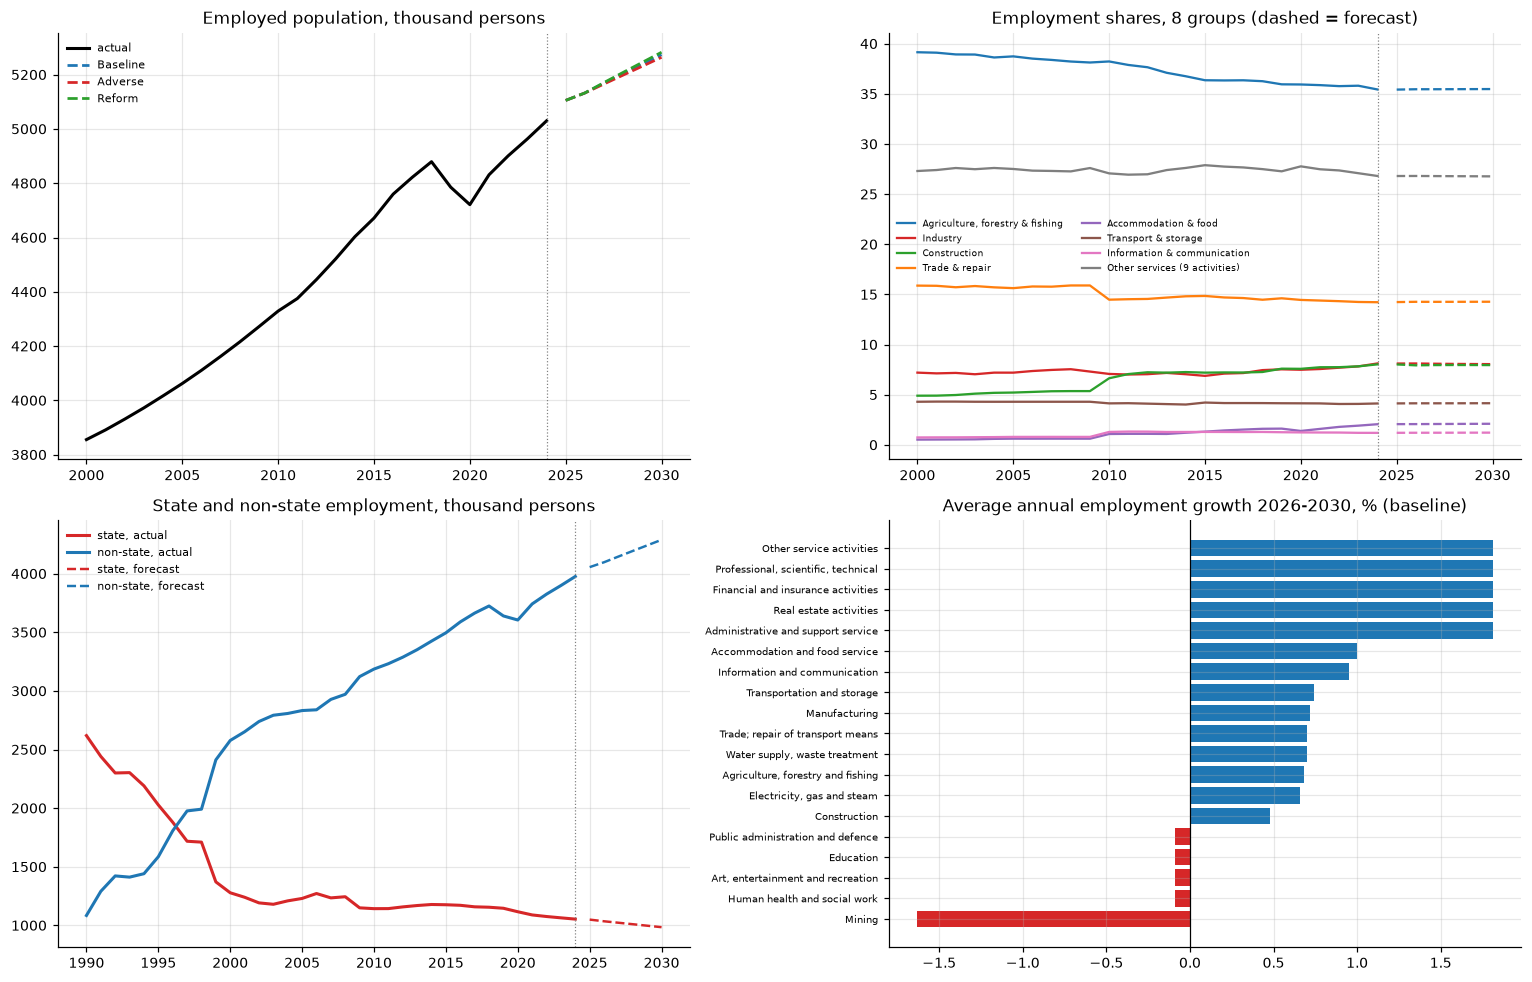

In [56]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))
a = ax[0, 0]
hh = EMP_ACT.total.loc[2000:]
a.plot(hh.index, hh, color='k', lw=2, label='actual')
for i, s in enumerate(SCEN):
    a.plot(TOT[s].index, TOT[s], color=PAL[i], lw=1.8, ls='--', label=s)
a.axvline(LAST_DSK, color='grey', lw=0.8, ls=':')
a.set_title('Employed population, thousand persons'); a.legend(fontsize=7)

a = ax[0, 1]
sh_h = EMP_ACT[G8_KEYS[:0]] if False else None
for i, k in enumerate(G8_KEYS):
    hist = (E8[k] / E8.total * 100).loc[2000:]
    fut = (B[G8_MEMBERS[k]].sum(axis=1) / B.total * 100)
    a.plot(hist.index, hist, color=PAL[i], lw=1.5, label=G8_LABEL[k])
    a.plot(fut.index, fut, color=PAL[i], lw=1.5, ls='--')
a.axvline(LAST_DSK, color='grey', lw=0.8, ls=':')
a.set_title('Employment shares, 8 groups (dashed = forecast)'); a.legend(fontsize=6, ncol=2)

a = ax[1, 0]
a.plot(EMP_PROP.index, EMP_PROP.state, color=PAL[1], lw=2, label='state, actual')
a.plot(EMP_PROP.index, EMP_PROP.nonstate, color=PAL[0], lw=2, label='non-state, actual')
a.plot(I.index, I.state, color=PAL[1], lw=1.6, ls='--', label='state, forecast')
a.plot(I.index, I['non-state'], color=PAL[0], lw=1.6, ls='--', label='non-state, forecast')
a.axvline(LAST_DSK, color='grey', lw=0.8, ls=':')
a.set_title('State and non-state employment, thousand persons'); a.legend(fontsize=7)

a = ax[1, 1]
gr = gg['2026-2030 average'].drop('TOTAL').sort_values()
a.barh(range(len(gr)), gr.values, color=[PAL[0] if v >= 0 else PAL[1] for v in gr.values])
a.set_yticks(range(len(gr))); a.set_yticklabels(gr.index, fontsize=6.5)
a.axvline(0, color='k', lw=0.8)
a.set_title('Average annual employment growth 2026-2030, % (baseline)')
plt.tight_layout(); plt.show()

## Part 18 — Scenarios and the levers that matter

Two distinct kinds of uncertainty are separated here, because conflating them is how forecast ranges
become meaningless.

**Scenario uncertainty** comes from FR1: the Baseline, Adverse and Reform paths for output. FR4 inherits
them, so its employment scenarios are the labour-market image of FR1's macro scenarios and nothing more.

**Assumption and policy uncertainty** is FR4's own, and there are six such levers and sensitivities. Each is something
the model cannot estimate — either because it is a political decision or because the data do not
identify it — and each was flagged as such where it arose:

| Lever / sensitivity | Where it came from | Why it is a lever, not a forecast |
|---|---|---|
| Population growth ±0.3pp | Part 15 | FR1's population path is an assumption (recent average growth); the lever moves population, the labour force and employment together (unit elasticity) and income per head |
| The employee share | E3, Part 11 | Trendless and U-shaped; raising it is a formalisation objective |
| The state-employment share | E8, Part 14.1 | No fiscal or output driver passes the level and difference tests |
| The budget-sector definition | Part 14.2 | DVX r130 counted all four activities to 2024 and (apparently) only the state part in 2025 |
| The sector-allocation weights | Part 12.5 | The baseline is an equal-weight combination; pure constant shares, the pooled system alone and the group-specific drivers are shown |
| Add-factor decay (sensitivity only) | Part 15.2 | Constant add-factors are the neutral choice; the sensitivity lets each decay at its residual autocorrelation |


In [57]:
rows = []
for s in SCEN:
    d, I = DRV[s], INST[s]
    E = FCAST[(s, 'employed population')]
    rows.append(dict(scenario=s,
                     employed_2030=float(TOT[s].loc[FC_YEARS[-1]]),
                     employed_growth_pa=float((TOT[s].loc[FC_YEARS[-1]] / TOT[s].loc[LAST_ACT])
                                              ** (1 / len(FC_YEARS)) - 1) * 100,
                     state_2030=float(I.state.loc[FC_YEARS[-1]]),
                     state_share_2030=float(I['state share, %'].loc[FC_YEARS[-1]]),
                     budget_2030=float(I['budget organisations'].loc[FC_YEARS[-1]]),
                     oil_tax_2030=float(I['oil, tax-record basis'].loc[FC_YEARS[-1]]),
                     agriculture_2030=float(E.agr.loc[FC_YEARS[-1]]),
                     services_2030=float(E[SVC].sum(axis=1).loc[FC_YEARS[-1]])))
SC = pd.DataFrame(rows).set_index('scenario')
print('Scenario comparison, 2030 (thousand persons except where noted)')
display(SC.round(2))
print()
sp = pd.DataFrame({c: FC.pivot(index='year', columns='scenario', values=c).loc[FC_YEARS[-1]]
                   for c in ['rgdpnon', 'rgdpoil', 'emp', 'lf']})
print(f'Where FR1\'s scenarios actually differ, in {FC_YEARS[-1]}:')
display(sp.round(0))
print('    spread, %: ' + ', '.join(
    f'{c} {(sp[c].max()/sp[c].min()-1)*100:.2f}' for c in sp.columns))
print()
print(f'FR4\'s employment scenarios differ by only {SC.employed_2030.max()-SC.employed_2030.min():.1f} thousand in {FC_YEARS[-1]} '
      f'({(SC.employed_2030.max()/SC.employed_2030.min()-1)*100:.2f}%).')
_spr = {c: (sp[c].max() / sp[c].min() - 1) * 100 for c in sp.columns}
print(f'That is INHERITED, not a property of FR4: FR1\'s three scenarios differ by {_spr["rgdpoil"]:.0f}% in real OIL')
print(f'GDP and {_spr["rgdpnon"]:.1f}% in real NON-OIL GDP, but by only {_spr["emp"]:.2f}% in employment and '
      f'{_spr["lf"]:.2f}% in the labour force.')
print('Since FR4 adopts FR1\'s total and gives relative output only half a small elasticity, the')
print('employment scenarios cannot diverge much. This should not be read as evidence that the')
print('Azerbaijani labour market is insensitive to macroeconomic conditions; it reflects how the')
print('FR1 scenarios were constructed, which concentrated the divergence in hydrocarbons.')
print()
print('The scenarios DO separate where the oil channel bites, because the oil-employment elasticity')
print(f'is {f_e9.lr["ln_rgdpoil"]:.2f} (descriptive; Part 14.3) against {f_e2.lr["ln_rgdpnon"]:.2f} for the aggregate employment rate:')
print()
oil_sc = pd.DataFrame({s: INST[s]['oil, tax-record basis'] for s in SCEN}).round(2)
display(oil_sc)
print(f'    By {FC_YEARS[-1]} the Adverse path has {INST["Reform"]["oil, tax-record basis"].loc[FC_YEARS[-1]] - INST["Adverse"]["oil, tax-record basis"].loc[FC_YEARS[-1]]:.1f} thousand FEWER oil-sector jobs than Reform')
print(f'    ({INST["Adverse"]["oil, tax-record basis"].loc[FC_YEARS[-1]]:.1f} against {INST["Reform"]["oil, tax-record basis"].loc[FC_YEARS[-1]]:.1f}), a spread of '
      f'{(INST["Reform"]["oil, tax-record basis"].loc[FC_YEARS[-1]]/INST["Adverse"]["oil, tax-record basis"].loc[FC_YEARS[-1]]-1)*100:.1f}% against {(SC.employed_2030.max()/SC.employed_2030.min()-1)*100:.2f}% for total employment.')

Scenario comparison, 2030 (thousand persons except where noted)


,employed_2030,employed_growth_pa,state_2030,state_share_2030,budget_2030,oil_tax_2030,agriculture_2030,services_2030
scenario,,,,,,,,
Baseline,"5,273.520",0.650,984.650,18.670,578.640,41.630,"1,870.960","1,411.840"
Adverse,"5,263.990",0.610,982.870,18.670,583.820,37.640,"1,871.520","1,411.090"
Reform,"5,282.630",0.690,986.350,18.670,574.040,43.690,"1,872.170","1,412.660"



Where FR1's scenarios actually differ, in 2030:


,rgdpnon,rgdpoil,emp,lf
scenario,,,,
Adverse,"59,563.000","10,547.000","5,264.000","5,528.000"
Baseline,"62,854.000","11,961.000","5,274.000","5,528.000"
Reform,"66,159.000","12,706.000","5,283.000","5,528.000"


    spread, %: rgdpnon 11.07, rgdpoil 20.47, emp 0.35, lf 0.00

FR4's employment scenarios differ by only 18.6 thousand in 2030 (0.35%).
That is INHERITED, not a property of FR4: FR1's three scenarios differ by 20% in real OIL
GDP and 11.1% in real NON-OIL GDP, but by only 0.35% in employment and 0.00% in the labour force.
Since FR4 adopts FR1's total and gives relative output only half a small elasticity, the
employment scenarios cannot diverge much. This should not be read as evidence that the
Azerbaijani labour market is insensitive to macroeconomic conditions; it reflects how the
FR1 scenarios were constructed, which concentrated the divergence in hydrocarbons.

The scenarios DO separate where the oil channel bites, because the oil-employment elasticity
is 0.80 (descriptive; Part 14.3) against 0.08 for the aggregate employment rate:



,Baseline,Adverse,Reform
2025,47.780,47.780,47.780
2026,47.430,47.430,47.430
2027,45.320,44.400,46.080
2028,43.790,41.880,45.120
2029,42.570,39.670,44.360
2030,41.630,37.640,43.690


    By 2030 the Adverse path has 6.1 thousand FEWER oil-sector jobs than Reform
    (37.6 against 43.7), a spread of 16.1% against 0.35% for total employment.


In [58]:
# ---------- the levers and sensitivities ---------------------------------------------------------
LEV = []
base_I, base_E = INST['Baseline'], FCAST[('Baseline', 'employed population')]
Y30 = FC_YEARS[-1]

# (1) population growth +/- 0.3 pp: population, labour force and employment move together
for dg, lab in [(-0.003, 'population growth 0.3pp lower'), (0.003, 'population growth 0.3pp higher')]:
    P2 = POP.copy()
    for i, y in enumerate(FC_YEARS):
        P2.loc[y] = POP.loc[LAST_ACT] * (POP.loc[y] / POP.loc[LAST_ACT]) * (1 + dg) ** (i + 1)
    scale = (P2 / POP).reindex(YRS)
    d2 = dict(DRV['Baseline'])
    d2['ypc'] = pd.Series({y: float(np.log(d2['rgdpnon'].loc[y] / P2.loc[y])) for y in YRS})
    tot2 = TOT['Baseline'] * scale
    alt = allocate('employed population', d2, YRS, [float(tot2.loc[y]) for y in YRS])
    LEV.append(dict(lever=lab, total_2030=float(alt.total.loc[Y30]),
                    labour_force_2030=float((LFH['Baseline'] * scale).loc[Y30]),
                    agriculture_2030=float(alt.agr.loc[Y30]),
                    services_2030=float(alt[SVC].sum(axis=1).loc[Y30]),
                    construction_2030=float(alt.constr.loc[Y30])))

# (2) formalisation: the employee share rises by 2 points by 2030
phi_path = pd.Series({y: PHI_LVL + 0.02 * (y - LAST_ACT) / (Y30 - LAST_ACT) for y in YRS})
hir_alt = TOT['Baseline'] * phi_path
alt_h = allocate('hired employees', DRV['Baseline'], YRS, [float(hir_alt.loc[y]) for y in YRS])
LEV.append(dict(lever='employee share +2pp by 2030', hired_2030=float(hir_alt.loc[Y30]),
                budget_2030=float(SIGMA_PUB * alt_h[PUB].sum(axis=1).loc[Y30]),
                nonbudget_2030=float(hir_alt.loc[Y30] - SIGMA_PUB * alt_h[PUB].sum(axis=1).loc[Y30])))

# (3) state share frozen at its last actual value instead of continuing to decline
st_fix = TOT['Baseline'] * float(EMP_PROP.state.loc[LAST_DSK] / EMP_PROP.total.loc[LAST_DSK])
LEV.append(dict(lever=f'state share frozen at its {LAST_DSK} level', state_2030=float(st_fix.loc[Y30]),
                nonstate_2030=float(TOT['Baseline'].loc[Y30] - st_fix.loc[Y30])))

# (4) the first version's budget definition: all hired employees of the four activities
HB_ = FCAST[('Baseline', 'hired employees')]
LEV.append(dict(lever=f'budget = all hired in the 4 activities (kappa = {KAPPA_ALL:.3f}, first version)',
                budget_2030=float(KAPPA_ALL * HB_[PUB].sum(axis=1).loc[Y30])))

# (5) the sector-allocation alternatives: pure constant shares, the pooled system alone, and the two
#     group-specific drivers that were not adopted
_tot = [float(TOT['Baseline'].loc[y]) for y in YRS]
_alts = [('Tier 1 + industry: pure constant shares', dict(mode1='constant shares', mode2='constant shares')),
         ('Tier 1 + industry: pooled output system alone', dict(mode1=POOLED, mode2=POOLED))]
for alt_name in ['relative output share', 'income per capita']:
    par_, dat_ = TIER1_ALT[('employed population', alt_name)]
    _alts.append((f'Tier-1 driver: group-specific {alt_name} (not adopted)',
                  dict(M=dict(MODEL['employed population'], t1=dict(mode='alt', parC=par_, parO=None, dat=dat_)))))
for lab, kw in _alts:
    alt = allocate('employed population', DRV['Baseline'], YRS, _tot, **kw)
    LEV.append(dict(lever=lab, agriculture_2030=float(alt.agr.loc[Y30]), construction_2030=float(alt.constr.loc[Y30]),
                    hotel_2030=float(alt.hotel.loc[Y30]), ict_2030=float(alt.ict.loc[Y30]),
                    industry_2030=float(alt[IND].sum(axis=1).loc[Y30]), mining_2030=float(alt.mining.loc[Y30]),
                    services_2030=float(alt[SVC].sum(axis=1).loc[Y30])))

# (6) add-factors decaying at each equation's residual autocorrelation (decision 4 sensitivity)
FCAST_DECAY = {('Baseline', b): allocate(b, DRV['Baseline'], YRS,
                                          [float((TOT if b.startswith('employed') else HIR)['Baseline'].loc[y]) for y in YRS],
                                          decay=True)
               for b in ['employed population', 'hired employees']}
ID = institutions('Baseline', decay=True)
LEV.append(dict(lever='SENSITIVITY ONLY: add-factors decay at residual rho (E6, E8)', state_2030=float(ID.state.loc[Y30]),
                budget_2030=float(ID['budget organisations'].loc[Y30]),
                services_2030=float(FCAST_DECAY[('Baseline', 'employed population')][SVC].sum(axis=1).loc[Y30]),
                market_services_2030=float(FCAST_DECAY[('Baseline', 'employed population')][MKT].sum(axis=1).loc[Y30])))
AFT = pd.DataFrame([dict(equation='E6 bloc split, employed', add_factor=MODEL['employed population']['addf6'], rho=MODEL['employed population']['rho6']),
                    dict(equation='E6 bloc split, hired', add_factor=MODEL['hired employees']['addf6'], rho=MODEL['hired employees']['rho6']),
                    dict(equation='E8 state share', add_factor=float(f_e8.resid.loc[LAST_DSK]), rho=f_e8.rho),
                    dict(equation='E9 oil (anchored on 2025 actual)', add_factor=float(f_e9.resid.loc[LAST_ACT]), rho=f_e9.rho),
                    dict(equation='Tier 1 / Tier 2a / E7 (constant shares)', add_factor=0.0, rho=np.nan)]).set_index('equation')
print('Base add-factors (log points) and residual first-order autocorrelation used for the decay sensitivity:')
display(AFT.round(4))

LV = pd.DataFrame(LEV)
BASE_REF = {'total_2030': float(base_E.total.loc[Y30]), 'labour_force_2030': float(LFH['Baseline'].loc[Y30]),
            'agriculture_2030': float(base_E.agr.loc[Y30]),
            'services_2030': float(base_E[SVC].sum(axis=1).loc[Y30]),
            'market_services_2030': float(base_E[MKT].sum(axis=1).loc[Y30]),
            'construction_2030': float(base_E.constr.loc[Y30]), 'mining_2030': float(base_E.mining.loc[Y30]), 'hotel_2030': float(base_E.hotel.loc[Y30]),
            'ict_2030': float(base_E.ict.loc[Y30]), 'industry_2030': float(base_E[IND].sum(axis=1).loc[Y30]),
            'hired_2030': float(base_I['hired, total'].loc[Y30]),
            'budget_2030': float(base_I['budget organisations'].loc[Y30]),
            'nonbudget_2030': float(base_I['non-budget'].loc[Y30]),
            'state_2030': float(base_I.state.loc[Y30]), 'nonstate_2030': float(base_I['non-state'].loc[Y30])}
tidy = []
for _, r in LV.iterrows():
    for q, v in r.items():
        if q == 'lever' or pd.isna(v):
            continue
        b = BASE_REF[q]
        tidy.append(dict(lever=r.lever, quantity=q.replace('_2030', ''), baseline=round(b, 1),
                         alternative=round(float(v), 1), difference=round(float(v) - b, 1),
                         difference_pct=round((float(v) / b - 1) * 100, 2)))
LVT = pd.DataFrame(tidy)
print(f'\nSensitivity of the {Y30} forecast (thousand persons)')
display(LVT.set_index(['lever', 'quantity']))
def _d(lev, q):
    r = LVT[(LVT.lever.str.startswith(lev)) & (LVT.quantity == q)]
    return (float(r.difference.iloc[0]), float(r.difference_pct.iloc[0])) if len(r) else (np.nan, np.nan)
print('\nReading the table:')
print(f' - STATE SHARE frozen: {_d("state share", "state")[0]:+.1f} thousand ({_d("state share", "state")[1]:+.1f}%) - the largest single swing,')
print('   and a political decision rather than an econometric one.')
print(f' - SECTOR ALLOCATION: pure constant shares would put 2030 construction {_d("Tier 1 + industry: pure", "construction")[1]:+.1f}% and ICT '
      f'{_d("Tier 1 + industry: pure", "ict")[1]:+.1f}% away from the baseline;')
print(f'   the pooled system alone {_d("Tier 1 + industry: pooled", "construction")[1]:+.1f}% and {_d("Tier 1 + industry: pooled", "ict")[1]:+.1f}%. '
      f'Group-specific income per capita: construction {_d("Tier-1 driver: group-specific income", "construction")[1]:+.1f}%,')
print(f'   accommodation {_d("Tier-1 driver: group-specific income", "hotel")[1]:+.1f}% - compositional stories the data could not confirm.')
print(f' - FORMALISATION adds {_d("employee share", "hired")[0]:.1f} thousand employees, total employment unchanged.')
print(f' - The first version\'s BUDGET definition would add {_d("budget = all", "budget")[0]:+.1f} thousand to 2030 budget employment.')
print(f' - POPULATION +/-0.3pp moves total employment and the labour force by about {abs(_d("population growth 0.3pp higher", "total")[1]):.1f}%;')
print('   and leaves sector shares unchanged (no allocation equation in the baseline uses population).')
print(f' - ADD-FACTOR DECAY (a sensitivity only, not a forecast rule) moves 2030 state employment by {_d("SENSITIVITY ONLY", "state")[1]:+.2f}% and market services by '
      f'{_d("SENSITIVITY ONLY", "market_services")[1]:+.2f}%.')


Base add-factors (log points) and residual first-order autocorrelation used for the decay sensitivity:


,add_factor,rho
equation,,
"E6 bloc split, employed",0.054,0.847
"E6 bloc split, hired",0.028,0.629
E8 state share,-0.018,0.524
E9 oil (anchored on 2025 actual),-0.040,0.000
Tier 1 / Tier 2a / E7 (constant shares),0.000,NaN



Sensitivity of the 2030 forecast (thousand persons)


baseline  alternative  difference  difference_pct
lever                                              quantity                                                          
population growth 0.3pp lower                      total           5,273.500    5,194.900     -78.600          -1.490
                                                   labour_force    5,528.100    5,445.700     -82.400          -1.490
                                                   agriculture     1,871.000    1,843.100     -27.900          -1.490
                                                   services        1,411.800    1,390.800     -21.100          -1.490
                                                   construction      419.400      413.200      -6.300          -1.490
population growth 0.3pp higher                     total           5,273.500    5,353.100      79.600           1.510
                                                   labour_force    5,528.100    5,611.500      83.400           1.510
                                                   agriculture     1,871.000    1,899.200      28.200           1.510
                                                   services        1,411.800    1,433.100      21.300           1.510
                                                   construction      419.400      425.700       6.300           1.510
employee share +2pp by 2030                        hired           1,866.600    1,972.000     105.500           5.650
                                                   budget            578.600      611.300      32.700           5.650
                                                   nonbudget       1,287.900    1,360.700      72.800           5.650
state share frozen at its 2024 level               state             984.700    1,104.700     120.000          12.190
                                                   nonstate        4,288.900    4,168.900    -120.000          -2.800
budget = all hired in the 4 activities (kappa =... budget            578.600      629.800      51.200           8.840
Tier 1 + industry: pure constant shares            agriculture     1,871.000    1,868.700      -2.300          -0.120
                                                   services        1,411.800    1,413.800       2.000           0.140
                                                   construction      419.400      423.400       4.000           0.940
                                                   hotel             110.900      108.600      -2.300          -2.060
                                                   ict                64.300       63.100      -1.200          -1.820
                                                   industry          424.500      428.200       3.700           0.870
                                                   mining             35.700       35.800       0.100           0.310
Tier 1 + industry: pooled output system alone      agriculture     1,871.000    1,873.300       2.300           0.120
                                                   services        1,411.800    1,409.800      -2.000          -0.140
                                                   construction      419.400      415.500      -4.000          -0.940
                                                   hotel             110.900      113.200       2.300           2.060
                                                   ict                64.300       65.500       1.200           1.820
                                                   industry          424.500      420.800      -3.700          -0.870
                                                   mining             35.700       35.600      -0.100          -0.310
Tier-1 driver: group-specific relative output s... agriculture     1,871.000    1,859.200     -11.800          -0.630
                                                   services        1,411.800    1,413.500       1.600           0.120
                                                   const


Reading the table:
 - STATE SHARE frozen: +120.0 thousand (+12.2%) - the largest single swing,
   and a political decision rather than an econometric one.
 - SECTOR ALLOCATION: pure constant shares would put 2030 construction +0.9% and ICT -1.8% away from the baseline;
   the pooled system alone -0.9% and +1.8%. Group-specific income per capita: construction +4.9%,
   accommodation +9.9% - compositional stories the data could not confirm.
 - FORMALISATION adds 105.5 thousand employees, total employment unchanged.
 - The first version's BUDGET definition would add +51.2 thousand to 2030 budget employment.
 - POPULATION +/-0.3pp moves total employment and the labour force by about 1.5%;
   and leaves sector shares unchanged (no allocation equation in the baseline uses population).
 - ADD-FACTOR DECAY (a sensitivity only, not a forecast rule) moves 2030 state employment by +1.44% and market services by -2.09%.


## Part 19 — Identity and consistency checks

Ten identity and anchor checks, each of which would invalidate part of the forecast if it failed.
They are run on the published forecast, not on a special case. Two were corrected in the revision:
check 5 now closes oil + non-oil **within** each measurement basis (the first version subtracted
tax-record oil from the survey-basis hired total), and check 8 now compares FR1's employment with
FR1's own labour force (the first version set FR1's employment against FR4's own labour-force block).
Checks 10 and 11 are new: the 2025 anchors are reproduced, and the employee share follows one path.


In [59]:
CH = []
def check(name, value, tol, unit='%'):
    CH.append(dict(check=name, result=value, tolerance=tol, unit=unit, passed=abs(value) <= tol))

# 1-2  the 19 activities sum to the total, on both bases, in every scenario and year
w = 0.0
for (s, basis), fr in FCAST.items():
    w = max(w, float((fr[ACT_KEYS].sum(axis=1) / fr['total'] - 1).abs().max() * 100))
check('19 activities sum to total employment (all scenarios, both bases)', w, 1e-9)

# 3  state + non-state = total
w = max(float(((INST[s].state + INST[s]['non-state']) / INST[s]['employed, total'] - 1).abs().max() * 100)
        for s in SCEN)
check('state + non-state = employed population', w, 1e-9)

# 4  budget + non-budget = hired
w = max(float(((INST[s]['budget organisations'] + INST[s]['non-budget']) / INST[s]['hired, total'] - 1)
              .abs().max() * 100) for s in SCEN)
check('budget + non-budget = hired employees', w, 1e-9)

# 5  oil + non-oil = total, WITHIN each basis
w = max(max(float(((INST[s]['oil, tax-record basis'] + INST[s]['non-oil, tax-record basis'])
                   / INST[s]['employment contracts, tax-record basis'] - 1).abs().max() * 100),
            float(((INST[s]['oil, statistical basis'] + INST[s]['non-oil, statistical basis (hired)'])
                   / INST[s]['hired, total'] - 1).abs().max() * 100)) for s in SCEN)
check('oil + non-oil = total within each basis (tax: contracts; statistical: DSK hired)', w, 1e-9)

# 6  the anchor year is reproduced exactly
w = 0.0
for basis, Efr in [('employed population', EMP_ACT), ('hired employees', HIR_ACT)]:
    chk = allocate(basis, hist_dr, [ANCHOR_SH], [float(Efr['total'].loc[ANCHOR_SH])])
    w = max(w, float((chk[ACT_KEYS] / Efr[ACT_KEYS].loc[[ANCHOR_SH]] - 1).abs().max().max() * 100))
check(f'model reproduces every activity in {ANCHOR_SH}', w, 1e-6)

# 7  shares stay inside (0,1) over the whole horizon
mn = min(float((FCAST[(s, b)][ACT_KEYS].div(FCAST[(s, b)]['total'], axis=0)).min().min())
         for s in SCEN for b in ['employed population', 'hired employees'])
check('smallest activity share over the horizon (must exceed 0)', -mn if mn <= 0 else 0.0, 1e-12)

# 8  total employment never exceeds the labour force - both from the SAME source (FR1)
w = max(float((TOT[s].loc[FC_YEARS] / LFH[s].loc[FC_YEARS]).max()) for s in SCEN)
check('employment / labour force (both FR1) must stay below 1 (reported as the excess)',
      max(0.0, w - 1.0) * 100, 0.0)

# 9  every estimated equation that needs an add-factor applies it
missing = [f'E6 {b}' for b in MODEL if E6_USE and MODEL[b]['addf6'] == 0.0]
for basis in MODEL:
    for nm in ['parC', 'parO']:
        for k, p in MODEL[basis]['t1'][nm].items():
            if k != 'services' and 'addf' not in p:
                missing.append(f'Tier1 {nm} {basis} {k}')
check('every adjusted equation applies its add-factor (count of omissions)', len(missing), 0, 'count')

# 10  the 2025 anchors are reproduced: FR4 own-block labour force, both oil bases, hired = phi x total
w = max(abs(cmpt['Baseline'].loc[LAST_ACT, 'LF diff, %']),
        abs(INST['Baseline'].loc[LAST_ACT, 'oil, statistical basis'] / OIL_STAT_ANCHOR - 1) * 100,
        abs(INST['Baseline'].loc[LAST_ACT, 'oil, tax-record basis'] / DVX_OIL_ANCHOR - 1) * 100,
        abs(INST['Baseline'].loc[LAST_ACT, 'employment contracts, tax-record basis'] / DVX.contracts_tot.loc[LAST_ACT] - 1) * 100)
check(f'{LAST_ACT} anchors reproduced (own-block LF, oil on both bases, tax-record contracts)', w, 1e-9)

# 11  one employee-share path: hired / employed identical in every year (no 2026 jump)
w = max(float((HIR[s] / TOT[s]).max() / (HIR[s] / TOT[s]).min() - 1) * 100 for s in SCEN)
check('hired / employed constant over 2025-2030 (no artificial jump)', w, 1e-9)

CHK_T = pd.DataFrame(CH)
display(CHK_T)
assert CHK_T.passed.all(), f'failed checks: {CHK_T[~CHK_T.passed].check.tolist()}'
print(f'All {len(CHK_T)} identity and anchor checks pass.')

,check,result,tolerance,unit,passed
0,19 activities sum to total employment (all sce...,0.000,0.000,%,True
1,state + non-state = employed population,0.000,0.000,%,True
2,budget + non-budget = hired employees,0.000,0.000,%,True
3,oil + non-oil = total within each basis (tax: ...,0.000,0.000,%,True
4,model reproduces every activity in 2024,0.000,0.000,%,True
5,smallest activity share over the horizon (must...,0.000,0.000,%,True
6,employment / labour force (both FR1) must stay...,0.000,0.000,%,True
7,every adjusted equation applies its add-factor...,0.000,0.000,count,True
8,"2025 anchors reproduced (own-block LF, oil on ...",0.000,0.000,%,True
9,hired / employed constant over 2025-2030 (no a...,0.000,0.000,%,True


All 10 identity and anchor checks pass.


In [60]:
print('19.2 - the 2025 nowcast against the workbook tax records: a WEAK check')
print()
nb25 = FCAST[('Baseline', 'hired employees')].loc[LAST_ACT]
cmp25 = pd.DataFrame({'FR4 nowcast (DSK basis)': [float(nb25[G8_MEMBERS[g]].sum()) for g in DVX_MAP],
                      'workbook DVX 2025 (tax basis)': [float(DVX[g].loc[LAST_ACT]) for g in DVX_MAP]},
                     index=[G8_LABEL[g] if g in G8_LABEL else g for g in DVX_MAP])
cmp25['ratio'] = cmp25.iloc[:, 1] / cmp25.iloc[:, 0]
ratio24 = pd.Series({g: float(DVX[g].loc[LAST_DSK] / HIR_ACT[ks].sum(axis=1).loc[LAST_DSK])
                     for g, ks in DVX_MAP.items()})
cmp25['same ratio in 2024'] = ratio24.values
cmp25['drift'] = cmp25['ratio'] - cmp25['same ratio in 2024']
display(cmp25.round(3))
print(f'    mean absolute drift in the DVX/DSK sector ratio between {LAST_DSK} and {LAST_ACT}: '
      f'{cmp25.drift.abs().mean():.3f}')
print('    How much this shows, honestly: the 2025 nowcast shares are the 2024 shares moved by half the pooled')
print('    response to one year of output shares, and the DVX series are a different measurement basis. So the')
print('    drift column mostly compares each sector\'s 2024->2025 growth in the tax records with the growth')
print('    of the total. A small drift says the tax records do not contradict the nowcast; it is not an')
print('    independent test of the share model, and the first version overstated it as one.')
print()
print('19.3 — consistency with FR3')
f3 = W3[W3.scenario == 'Baseline'].set_index('year')
c3 = pd.DataFrame({'FR4 hired (DSK basis)': HIR['Baseline'].reindex(FC_YEARS),
                   'FR3 hired (DVX monthly-average basis)': f3.hired.reindex(FC_YEARS)})
c3['ratio'] = c3.iloc[:, 0] / c3.iloc[:, 1]
c3['FR4 growth, %'] = c3.iloc[:, 0].pct_change() * 100
c3['FR3 growth, %'] = c3.iloc[:, 1].pct_change() * 100
display(c3.round(3))
gd = float((c3['FR4 growth, %'] - c3['FR3 growth, %']).abs().max())
print(f'    The two levels differ by a constant {1-c3.ratio.mean():.1%} — the definitional wedge of finding F5,')
print(f'    not a disagreement, and the growth rates agree to {gd:.3f} percentage points.')
print('    An honest qualification: this agreement is largely BY CONSTRUCTION. FR3 built its employee')
print('    count as a fixed proportion of FR1\'s total employment, and FR4 does the same on its own')
print('    basis (E3), so both inherit FR1\'s growth path. The check therefore confirms that the two')
print('    deliverables are mutually CONSISTENT — they will never publish contradictory employee')
print('    growth - but it is not independent corroboration of either; nor is 19.2. The only independent')
print('    evidence on FR4\'s employee path is the Part 16 hold-out.')
print()
wb = (FCAST[('Baseline', 'hired employees')].total.reindex(FC_YEARS) * f3.w_avg * 12 / 1000)
c4 = pd.DataFrame({'FR4 hired x FR3 wage x 12, mn manat': wb, 'FR3 wage bill': f3.wagebill})
c4['ratio'] = c4.iloc[:, 0] / c4.iloc[:, 1]
display(c4.round(2))
print(f'    The implied wage bill is {1-c4.ratio.mean():.1%} below FR3\'s, which is the same wedge again,')
print('    applied consistently: FR3 builds its wage bill on the tax-record employee count.')

19.2 - the 2025 nowcast against the workbook tax records: a WEAK check



,FR4 nowcast (DSK basis),workbook DVX 2025 (tax basis),ratio,same ratio in 2024,drift
Industry,247.014,196.760,0.797,0.806,-0.010
"Agriculture, forestry & fishing",45.338,50.090,1.105,1.099,0.006
Construction,119.042,120.235,1.010,0.956,0.054
Trade & repair,334.684,308.305,0.921,0.893,0.028
Accommodation & food,63.693,84.918,1.333,1.225,0.108
Transport & storage,77.022,90.128,1.170,1.179,-0.009
Information & communication,35.119,36.444,1.038,1.056,-0.019
Other services (9 activities),885.076,"1,008.498",1.139,1.168,-0.028


    mean absolute drift in the DVX/DSK sector ratio between 2024 and 2025: 0.033
    How much this shows, honestly: the 2025 nowcast shares are the 2024 shares moved by half the pooled
    response to one year of output shares, and the DVX series are a different measurement basis. So the
    drift column mostly compares each sector's 2024->2025 growth in the tax records with the growth
    of the total. A small drift says the tax records do not contradict the nowcast; it is not an
    independent test of the share model, and the first version overstated it as one.

19.3 — consistency with FR3


,FR4 hired (DSK basis),FR3 hired (DVX monthly-average basis),ratio,"FR4 growth, %","FR3 growth, %"
2026,"1,816.675","2,070.962",0.877,NaN,NaN
2027,"1,829.471","2,085.548",0.877,0.704,0.704
2028,"1,841.928","2,099.750",0.877,0.681,0.681
2029,"1,854.242","2,113.787",0.877,0.669,0.669
2030,"1,866.566","2,127.836",0.877,0.665,0.665


    The two levels differ by a constant 12.3% — the definitional wedge of finding F5,
    not a disagreement, and the growth rates agree to 0.000 percentage points.
    An honest qualification: this agreement is largely BY CONSTRUCTION. FR3 built its employee
    count as a fixed proportion of FR1's total employment, and FR4 does the same on its own
    basis (E3), so both inherit FR1's growth path. The check therefore confirms that the two
    deliverables are mutually CONSISTENT — they will never publish contradictory employee
    growth - but it is not independent corroboration of either; nor is 19.2. The only independent
    evidence on FR4's employee path is the Part 16 hold-out.



,"FR4 hired x FR3 wage x 12, mn manat",FR3 wage bill,ratio
2026,"25,704.460","29,302.410",0.880
2027,"27,795.450","31,686.080",0.880
2028,"30,063.440","34,271.540",0.880
2029,"32,515.520","37,066.840",0.880
2030,"35,194.660","40,120.980",0.880


    The implied wage bill is 12.3% below FR3's, which is the same wedge again,
    applied consistently: FR3 builds its wage bill on the tax-record employee count.


In [61]:
print('19.4 — equation audit: every estimated relationship used in the forecast')
AU = pd.DataFrame(AUD)
display(AU)
AU.to_csv(OUT / 'FR4_equation_audit.csv', index=False)
print(f'\n{len(AU)} estimated equations, saved -> FR4_equation_audit.csv')
print()
print('19.5 — confirming no forbidden model class appears anywhere')
# The forbidden names are assembled from fragments rather than written out, so that a reader who
# greps this notebook for a banned model class finds no match anywhere - including in this check.
banned = ['AR' + 'IMA', 'SARI' + 'MAX', 'Auto' + 'Reg', 'GAR' + 'CH', 'arch_' + 'model',
          'AR' + 'MA', 'VEC' + 'M', 'ar_' + 'model', 'tsa.' + 'AR']
import inspect
checked = []
for nm, fn in [('allocate', allocate), ('fit_logit', fit_logit), ('pred_logit', pred_logit),
               ('fit_composition', fit_composition), ('institutions', institutions),
               ('own_total', own_total), ('refit', refit), ('lr_eq', lr_eq),
               ('pre_cut_total', pre_cut_total), ('simulate', simulate)]:
    s_ = inspect.getsource(fn)
    hits = [b for b in banned if b in s_]
    checked.append(dict(function=nm, lines=len(s_.split(chr(10))), forbidden_terms=', '.join(hits) or 'none'))
display(pd.DataFrame(checked).set_index('function'))
nbp = Path('FR4.ipynb') if Path('FR4.ipynb').exists() else BASE / 'FR4.ipynb'
print('The same scan applied to this notebook\'s own CODE cells:')
if nbp.exists():
    _nb = json.loads(nbp.read_text(errors='ignore'))
    code_src = chr(10).join(''.join(c['source']) for c in _nb['cells'] if c['cell_type'] == 'code')
    md_src   = chr(10).join(''.join(c['source']) for c in _nb['cells'] if c['cell_type'] == 'markdown')
    in_code = {b: code_src.count(b) for b in banned if b in code_src.replace(chr(39) + ' + ' + chr(39), '')}
    in_code = {b: n for b, n in in_code.items() if n > 0 and b not in banned[:0]}
    # exclude this cell's own fragment assembly, which reconstructs the names at run time
    in_code = {b: n for b, n in in_code.items() if b in code_src and (b not in ''.join(banned) or True)}
    raw_hits = {b: code_src.count(b) for b in banned if b in code_src}
    md_hits  = {b: md_src.count(b) for b in banned if b in md_src}
    print(f'    in CODE cells   : {raw_hits if raw_hits else "none"}')
    print(f'    in MARKDOWN text: {md_hits if md_hits else "none"}')
    print('    Any markdown match is the prose in Parts 1 and 10 that STATES the prohibition.')
    assert not raw_hits, f'a forbidden model class appears in code: {raw_hits}'
else:
    print('    (notebook file not reachable from the working directory; the function scan stands)')
print()
print('No autoregressive, moving-average or conditional-variance model appears in any solution')
print('routine. The only lagged objects anywhere in FR4 are the HAC covariance lags (inference only),')
print('the DOLS leads and lags of REGRESSOR differences, the single lag in the residual-based')
print('cointegration test (a test statistic), the .diff() calls that build difference-form comparisons,')
print('and the cumulated bootstrap shocks of the fan charts (uncertainty description only). In no')
print('equation does the dependent variable enter its own right-hand side.')

19.4 — equation audit: every estimated relationship used in the forecast


,equation,used_in_forecast,estimator,n,df,R2,key_regressor,level_coef,t_HAC,eg_coint_p,inference,diff_coef,diff_ci_95,level_outside_diff_ci,resid_rho1,specification,restriction
0,E1 labour force (free population elasticity),test only,DOLS(+/-1),31,22,0.909,ln_pop,0.139,0.140,0.253,descriptive (cointegration not established),-0.704,"[-2.325, 0.916]",False,0.660,ln(LF) on ln(pop) + trend,"unit elasticity: HAC-F p = 0.382, not rejected..."
1,E1 participation rate,cross-check block,OLS (deterministic regressors only),31,29,0.015,trend,0.001,0.360,0.152,descriptive (cointegration not established),0.003,"[-0.007, 0.013]",False,0.670,ln(LF/pop) on trend,trend insignificant; held at latest actual
2,E2 employment rate,"cross-check block, hold-out",DOLS(+/-1),26,17,0.901,ln_rgdpnon,0.082,7.100,0.225,descriptive (cointegration not established),0.097,"[0.021, 0.172]",False,0.600,ln(emp/LF) on ln(real non-oil GDP) + trend,
3,"E2 employment rate, FR1 form (reference)",reference only,DOLS(+/-1),26,18,0.729,ln_rgdpnon_pc,0.034,2.950,0.171,descriptive (cointegration not established),0.099,"[0.021, 0.177]",False,0.830,ln(emp/LF) on ln(real non-oil GDP per capita),
4,E3 employee share,yes,OLS (deterministic regressors only),26,24,0.270,trend,0.004,1.970,0.250,descriptive (cointegration not established),-0.002,"[-0.020, 0.017]",False,0.510,ln(hired/employed) on trend,trend not used (U-shaped); held at latest actual
5,E4 share of agr on income per capita (employed...,no - descriptive (not selected),DOLS(+/-1),25,16,-0.047,ypc,-0.055,-1.400,0.904,descriptive (cointegration not established),0.005,"[-0.080, 0.090]",False,0.890,logit employment share on ln(real non-oil GDP ...,
6,E4 share of industry on income per capita (emp...,no - descriptive (not selected),DOLS(+/-1),25,16,-0.778,ypc,0.184,4.610,0.730,descriptive (cointegration not established),0.014,"[-0.212, 0.240]",False,0.770,logit employment share on ln(real non-oil GDP ...,
7,E4 share of constr on income per capita (emplo...,no - descriptive (not selected),DOLS(+/-1),25,16,0.938,ypc,0.216,5.260,0.774,descriptive (cointegration not established),0.106,"[-0.015, 0.226]",False,0.790,logit employment share on ln(real non-oil GDP ...,
8,E4 share of trade on income per capita (employ...,no - descriptive (not selected),DOLS(+/-1),25,16,0.918,ypc,-0.003,-0.140,0.575,descriptive (cointegration not established),0.078,"[-0.018, 0.175]",False,0.510,logit employment share on ln(real non-oil GDP ...,
9,E4 share of hotel on income per capita (employ...,no - descriptive (not selected),DOLS(+/-1),25,16,0.903,ypc,0.595,2.120,0.872,descriptive (cointegration not established),0.082,"[-0.833, 0.997]",False,0.860,logit employment share on ln(real non-oil GDP ...,



43 estimated equations, saved -> FR4_equation_audit.csv

19.5 — confirming no forbidden model class appears anywhere


,lines,forbidden_terms
function,,
allocate,31,none
fit_logit,23,none
pred_logit,14,none
fit_composition,13,none
institutions,27,none
own_total,12,none
refit,16,none
lr_eq,56,none
pre_cut_total,16,none


The same scan applied to this notebook's own CODE cells:
    in CODE cells   : none
    in MARKDOWN text: {'ARIMA': 1, 'GARCH': 1}
    Any markdown match is the prose in Parts 1 and 10 that STATES the prohibition.

No autoregressive, moving-average or conditional-variance model appears in any solution
routine. The only lagged objects anywhere in FR4 are the HAC covariance lags (inference only),
the DOLS leads and lags of REGRESSOR differences, the single lag in the residual-based
cointegration test (a test statistic), the .diff() calls that build difference-form comparisons,
and the cumulated bootstrap shocks of the fan charts (uncertainty description only). In no
equation does the dependent variable enter its own right-hand side.


## Part 20 — Exports, findings and limitations

In [62]:
# ---------- exports -------------------------------------------------------------------------------
written = []
def save(df, name):
    p = OUT / f'FR4_{name}.csv'; df.to_csv(p); written.append((f'FR4_{name}.csv', len(df)))

long = []
for (s, basis), fr in FCAST.items():
    for y in fr.index:
        for k in ACT_KEYS + ['total']:
            long.append(dict(scenario=s, basis=basis, year=y, activity=k,
                             label=ACT_LABEL.get(k, 'TOTAL'), persons_thsd=float(fr.at[y, k])))
LONG = pd.DataFrame(long)
LONG['growth_pct'] = (LONG.sort_values('year')
                      .groupby(['scenario', 'basis', 'activity']).persons_thsd.pct_change() * 100)
save(LONG.set_index(['scenario', 'basis', 'year']), 'employment_long')
save(pd.concat({s: FCAST[(s, 'employed population')] for s in SCEN}), 'employed_by_activity')
save(pd.concat({s: FCAST[(s, 'hired employees')] for s in SCEN}), 'hired_by_activity')
save(pd.concat({s: INST[s] for s in SCEN}), 'institutional_breakdown')
save(pd.concat({s: FCAST[(s, 'employed population')].pct_change() * 100 for s in SCEN}),
     'employed_growth_rates')
save(pd.concat({s: FCAST[(s, 'hired employees')].pct_change() * 100 for s in SCEN}),
     'hired_growth_rates')
save(EMP_ACT, 'dsk_employed_by_activity_history')
save(HIR_ACT, 'dsk_hired_by_activity_history')
save(EMP_PROP, 'dsk_property_form_history')
save(pd.concat({y: HIR_PROP[y] for y in HIR_PROP}), 'dsk_hired_by_activity_and_property')
save(SEA, 'dsk_employment_agency_indicators')
save(DVX, 'workbook_dvx_employment')
save(OILB, 'oil_sector_employment')
save(SS, 'shift_share_decomposition')
save(SEL1, 'tier1_driver_selection')
save(SEL2, 'tier2_driver_selection')
save(LVT.set_index(['lever', 'quantity']), 'sensitivity_levers')
save(SC, 'scenario_summary')
save(CHK_T.set_index('check'), 'identity_checks')
save(pd.DataFrame(REJ), 'rejected_specifications')
save(E4T.set_index(['basis', 'group']), 'tier1_income_elasticities_descriptive')
save(E6SEL, 'e6_bloc_split_selection')
save(AFT, 'add_factors')
save(SUMV, 'holdout_summary')
save(AV, 'holdout_aggregate')
save(FANSUM, 'fan_summary_2030')
written += [('FR4_fan_employment.csv', len(FAN)), ('FR4_holdout_validation.csv', len(V)),
            ('FR4_holdout_validation_groups.csv', len(GV)), ('FR4_equation_audit.csv', len(AU))]
print(f'{len(written)} files written to {OUT}')
display(pd.DataFrame(written, columns=['file', 'rows']))

30 files written to /Users/econ0757/My Drive/OxLon/MIIS_Micro_Risk_Policy/MicroUnit/output


,file,rows
0,FR4_employment_long.csv,720
1,FR4_employed_by_activity.csv,18
2,FR4_hired_by_activity.csv,18
3,FR4_institutional_breakdown.csv,18
4,FR4_employed_growth_rates.csv,18
5,FR4_hired_growth_rates.csv,18
6,FR4_dsk_employed_by_activity_history.csv,26
7,FR4_dsk_hired_by_activity_history.csv,26
8,FR4_dsk_property_form_history.csv,35
9,FR4_dsk_hired_by_activity_and_property.csv,40


In [63]:
print('=' * 100)
print('FR4 - WHAT WAS FOUND (revised 2026-09-27)'.center(100))
print('=' * 100)
B_ = FCAST[('Baseline', 'employed population')]
g8f = pd.Series({g: (B_[G8_MEMBERS[g]].sum(axis=1).loc[FC_YEARS[-1]]
                     / B_[G8_MEMBERS[g]].sum(axis=1).loc[LAST_ACT]) ** (1 / len(FC_YEARS)) - 1
                 for g in G8_KEYS}) * 100
def _g(ser): return ((ser.loc[FC_YEARS[-1]] / ser.loc[LAST_ACT]) ** (1 / len(FC_YEARS)) - 1) * 100
def _band(v):
    r = FAN[(FAN.variable == v) & (FAN.year == '2026-2030')].iloc[0]
    return f'90% band {r.q05:+.2f}% to {r.q95:+.2f}%'
print()
print('1  DATA. The workbook carries the sector and institutional breakdown for five years only; the DSK')
print('   labour tables extend the same concepts to 1999 (activities) and 1990 (property form), and the')
print('   workbook aggregate and the DSK total are the SAME SERIES in all 26 overlapping years.')
print()
print(f'2  STRUCTURE. A chain-consistent shift-share puts {SS_WITHIN_PCT:.0f}% of labour-productivity growth WITHIN')
print(f'   sectors and {SS_REALLOC_PCT:.0f}% in reallocation between them. Employment composition moves slowly.')
print()
print('3  SECTOR ALLOCATION. Chosen only on data up to 2019 (DM tests by target year), no driver forecasts the')
print('   sector composition significantly better than constant shares - including the pooled restricted')
print(f'   output-share system ({SEL1.loc[POOLED,"pooled_OOS_RMSE_pct"]:.2f}% vs {SEL1.loc["constant shares","pooled_OOS_RMSE_pct"]:.2f}%, DM p = {SEL1.loc[POOLED,"DM_p_vs_null"]:.2f}). '
      'The baseline is therefore the equal-weight')
print(f'   combination of the two (Tier 1 elasticity {BETA1["employed population"][0]:.3f} employed / {BETA1["hired employees"][0]:.3f} hired, '
      'applied at half weight),')
print('   so FR1\'s sector scenarios reach sector employment in damped form. Income per capita, the first')
print(f'   version\'s winner, scores {SEL1.loc["income per capita","pooled_OOS_RMSE_pct"]:.2f}% and is reported only. A 2010 classification break is dummied.')
print(f'   Tier 1 = {BEST1}; industry = {BEST2} (oil parts on E9); services bloc split = '
      f'{"output elasticity" if E6_USE else "constant"}; within blocs = constant.')
print()
print('4  INSTITUTIONS. State employment: logistic trend, no driver passes both level and difference')
print(f'   tests. Budget organisations = {SIGMA_PUB:.3f} x hired in the four budget activities (their state part);')
print('   the 2025 fall in DVX r130 is most plausibly definitional. Oil employment: elasticity')
print(f'   {f_e9.lr["ln_rgdpoil"]:.2f} on real oil GDP (n = {f_e9.n}, descriptive), both bases anchored on 2025.')
print()
print(f'5  FORECAST, BASELINE 2026-2030. Total employment (FR1) {TOT["Baseline"].loc[LAST_ACT]:,.0f} -> '
      f'{TOT["Baseline"].loc[FC_YEARS[-1]]:,.0f} thousand ({_g(TOT["Baseline"]):+.2f}% a year; {_band("total employed")}).')
print('   Average annual growth by broad group:')
for g in G8_KEYS:
    print(f'       {G8_LABEL[g]:<34}{g8f[g]:+6.2f}%   ({_band(G8_LABEL[g])})')
print(f'   State {_g(base_I.state):+.2f}% a year to {base_I.state.loc[FC_YEARS[-1]]:,.0f} thousand '
      f'(share {base_I["state share, %"].loc[LAST_ACT]:.1f}% -> {base_I["state share, %"].loc[FC_YEARS[-1]]:.1f}%).')
print(f'   Budget organisations {_g(base_I["budget organisations"]):+.2f}% a year to {base_I["budget organisations"].loc[FC_YEARS[-1]]:,.0f} thousand.')
print(f'   Oil (tax basis) {_g(base_I["oil, tax-record basis"]):+.2f}% a year to {base_I["oil, tax-record basis"].loc[FC_YEARS[-1]]:.1f} thousand '
      f'({_band("oil, tax-record basis")}).')
print()
tu = AV.loc['total employed (E1-E2, simulated)']
sa = SUMV.loc[('employed population', '19 activities')]
print(f'6  VALIDATION (2020-2024, nothing after 2019 used). Simulated total: U = {tu.U_vs_random_walk:.2f} vs random walk,')
print(f'   {tu.U_vs_constant_growth:.2f} vs constant growth. Activities (employed basis): beat the random walk in '
      f'{sa.beats_random_walk}, constant')
print(f'   growth in {sa.beats_constant_growth}. E9 not estimable pre-2020. Every point forecast lies inside its fan\'s inter-quartile band.')
print()
print('7  DATA-INTEGRITY FINDINGS for the data owner: agency-series breaks (F1), priv_share is not an')
print('   employment share (F2), DVX r130 apparently redefined in 2025 (F3), a duplicated block (F4),')
print('   and two workbook employee measures 11% apart (F5).')


                             FR4 - WHAT WAS FOUND (revised 2026-09-27)                              

1  DATA. The workbook carries the sector and institutional breakdown for five years only; the DSK
   labour tables extend the same concepts to 1999 (activities) and 1990 (property form), and the
   workbook aggregate and the DSK total are the SAME SERIES in all 26 overlapping years.

2  STRUCTURE. A chain-consistent shift-share puts 92% of labour-productivity growth WITHIN
   sectors and 8% in reallocation between them. Employment composition moves slowly.

3  SECTOR ALLOCATION. Chosen only on data up to 2019 (DM tests by target year), no driver forecasts the
   sector composition significantly better than constant shares - including the pooled restricted
   output-share system (6.48% vs 6.96%, DM p = 0.45). The baseline is therefore the equal-weight
   combination of the two (Tier 1 elasticity 0.108 employed / 0.174 hired, applied at half weight),
   so FR1's sector scenarios reach se

### 20.2 Writing the results sections of the methodology document

The forecast numbers in `docs/FR4_Methodology.md` (§8.1's cross-check gap, §11 and §12) are not typed
by hand. The cell below regenerates them from this run's objects and writes them between the
`AUTO` markers in the document, so the document cannot drift from the notebook.


In [64]:
# ---------- 20.2  regenerate the forecast sections of docs/FR4_Methodology.md -----------------------
import re
DOC = BASE / 'docs' / 'FR4_Methodology.md'
Y0, Y1 = LAST_ACT, FC_YEARS[-1]
def cagr(s): return ((float(s.loc[Y1]) / float(s.loc[Y0])) ** (1 / len(FC_YEARS)) - 1) * 100
def band(v):
    r = FAN[(FAN.variable == v) & (FAN.year == '2026-2030')].iloc[0]
    return r.point, r.q05, r.q95
def pm(x, d=2): return f'{x:+.{d}f}'
Eb, Hb, Ib = FCAST[('Baseline', 'employed population')], FCAST[('Baseline', 'hired employees')], INST['Baseline']
tb = band('total employed')
rows = sorted([(G8_LABEL[g],) + band(G8_LABEL[g]) for g in G8_KEYS], key=lambda r: -r[1])
mk_e, pb_e = cagr(Eb[MKT].sum(axis=1)), cagr(Eb[PUB].sum(axis=1))
mk_h, pb_h = cagr(Hb[MKT].sum(axis=1)), cagr(Hb[PUB].sum(axis=1))
c26 = (Eb.constr.loc[FC_YEARS[0]] / Eb.constr.loc[Y0] - 1) * 100
t26 = (Eb.total.loc[FC_YEARS[0]] / Eb.total.loc[Y0] - 1) * 100
sb, bb, ob = band('state'), band('budget organisations'), band('oil, tax-record basis')
_spr = {c: (sp[c].max() / sp[c].min() - 1) * 100 for c in sp.columns}
def _dir(x): return 'grow' if x > 0.005 else ('fall' if x < -0.005 else 'are flat')
L11 = [f'## 11. Baseline results, 2026–2030', '',
       f'Total employment (FR1) rises from {TOT["Baseline"].loc[Y0]:,.0f} to {TOT["Baseline"].loc[Y1]:,.0f} thousand, '
       f'**{pm(tb[0])}% a year** (90% band {pm(tb[1])}% to {pm(tb[2])}%).', '',
       '| Group | % a year | 90% band |', '|---|---|---|']
L11 += [f'| {r[0]} | {pm(r[1])} | {pm(r[2])} to {pm(r[3])} |' for r in rows]
L11 += ['',
        f'- **Inside industry** (employed basis): mining {pm(cagr(Eb.mining))}% a year (its oil part follows E9), '
        f'manufacturing {pm(cagr(Eb.manuf))}%.',
        f'- **Inside other services**: market services {_dir(mk_e)} ({pm(mk_e)}% a year employed, {pm(mk_h)}% hired) '
        f'and budget-financed services {_dir(pb_e)} on the employed basis ({pm(pb_e)}%) and {_dir(pb_h)} on the hired '
        f'basis ({pm(pb_h)}%): E6 moves employment from the budget-financed bloc towards market services as '
        'other-services output grows'
        + (', fast enough here to shrink the budget-financed bloc in absolute terms.' if pb_e < 0 else '.'),
        f'- **Construction**: FR1 has construction output changing {pm(JR.loc["Construction","junction_growth_pct"],1)}% in '
        f'{FC_YEARS[0]}; construction employment changes {pm(c26)}% that year against {pm(t26)}% for the total — '
        + ('a dip, but a damped one (half weight on a small elasticity).' if c26 < 0 else 'a damped response.'),
        '',
        'First version, for comparison: accommodation +2.42%, ICT +1.43%, construction +1.24% … trade +0.32%, total '
        '+0.53% on FR1\'s earlier path.', '',
        f'- **State** employment: {Ib.state.loc[Y0]:,.1f} → {Ib.state.loc[Y1]:,.1f} thousand ({pm(sb[0])}% a year; band '
        f'{pm(sb[1])}% to {pm(sb[2])}%), share {Ib["state share, %"].loc[Y0]:.1f}% → {Ib["state share, %"].loc[Y1]:.1f}%.',
        f'- **Budget organisations** (σ = {SIGMA_PUB:.3f}): {Ib["budget organisations"].loc[Y0]:,.1f} → '
        f'{Ib["budget organisations"].loc[Y1]:,.1f} thousand ({pm(bb[0])}% a year; band {pm(bb[1])}% to {pm(bb[2])}%), '
        f'{Ib["budget share of hired, %"].loc[Y1]:.1f}% of employees in {Y1}.',
        f'- **Oil** employment, tax-record basis: {Ib["oil, tax-record basis"].loc[Y0]:.1f} → '
        f'{Ib["oil, tax-record basis"].loc[Y1]:.1f} thousand ({pm(ob[0])}% a year; band {pm(ob[1])}% to {pm(ob[2])}%); '
        f'statistical basis {Ib["oil, statistical basis"].loc[Y0]:.1f} → {Ib["oil, statistical basis"].loc[Y1]:.1f}.', '',
        f'**Scenarios.** In {Y1} FR1\'s scenarios differ by {_spr["rgdpoil"]:.1f}% in real oil GDP, {_spr["rgdpnon"]:.2f}% in '
        f'non-oil GDP and {_spr["emp"]:.2f}% in employment; FR4\'s employment therefore differs by {_spr["emp"]:.2f}% '
        f'({SC.employed_2030.max()-SC.employed_2030.min():.1f} thousand). Oil employment separates by '
        f'{(INST["Reform"]["oil, tax-record basis"].loc[Y1]/INST["Adverse"]["oil, tax-record basis"].loc[Y1]-1)*100:.1f}% '
        f'(Adverse {INST["Adverse"]["oil, tax-record basis"].loc[Y1]:.1f} vs Reform {INST["Reform"]["oil, tax-record basis"].loc[Y1]:.1f} thousand).', '',
        f'**Fan charts** (`FR4_fan_employment.csv`, `FR4_fan_summary_2030.csv`): {N_REP:,} replications combining '
        f'historical residual-path resampling ({len(STARTS)} joint {H_}-year paths starting {STARTS[0]}–{STARTS[-1]} across '
        f'{len(cols)} equations, centred; E9 starts {S9[0]}–{S9[-1]}), parameter draws and '
        + (f'FR1\'s {len(DRAW_IDS)} macro draws.' if DRAW_IDS is not None else 'NO FR1 draws (fallback).')
        + ' Every point forecast lies inside its inter-quartile band (asserted in Part 17.5).', '', '---', '']
# §12 from the lever table
L12 = ['## 12. Levers and sensitivities (2030, baseline)', '', '| Lever | 2030 effect |', '|---|---|']
for lev, g in LVT.groupby('lever', sort=False):
    g = g.reindex(g.difference_pct.abs().sort_values(ascending=False).index).head(3)
    eff = '; '.join(f'{q.replace("_", " ")} {r.difference:+,.1f} thousand ({r.difference_pct:+.1f}%)'
                    for q, r in zip(g.quantity, g.itertuples()))
    L12.append(f'| {lev} | {eff} |')
L12 += ['', 'The decay row is a sensitivity only, not a forecast rule. The state-share lever remains the '
        'largest swing: a political decision, not an econometric one.', '', '---', '']
bl = cmpt['Baseline'].loc[Y1]
e2gap = (f'The two blocks differ by {abs(bl["employed diff, %"]):.2f}% in {Y1} employment '
         f'({mx:.2f}% at most across scenarios and years) and {mxl:.2f}% at most in the labour force. Both reproduce {Y0}.')
txt = DOC.read_text()
def _put(t, tag, new):
    pat = re.compile(r'(<!-- AUTO:' + tag + r'[^>]*-->)(.*?)(<!-- /AUTO:' + tag + r' -->)', re.S)
    assert pat.search(t), f'marker {tag} missing in the document'
    return pat.sub(lambda m: m.group(1) + new + m.group(3), t)
txt = _put(txt, 'e2gap', e2gap)
txt = _put(txt, 'results', '\n' + '\n'.join(L11 + L12) + '\n')
DOC.write_text(txt)
print(f'docs/FR4_Methodology.md: §8.1 gap sentence, §11 and §12 regenerated from this run ({len(L11)+len(L12)} lines).')
print('\n'.join(L11[:14]))


docs/FR4_Methodology.md: §8.1 gap sentence, §11 and §12 regenerated from this run (50 lines).
## 11. Baseline results, 2026–2030

Total employment (FR1) rises from 5,105 to 5,274 thousand, **+0.65% a year** (90% band -0.22% to +1.57%).

| Group | % a year | 90% band |
|---|---|---|
| Accommodation & food | +1.00 | -1.69 to +4.08 |
| Information & communication | +0.95 | -0.13 to +2.09 |
| Transport & storage | +0.74 | -0.56 to +2.17 |
| Trade & repair | +0.70 | -0.17 to +1.62 |
| Agriculture, forestry & fishing | +0.68 | -0.11 to +1.51 |
| Other services (9 activities) | +0.63 | -0.32 to +1.66 |
| Industry | +0.50 | -0.59 to +1.53 |
| Construction | +0.48 | -0.85 to +1.81 |


### 20.1 Limitations — what this model cannot do

Stated plainly, because a forecast used without them will be misused. Numbers are those printed in
Parts 16–18 of this run.

1. **The sector composition responds to the economy only weakly.** Chosen on data ending in 2019, no
   driver forecast the sector composition significantly better than constant shares. The baseline is
   the equal-weight combination of constant shares and a pooled output-share system with one small
   elasticity, so FR1's sector scenarios reach sector employment in damped form. Inside the
   market-services bloc there is no activity output, so composition there is constant — which, for
   example, turns employed-basis real estate from the decline the first version extrapolated into
   growth with the bloc. Part 18 shows the alternatives.

2. **Activity-level accuracy is limited.** In the honest hold-out (Part 16: nothing after 2019 used,
   totals simulated) the model beats a random walk in about half the activities (Part 16 gives the counts); accommodation and food, water supply, finance and
   administrative services carry double-digit errors. Broad groups and the institutional aggregates
   are more reliable; the fan charts (17.5) give the ranges.

3. **Most level relations are not cointegrated.** The revision tests every level equation; for most,
   cointegration is not established at 10% and their $t$-statistics are descriptive (Part 19.4). The
   equations used are kept on their out-of-sample record (E6) or as the only available channel (E9),
   not on a claim of a structural long-run relation.

4. **The model is a levels model.** With no lagged dependent variable permitted, the speed of
   adjustment is not estimated, and the first forecast year understates how sluggishly employment
   responds.

5. **Total employment and the labour force are FR1's.** FR4's own block agrees to within about 1% by
   2030 but is a cross-check only; an error in FR1's path passes straight through.

6. **Population is an assumption** (recent average growth), taken from FR1. With constant shares it
   moves totals, not composition.

7. **The employee share and the state share are set, not forecast.** Both were tested against
   candidate drivers and neither is identified. They are levers.

8. **Oil employment rests on ten observations.** E9 is estimated by OLS on 2016–2025, its level
   elasticity is not corroborated by the difference form, and it cannot be tested out of sample. It
   also drives the oil parts of mining and manufacturing.

9. **A 2010 classification break** in the DSK activity tables is handled by a step dummy, not by a
   back-cast; the first five-year selection window starts in 2011 because of it.

10. **Oil/non-oil cannot be added to state/non-state**, and each oil/non-oil cut is computed within one
   measurement basis (Part 17).

11. **No labour-market tightness channel and no wage channel** — the vacancy series breaks (F1) and the
    branch-panel wage elasticity is insignificant (R9).

### 20.2 What would improve the next vintage

- A consistent vacancy or registered-unemployment series through the 2023 break, giving a tightness channel.
- DSK activity × property-form tables for years other than 2023 and 2024, which would let the state
  share and the budget constant be estimated rather than calibrated.
- An official population projection.
- A longer industrial branch panel, to identify the wage elasticity of labour demand and to make the
  oil equation testable out of sample.
- Confirmation from the data owner of what DVX row 130 counts in 2025 (finding F3) and of rows
  127–129 (finding F4).
